In [1]:
 # Required packages
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler, PowerTransformer, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import matplotlib.pyplot as plt
import seaborn as sns




```
de → 0
es → 1
fr → 2
it → 3
```



#Premilinary Analysis


In [30]:
df = pd.read_csv("https://raw.githubusercontent.com/happy522/Shining-Through/refs/heads/main/New_experiments/Shining-Through-Data.csv")
df.head()


,Unnamed: 0,afile,alang,akorp,astatus,sentlength,ppron,possdet,indef,cconj,...,mhd,mdd,acl,aux,aux:pass,ccomp,nsubj:pass,parataxis,xcomp,L1
0,6,9,en,preprocessed,L2,51.875000,0.060241,0.004819,0.002410,2.500000,...,3.939911,2.099410,0.050000,0.491667,0.041667,0.087500,0.000000,0.112500,0.216667,es
1,8,11,en,preprocessed,L2,22.769231,0.064189,0.037162,0.003378,0.538462,...,3.776333,1.435866,0.141026,0.371795,0.019231,0.205128,0.019231,0.000000,0.089744,de
2,9,12,en,preprocessed,L2,21.866667,0.054878,0.006098,0.006098,0.666667,...,3.586628,1.380520,0.013333,0.457778,0.046667,0.166667,0.013333,0.035556,0.066667,de
3,19,22,en,preprocessed,L2,34.916667,0.124105,0.023866,0.004773,1.750000,...,3.641703,1.688192,0.034226,0.132143,0.043155,0.220238,0.031250,0.236409,0.135913,es
4,20,23,en,preprocessed,L2,18.636364,0.039024,0.017073,0.000000,0.909091,...,3.076063,1.286282,0.056818,0.147727,0.069697,0.060606,0.069697,0.022727,0.072727,de


In [31]:
df

,Unnamed: 0,afile,alang,akorp,astatus,sentlength,ppron,possdet,indef,cconj,...,mhd,mdd,acl,aux,aux:pass,ccomp,nsubj:pass,parataxis,xcomp,L1
0,6,9,en,preprocessed,L2,51.875000,0.060241,0.004819,0.002410,2.500000,...,3.939911,2.099410,0.050000,0.491667,0.041667,0.087500,0.000000,0.112500,0.216667,es
1,8,11,en,preprocessed,L2,22.769231,0.064189,0.037162,0.003378,0.538462,...,3.776333,1.435866,0.141026,0.371795,0.019231,0.205128,0.019231,0.000000,0.089744,de
2,9,12,en,preprocessed,L2,21.866667,0.054878,0.006098,0.006098,0.666667,...,3.586628,1.380520,0.013333,0.457778,0.046667,0.166667,0.013333,0.035556,0.066667,de
3,19,22,en,preprocessed,L2,34.916667,0.124105,0.023866,0.004773,1.750000,...,3.641703,1.688192,0.034226,0.132143,0.043155,0.220238,0.031250,0.236409,0.135913,es
4,20,23,en,preprocessed,L2,18.636364,0.039024,0.017073,0.000000,0.909091,...,3.076063,1.286282,0.056818,0.147727,0.069697,0.060606,0.069697,0.022727,0.072727,de
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142535,171395,995,en,preprocessed,TR,7.000000,0.000000,0.000000,0.000000,0.000000,...,3.333333,1.166667,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,it
142536,171396,996,en,preprocessed,TR,5.500000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,it
142537,171397,997,en,preprocessed,TR,14.000000,0.000000,0.000000,0.000000,0.000000,...,3.090909,3.272727,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,it
142538,171398,998,en,preprocessed,TR,39.000000,0.000000,0.025641,0.000000,0.500000,...,3.976623,2.013636,0.875000,0.125000,0.000000,0.000000,0.000000,0.000000,0.000000,it


In [32]:
df.drop(columns=["Unnamed: 0","alang","akorp","afile"],inplace=True)

In [33]:

df = df.rename(columns={"astatus": "dataset_name"})

In [34]:
num_cols = df.select_dtypes(include='number').columns
numerical_cols = [c for c in num_cols if c not in ['L1']]

print("Numeric feature columns:", numerical_cols)


Numeric feature columns: ['sentlength', 'ppron', 'possdet', 'indef', 'cconj', 'whconj', 'relativ', 'pied', 'correl', 'copula', 'attrib', 'pasttense', 'lexdens', 'lexTTR', 'mquantif', 'mpred', 'finites', 'infs', 'pverbals', 'deverbals', 'bypassives', 'longpassives', 'sconj', 'addit', 'advers', 'caus', 'tempseq', 'epist', 'but', 'comp', 'sup', 'neg', 'numcls', 'simple', 'demdets', 'nnargs', 'mhd', 'mdd', 'acl', 'aux', 'aux:pass', 'ccomp', 'nsubj:pass', 'parataxis', 'xcomp']


In [35]:
print(df.columns.tolist())
print(df.shape)

['dataset_name', 'sentlength', 'ppron', 'possdet', 'indef', 'cconj', 'whconj', 'relativ', 'pied', 'correl', 'copula', 'attrib', 'pasttense', 'lexdens', 'lexTTR', 'mquantif', 'mpred', 'finites', 'infs', 'pverbals', 'deverbals', 'bypassives', 'longpassives', 'sconj', 'addit', 'advers', 'caus', 'tempseq', 'epist', 'but', 'comp', 'sup', 'neg', 'numcls', 'simple', 'demdets', 'nnargs', 'mhd', 'mdd', 'acl', 'aux', 'aux:pass', 'ccomp', 'nsubj:pass', 'parataxis', 'xcomp', 'L1']
(142540, 47)


## Problem with New dataset - Data Imbalance

In [47]:
l1_values = ["es", "de", "fr", "it"]
df_filtered = df[df["L1"].isin(l1_values)]

# Count of L1 per L2
count_per_L2 = df_filtered.groupby("dataset_name")["L1"].value_counts().unstack(fill_value=0)

print(count_per_L2)



L1               de     es     fr    it
dataset_name                           
L2             1100   1100   1100  1100
TR            27743  18604  89626  2167


##PCA by L1

<Axes: xlabel='n components=10', ylabel='cumulative variance'>

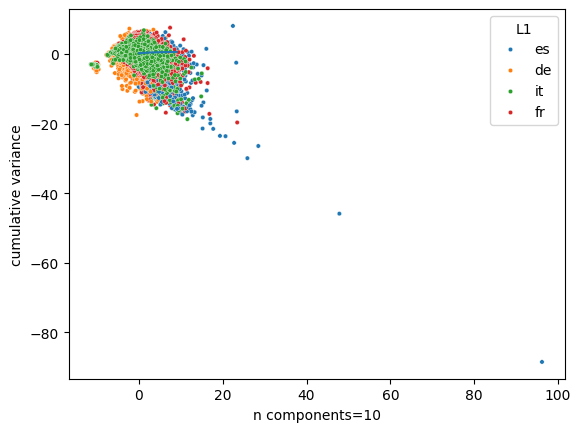

In [42]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
X = StandardScaler().fit_transform(df[num_cols])
pca = PCA(n_components=10).fit(X)
plt.plot(pca.explained_variance_ratio_.cumsum()); plt.xlabel('n components=10'); plt.ylabel('cumulative variance')
pc2 = PCA(n_components=2).fit_transform(X)
sns.scatterplot(x=pc2[:,0], y=pc2[:,1], hue=df['L1'], s=10)


<Axes: xlabel='n components=10', ylabel='cumulative variance'>

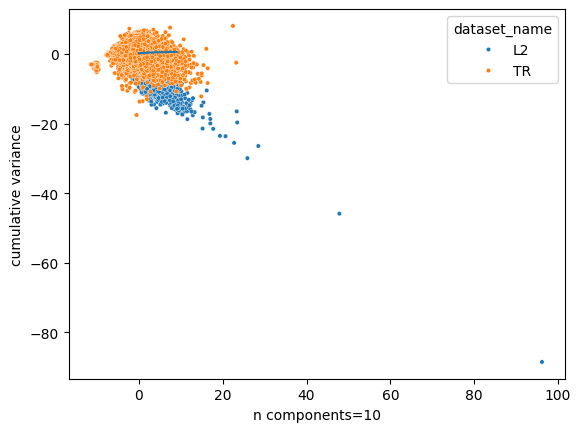

In [41]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
X = StandardScaler().fit_transform(df[num_cols])
pca = PCA(n_components=10).fit(X)
plt.plot(pca.explained_variance_ratio_.cumsum()); plt.xlabel('n components=10'); plt.ylabel('cumulative variance')
pc2 = PCA(n_components=2).fit_transform(X)
sns.scatterplot(x=pc2[:,0], y=pc2[:,1], hue=df['dataset_name'], s=10)


In [39]:
#Data Imputation

# Columns with NaNs
nan_cols = ['acl', 'aux', 'aux:pass', 'ccomp', 'nsubj:pass', 'parataxis', 'xcomp', 'sentlength']

# Impute NaNs with mean per L1 group
for col in nan_cols:
    df[col] = df[col].fillna(df.groupby('L1')[col].transform('mean'))

# Verify
df[nan_cols].isna().sum()


,0
acl,0
aux,0
aux:pass,0
ccomp,0
nsubj:pass,0
parataxis,0
xcomp,0
sentlength,0


#Analysis of Numerical columns

In [12]:
df.describe().T  # numeric overview: mean, std, min, max


,count,mean,std,min,25%,50%,75%,max
sentlength,142397.0,26.798322,8.117512,4.000000,22.277778,26.000000,30.583333,353.000000
ppron,142540.0,0.012159,0.014187,0.000000,0.002899,0.008333,0.017167,0.400000
possdet,142540.0,0.006168,0.007254,0.000000,0.000000,0.004266,0.009132,0.200000
indef,142540.0,0.000207,0.001348,0.000000,0.000000,0.000000,0.000000,0.111111
cconj,142540.0,0.867213,0.518171,0.000000,0.545455,0.800000,1.117647,14.000000
whconj,142540.0,0.033960,0.074458,0.000000,0.000000,0.000000,0.047619,2.000000
relativ,142540.0,0.183717,0.208065,0.000000,0.000000,0.133333,0.263158,7.500000
pied,142540.0,0.016104,0.048912,0.000000,0.000000,0.000000,0.000000,1.000000
correl,142540.0,0.000058,0.003049,0.000000,0.000000,0.000000,0.000000,0.500000
copula,142540.0,0.272293,0.227488,0.000000,0.117647,0.250000,0.379310,9.000000


#Correlation Matrix

<Axes: >

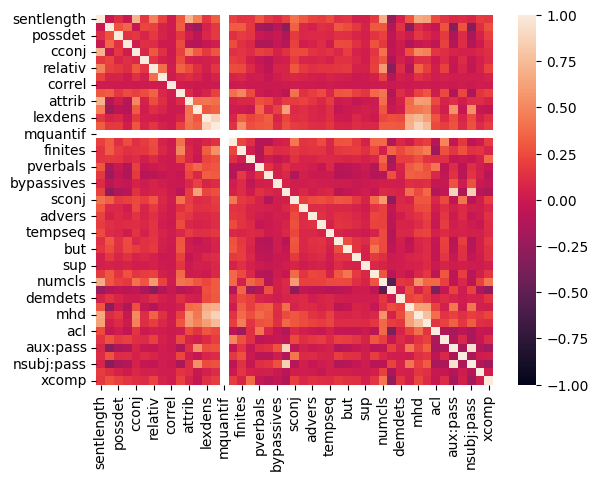

In [13]:
corr = df.select_dtypes('number').corr()
import seaborn as sns
sns.heatmap(corr, vmin=-1, vmax=1)


#Distribution of features

## distribution of features by L2 & TR

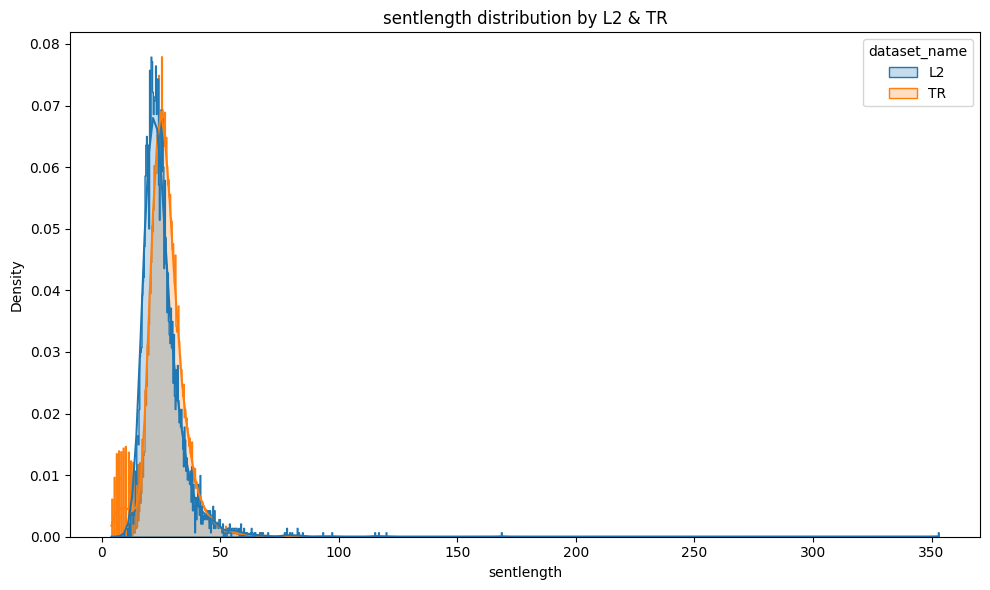

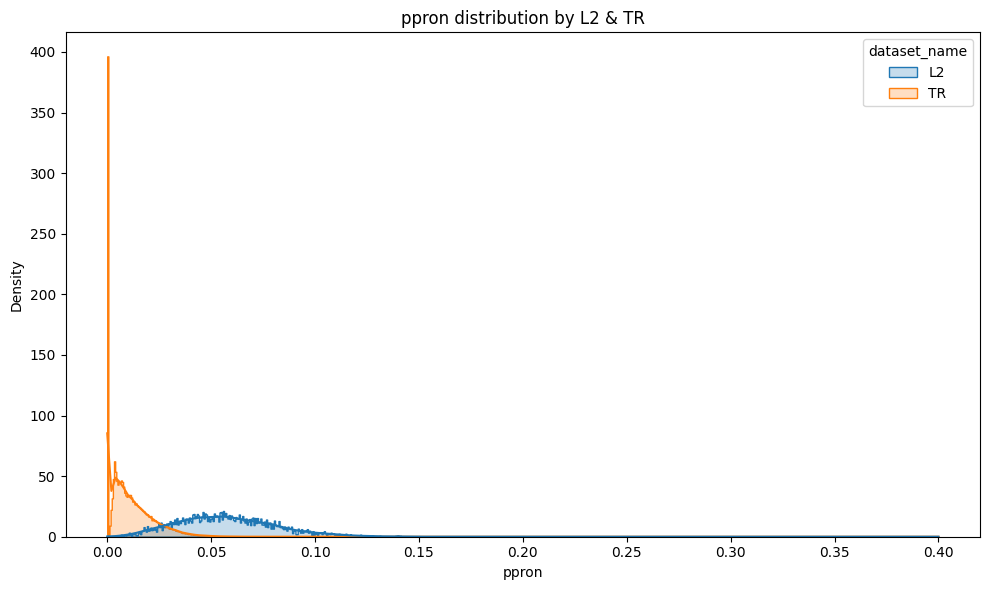

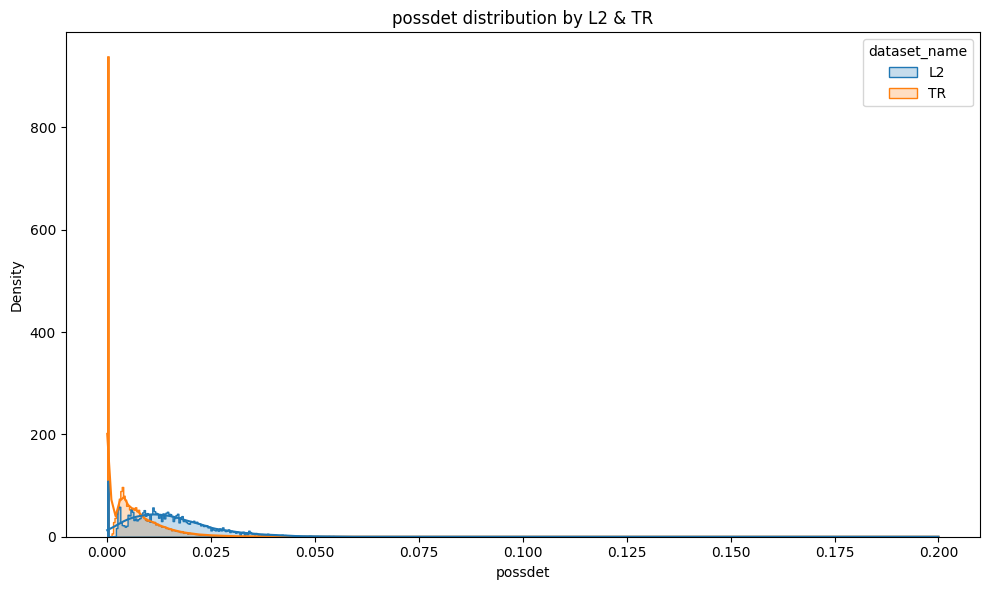

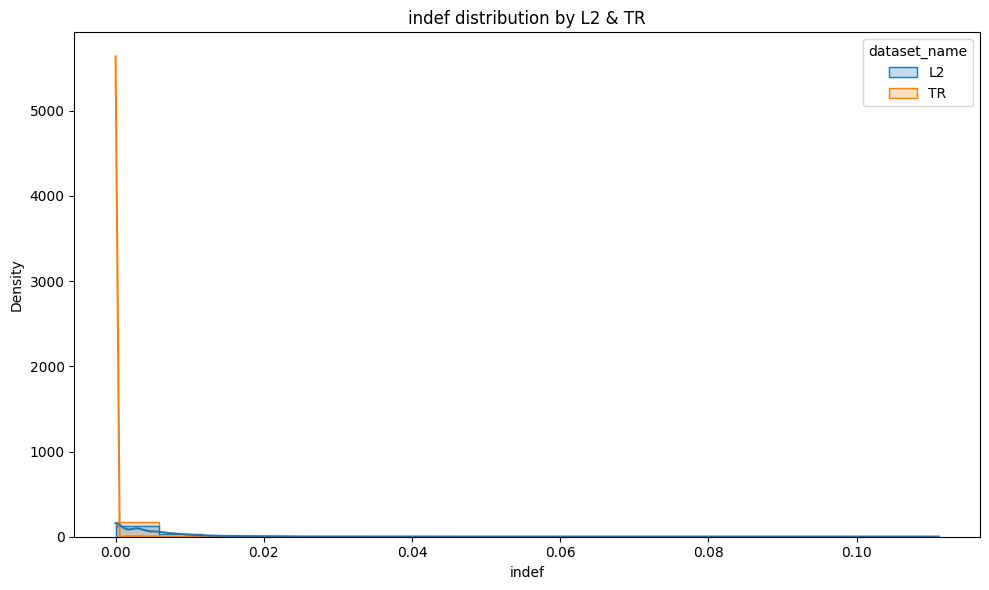

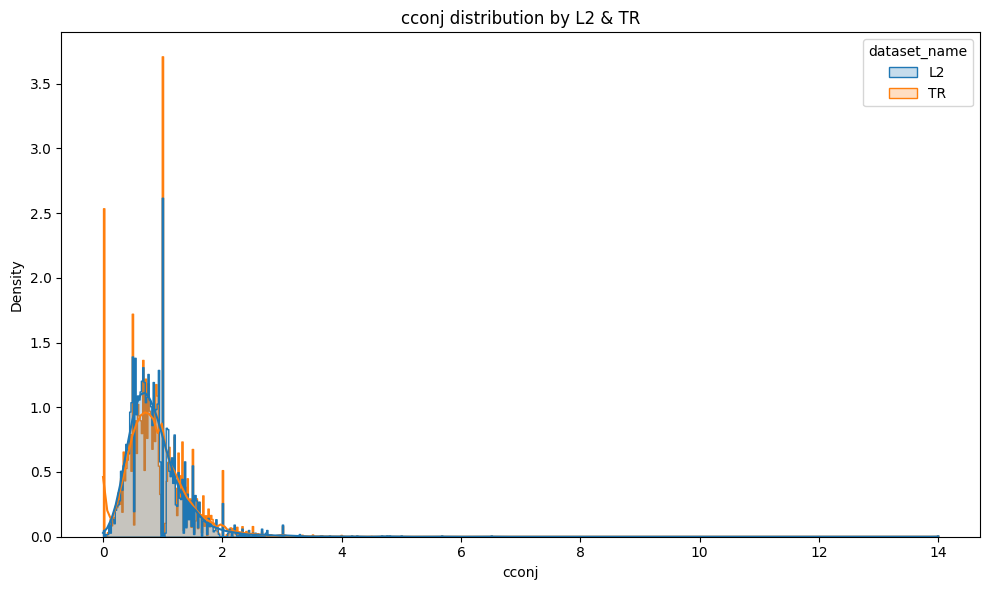

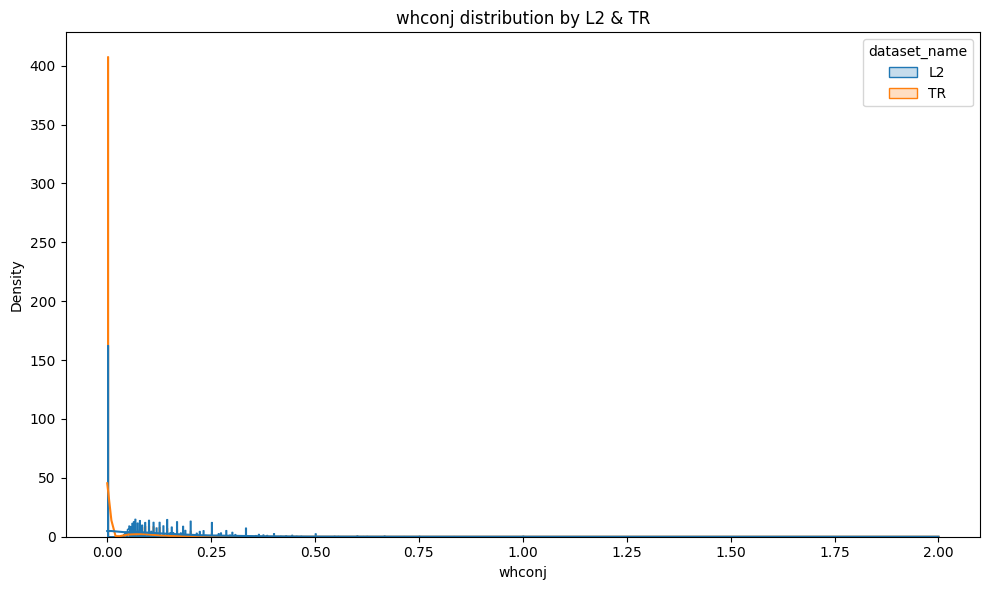

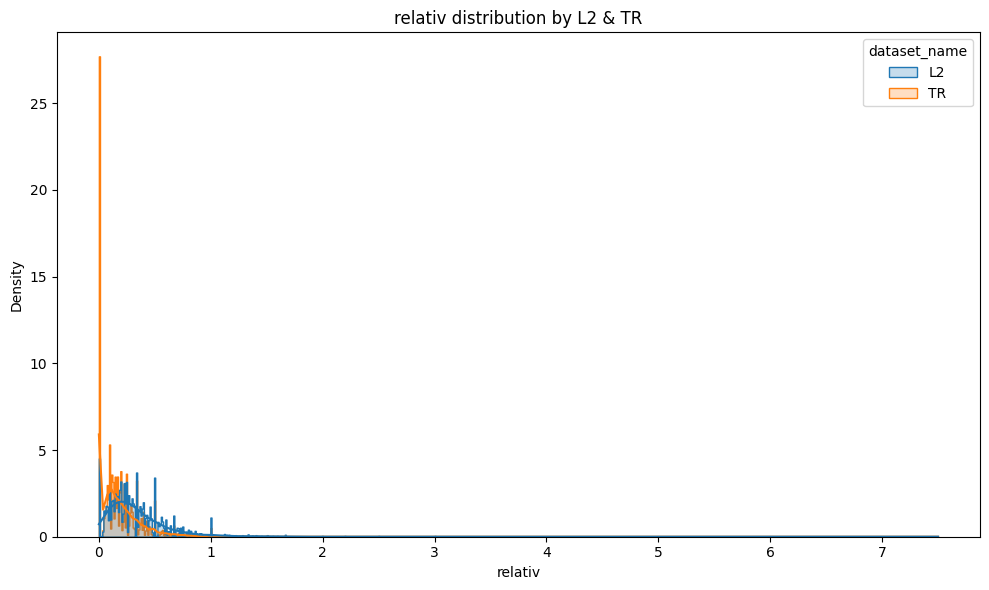

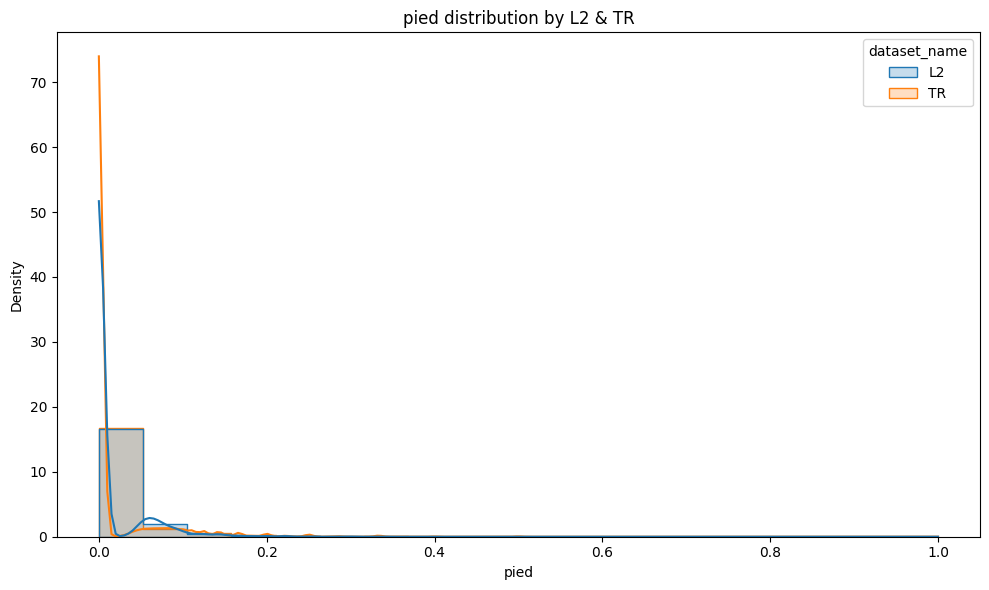

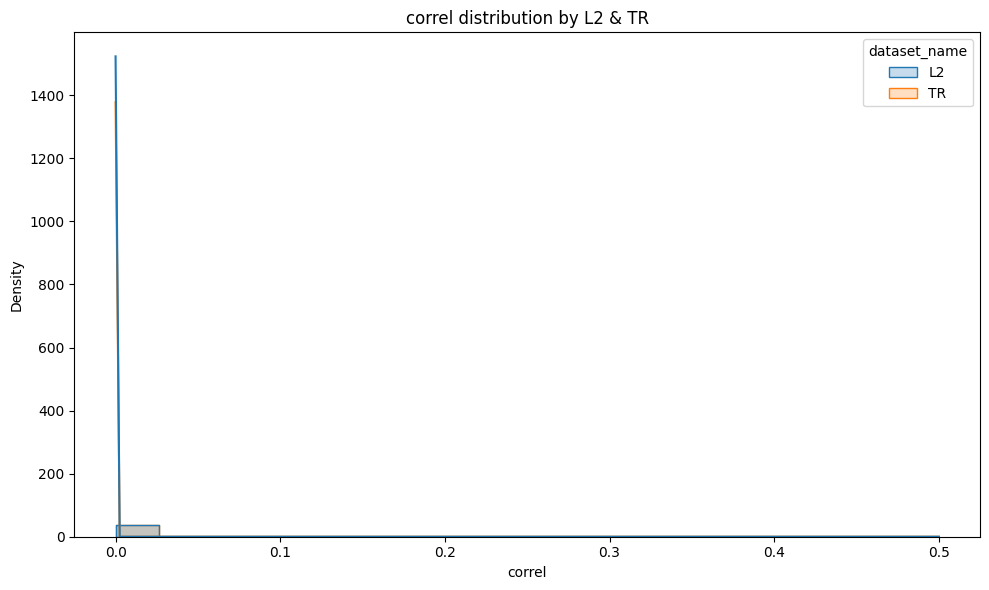

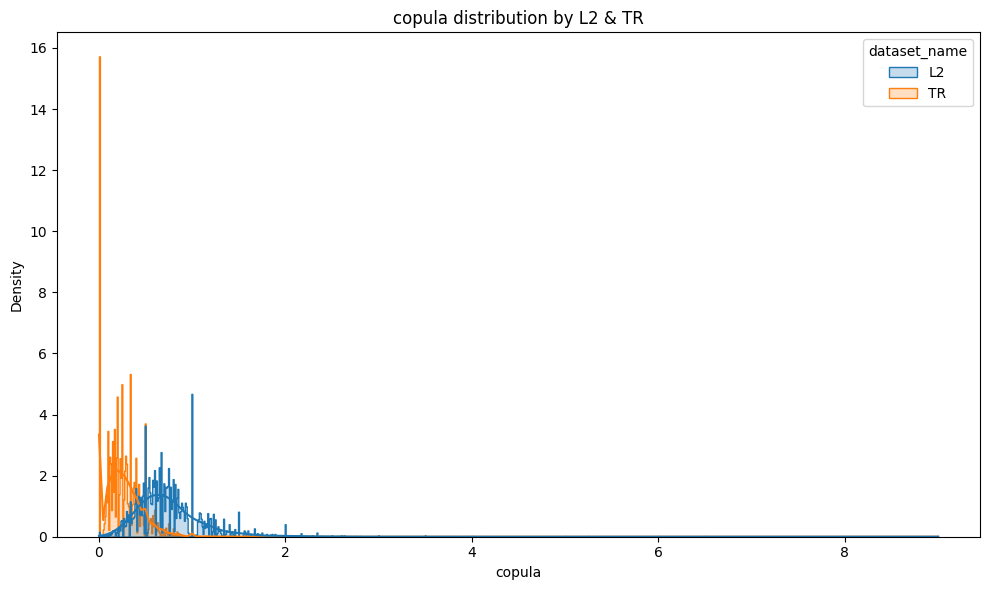

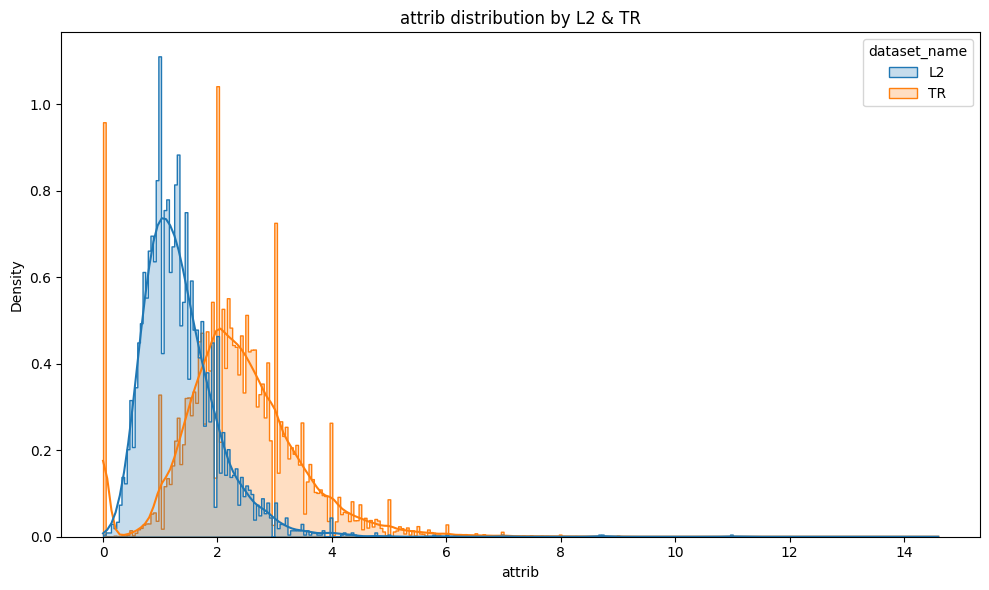

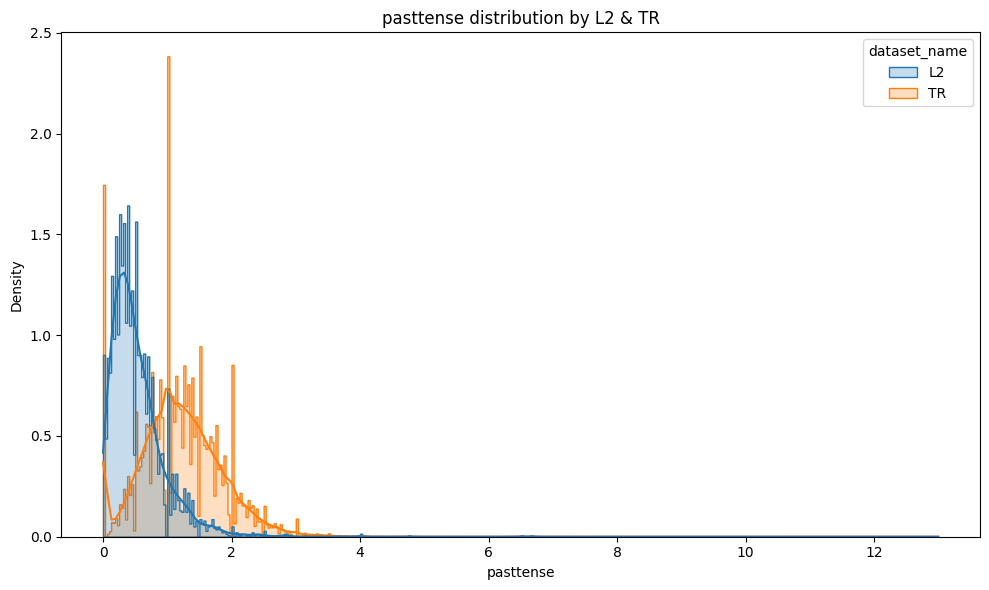

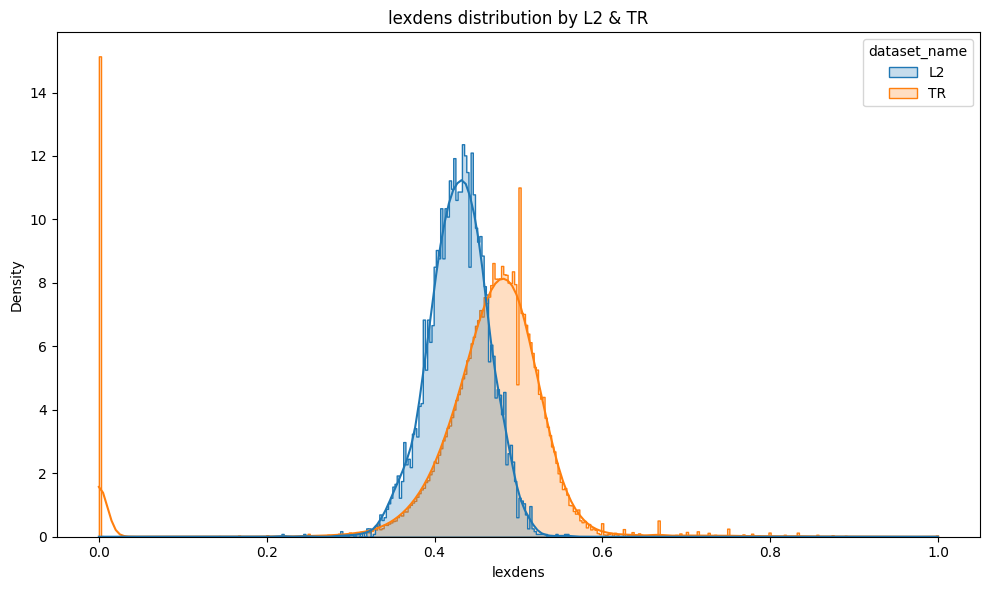

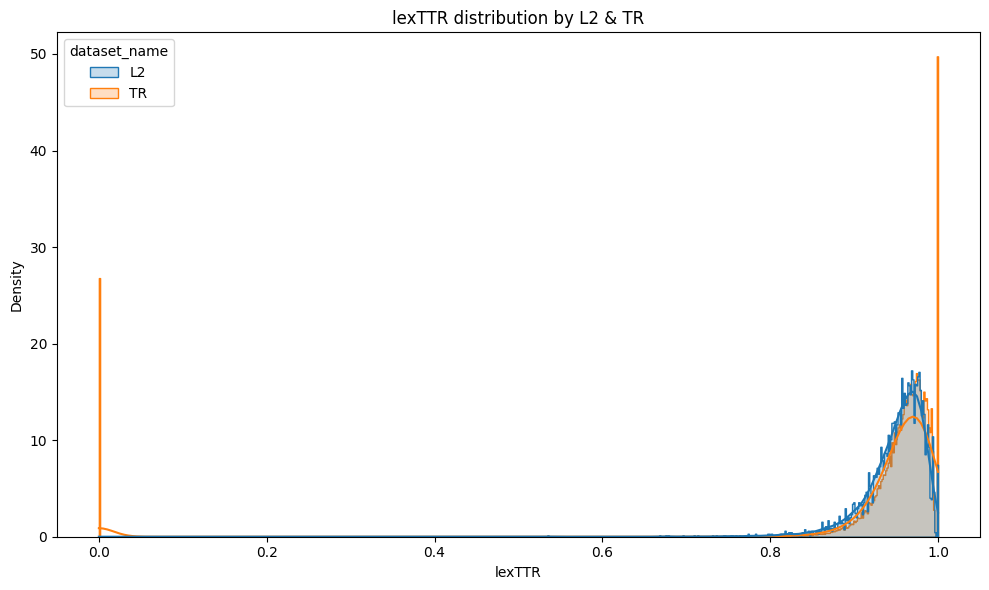

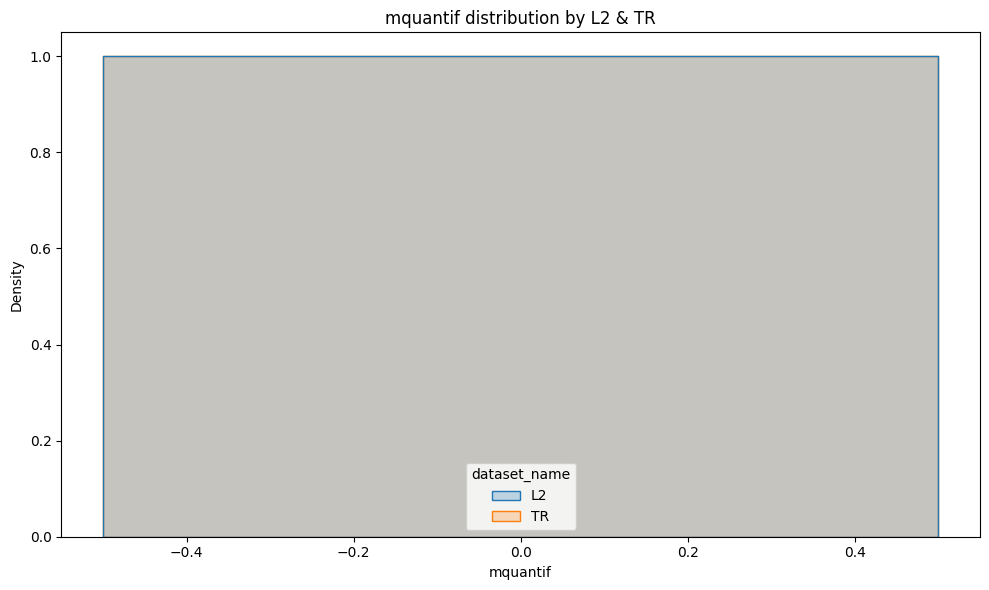

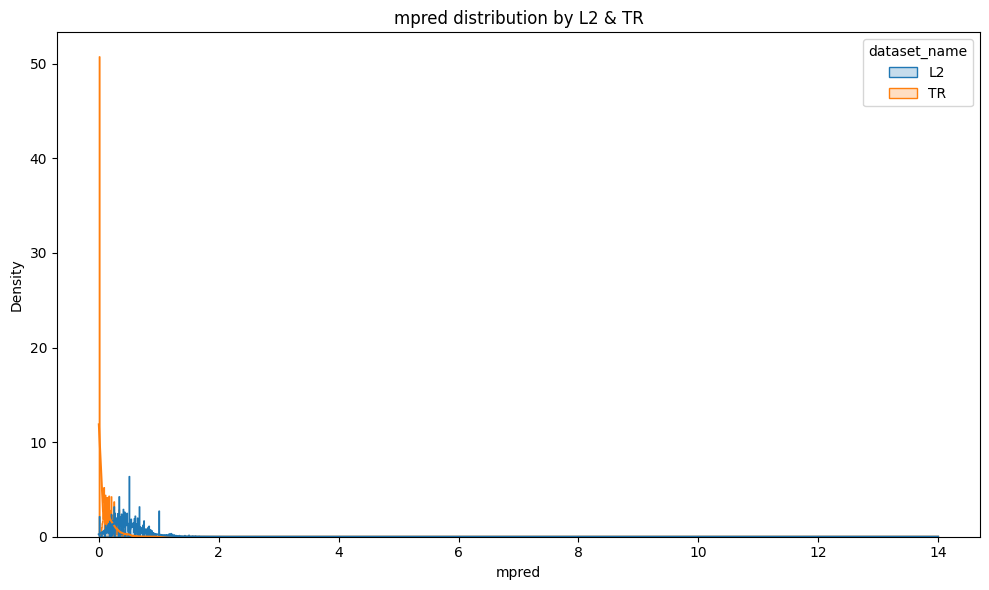

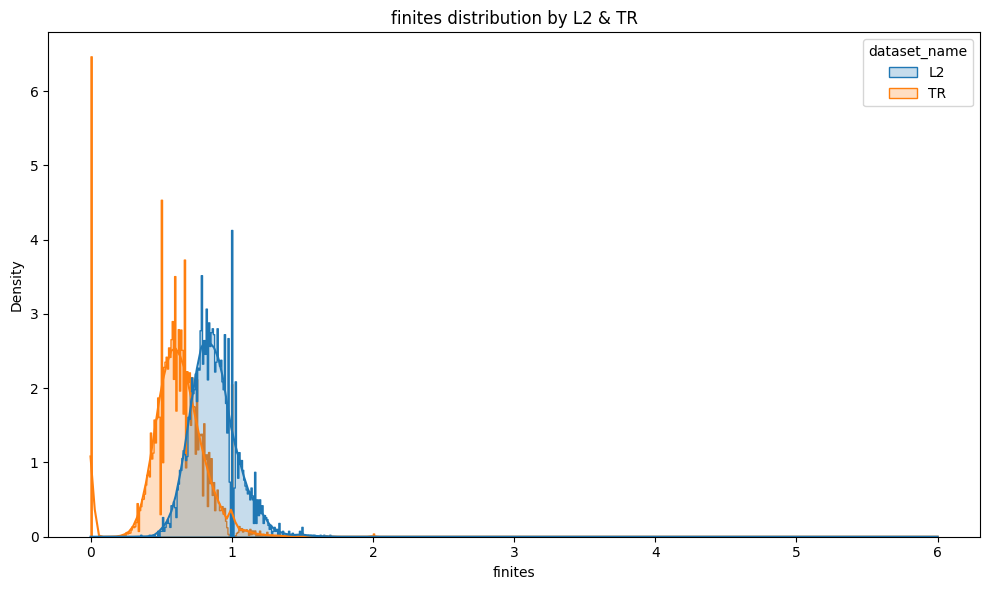

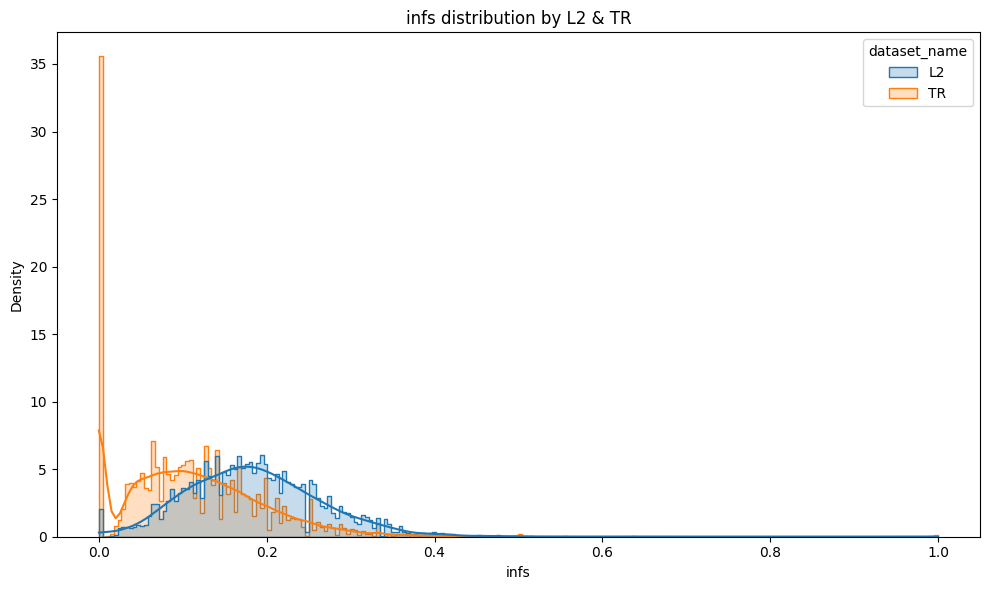

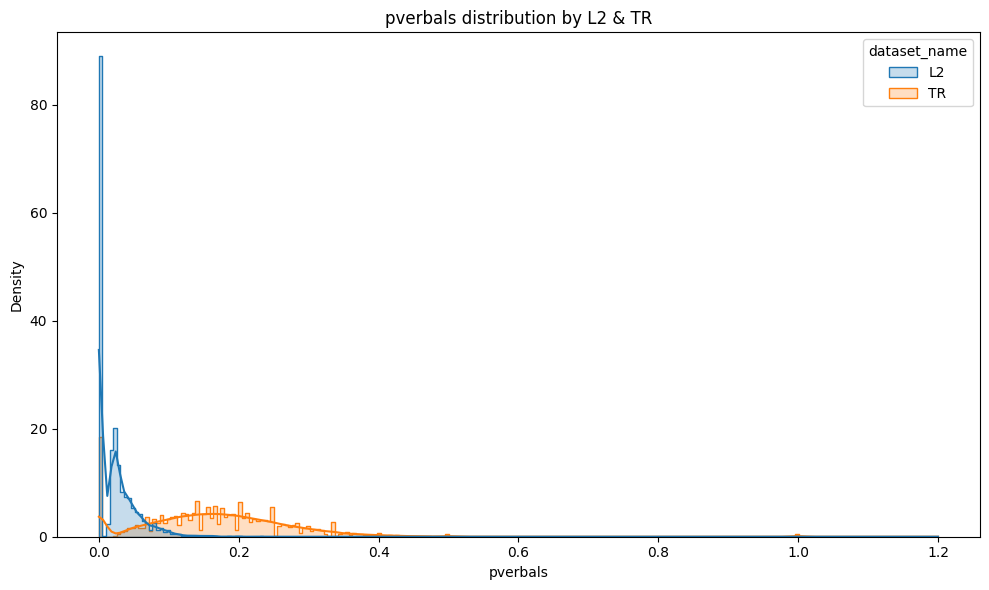

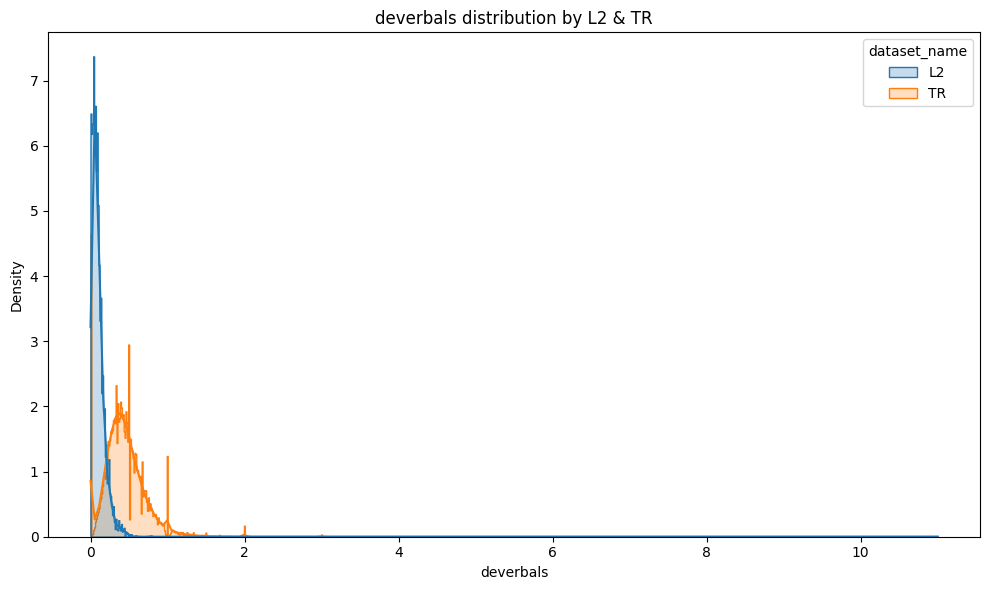

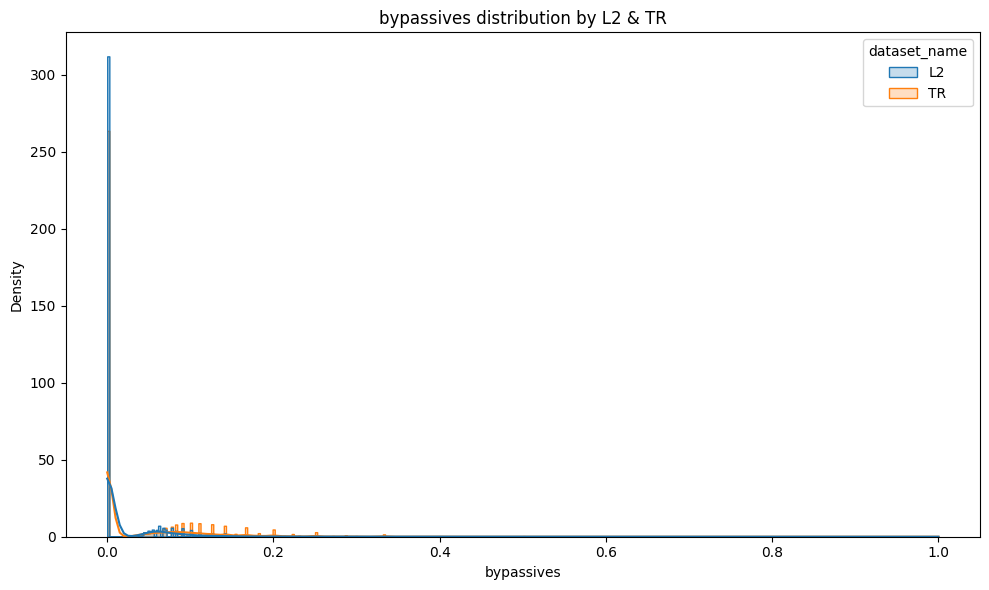

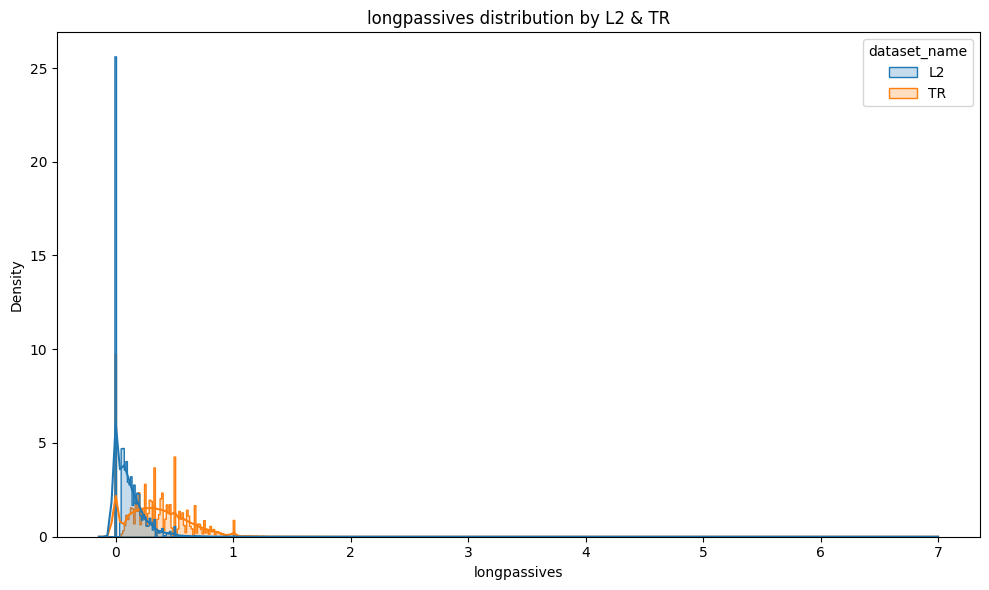

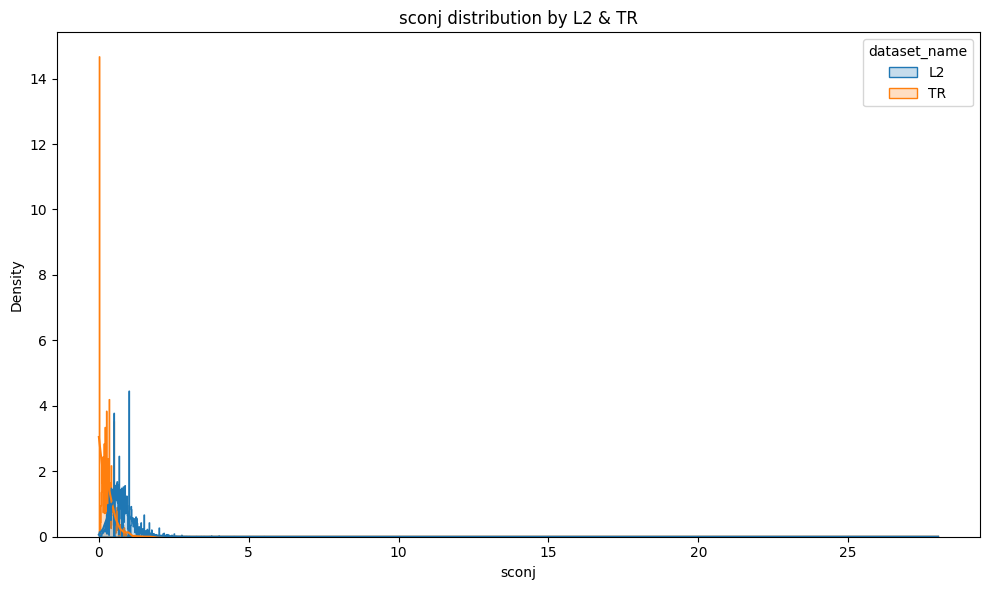

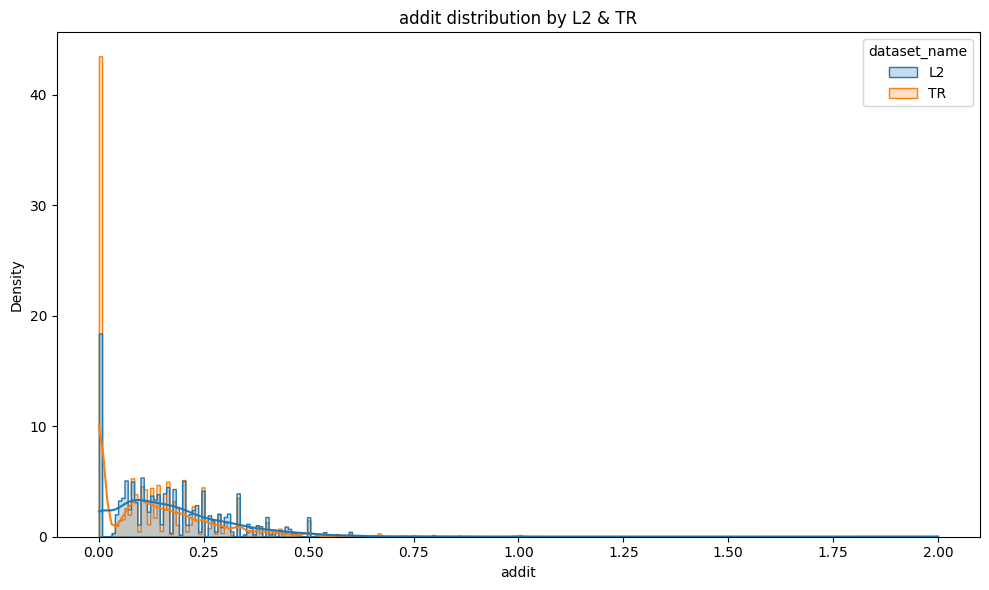

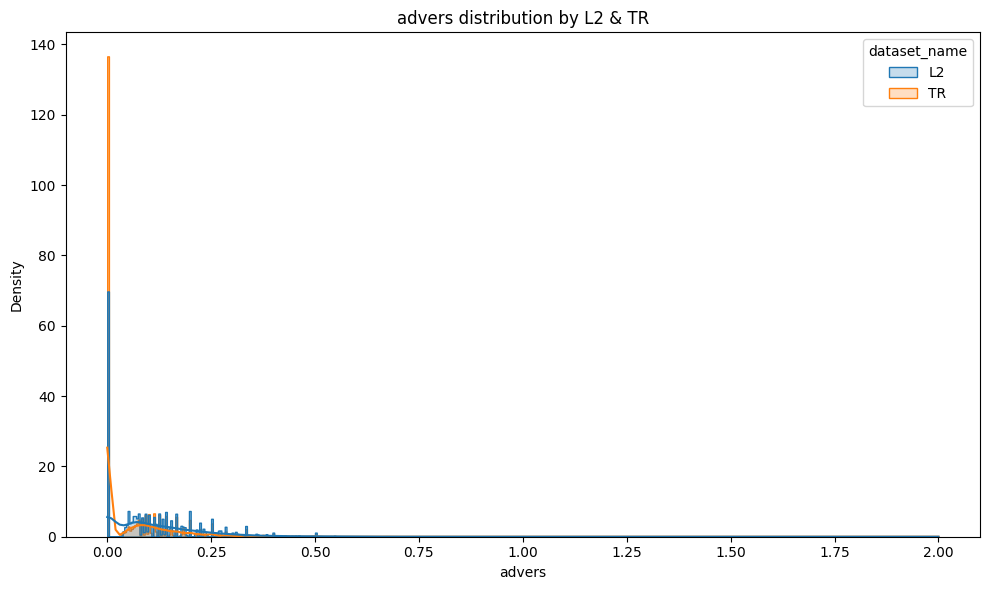

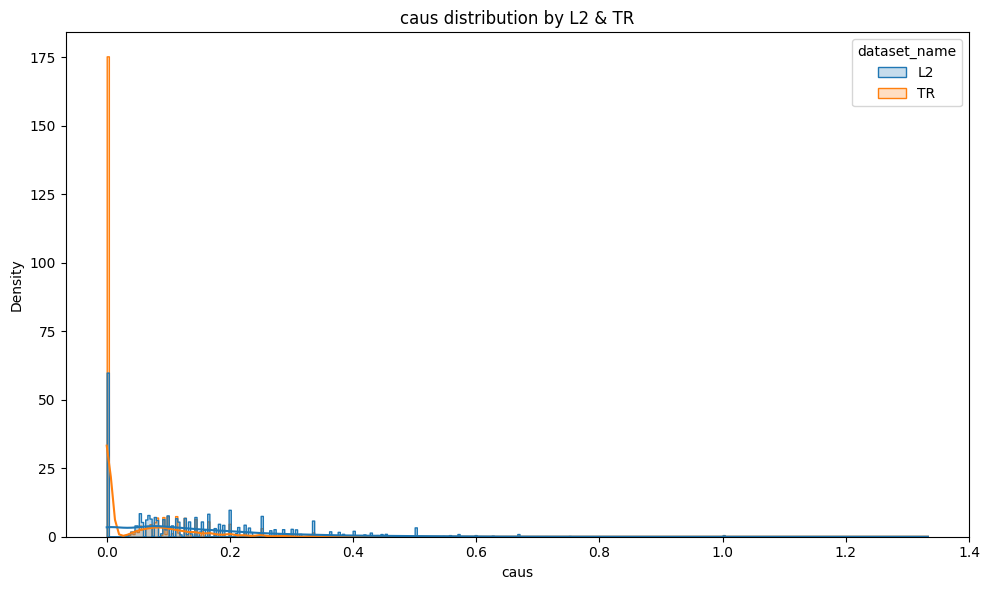

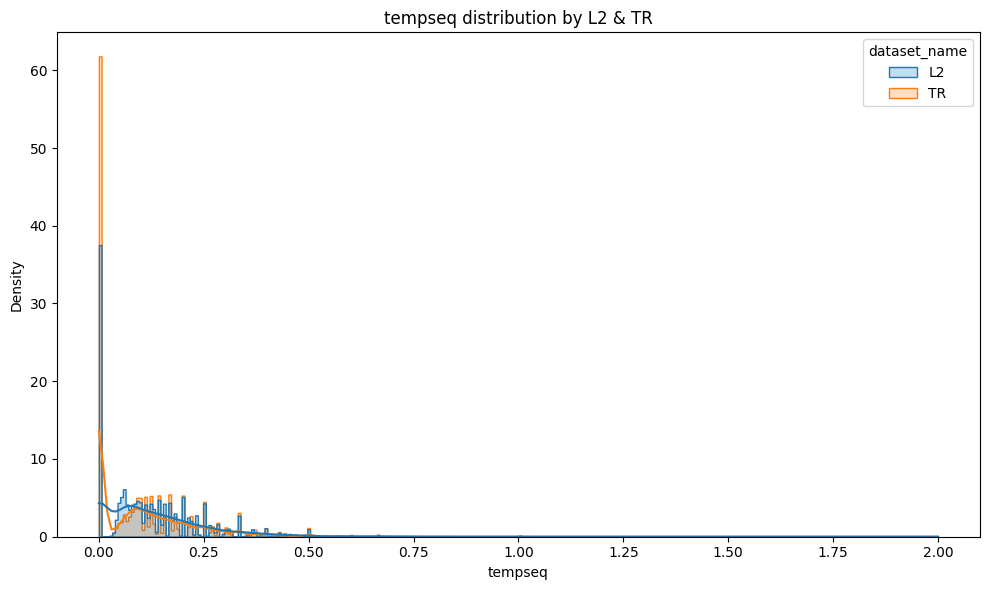

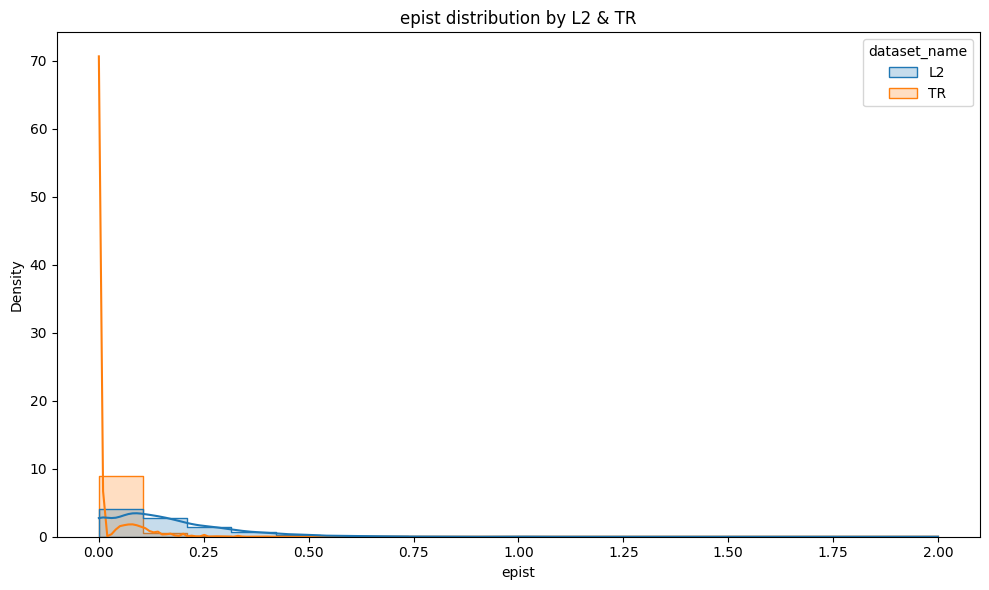

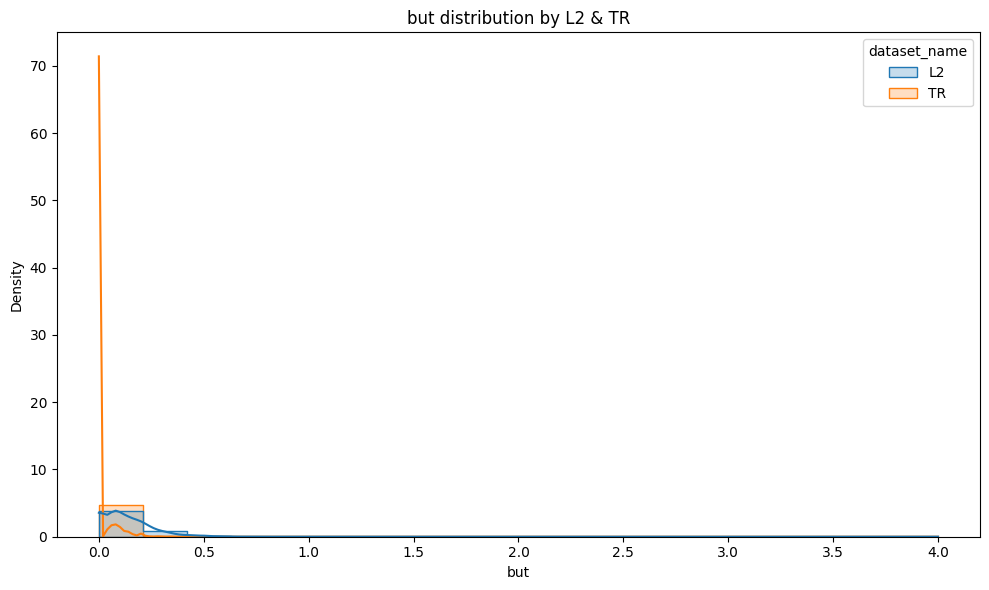

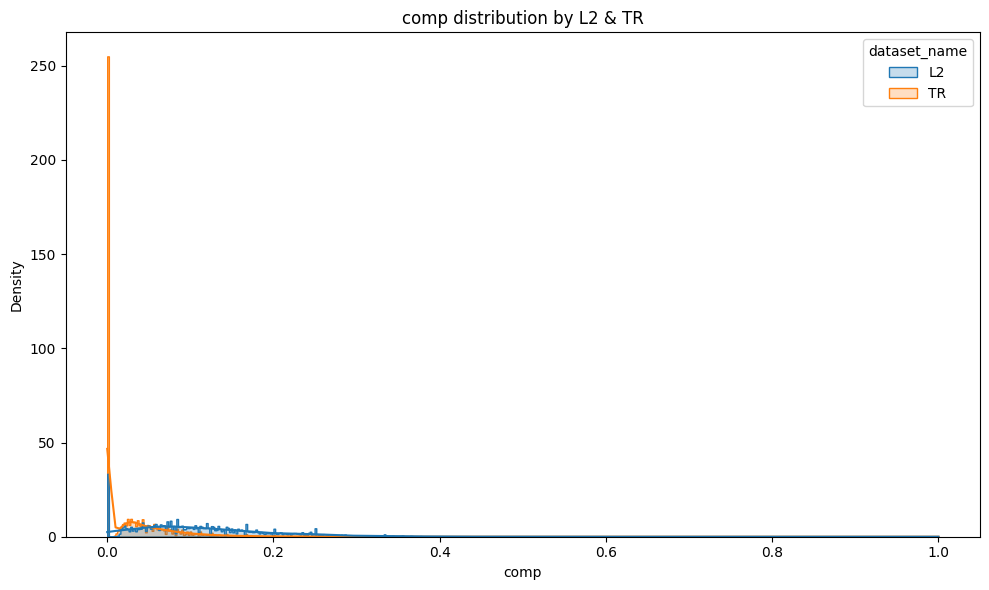

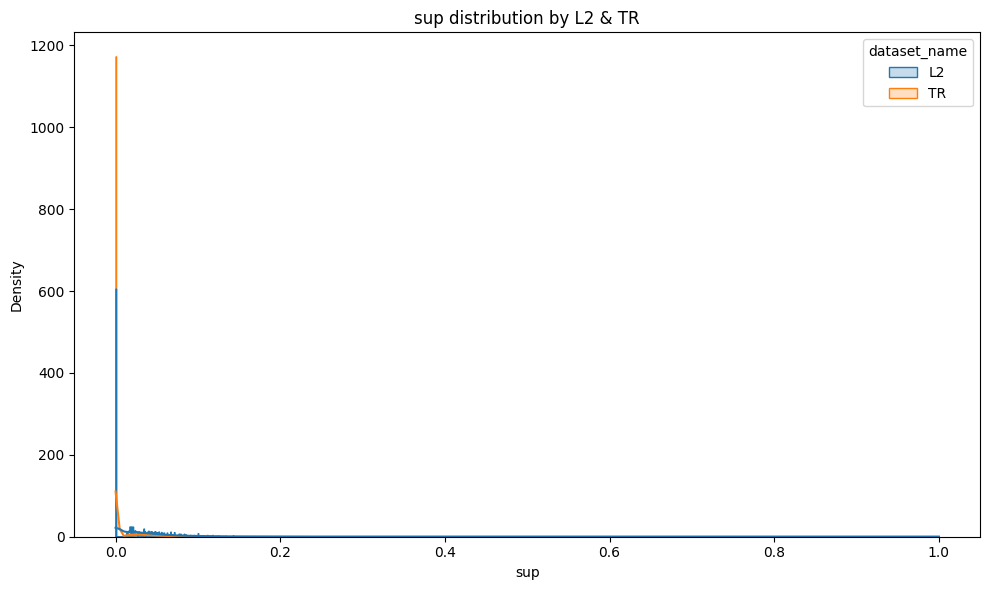

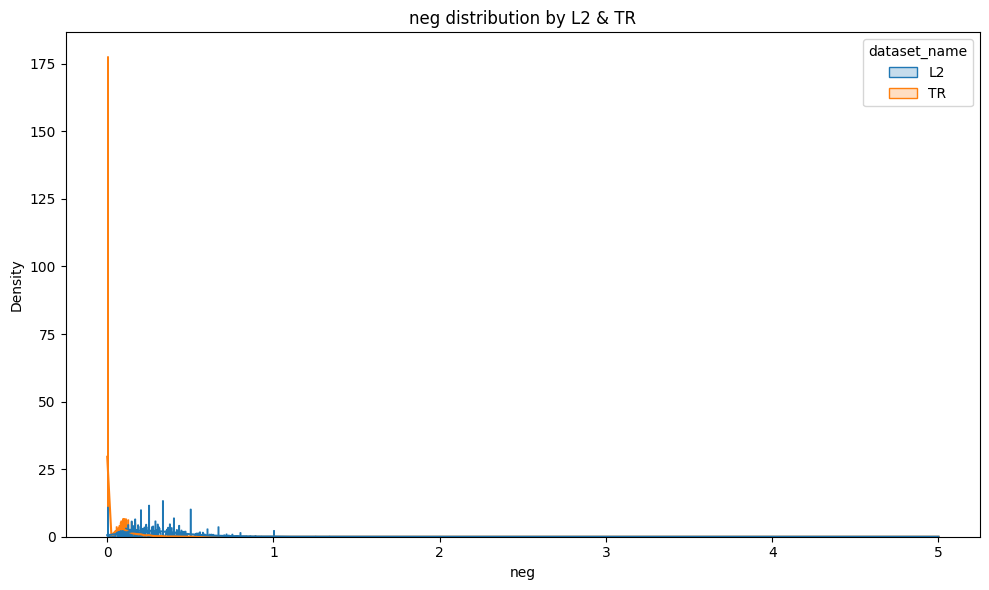

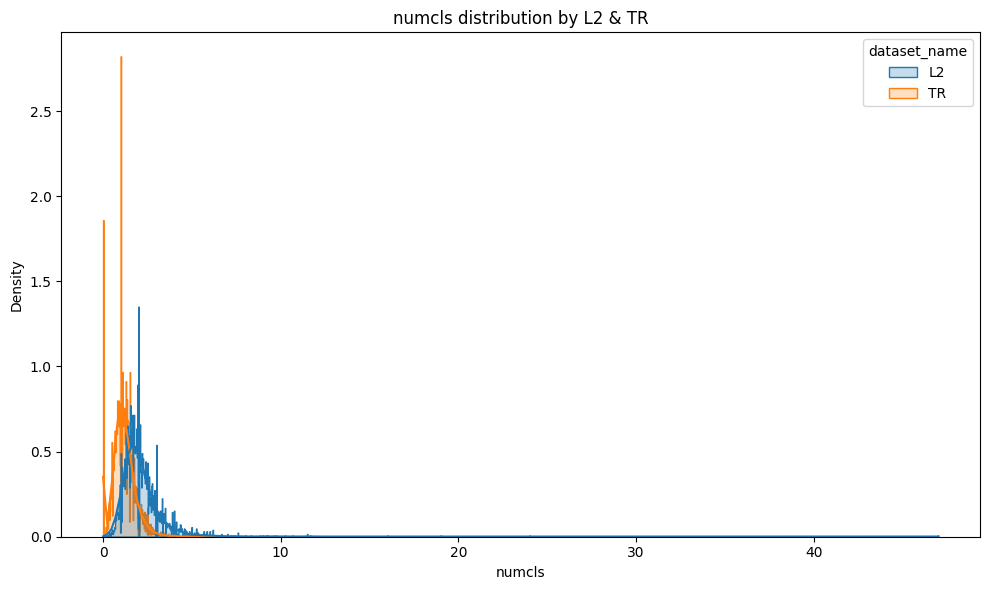

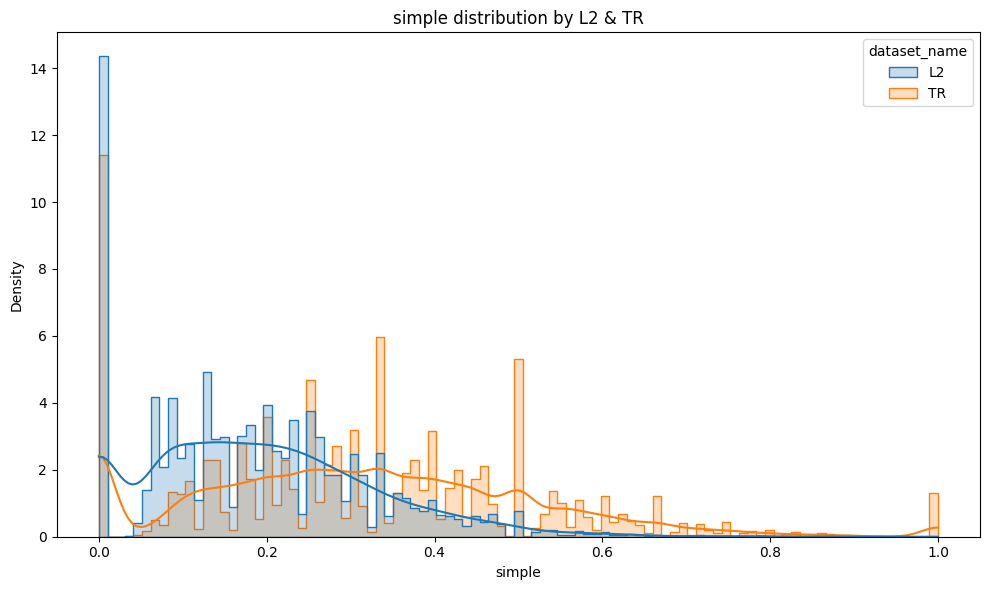

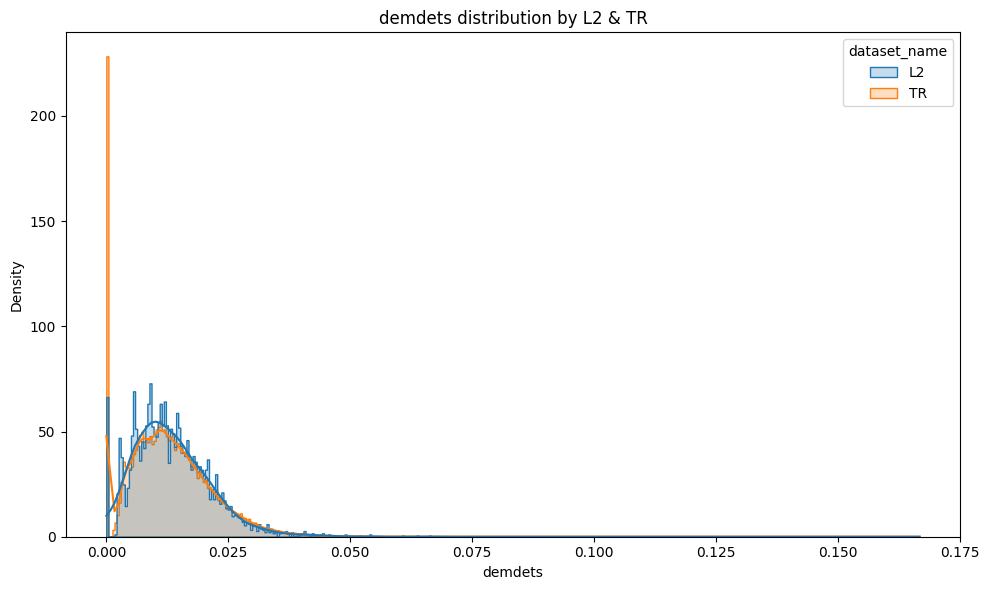

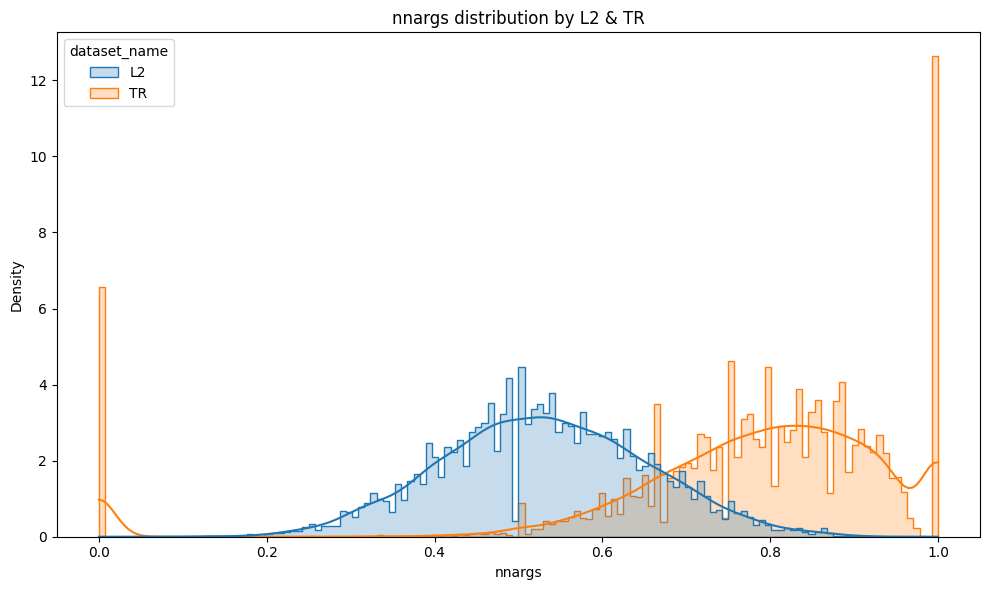

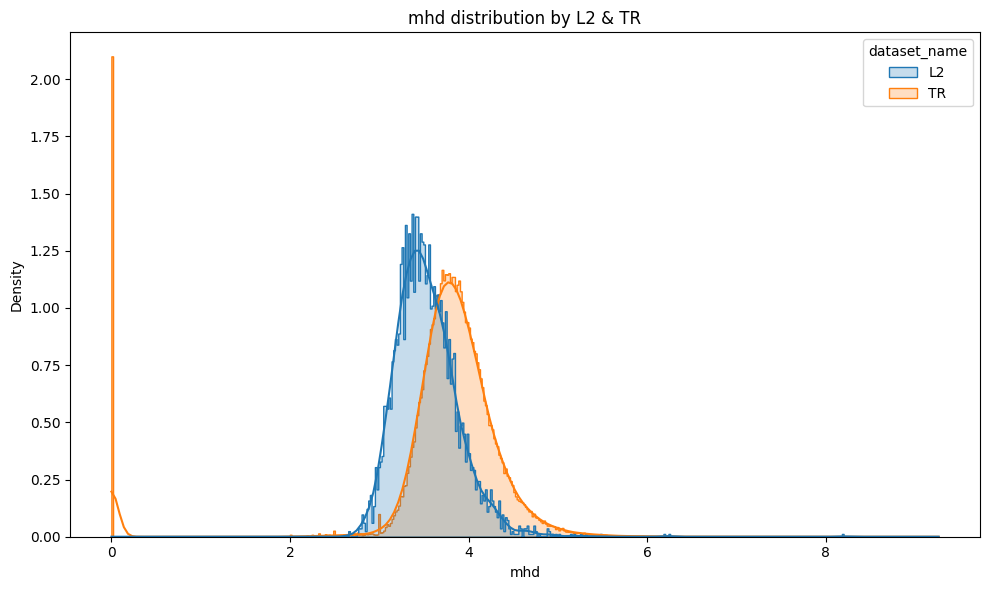

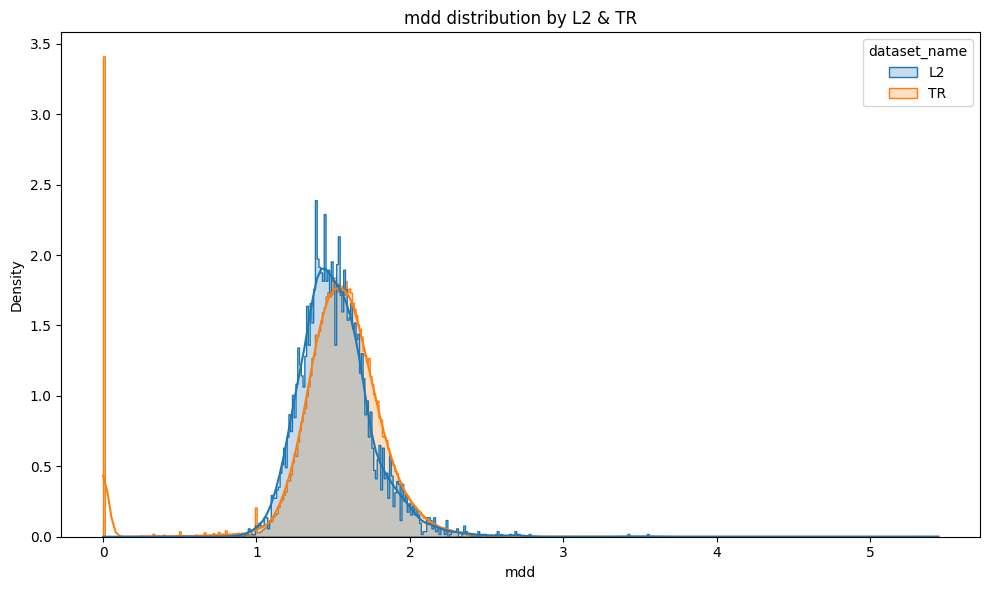

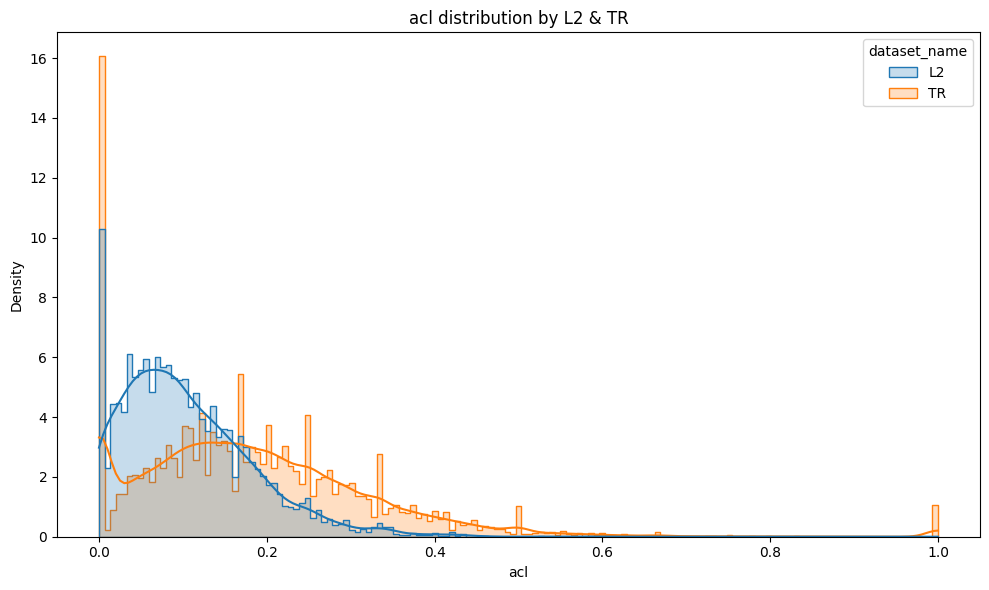

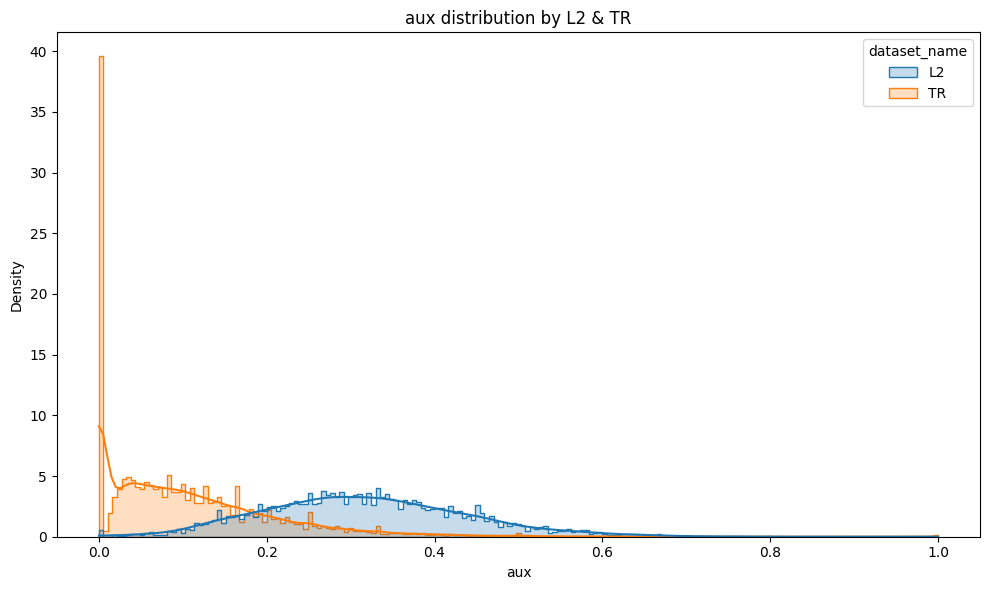

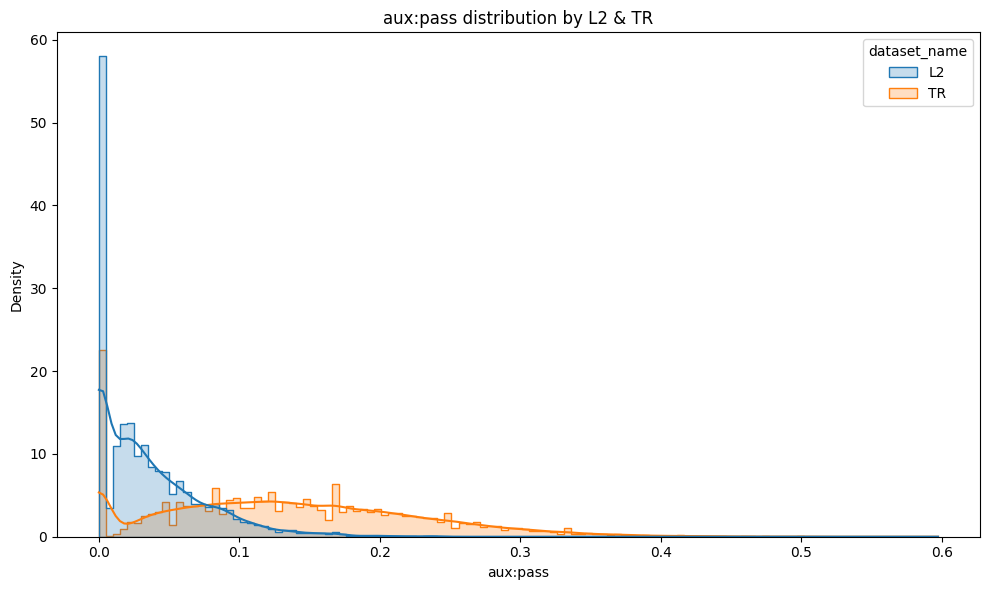

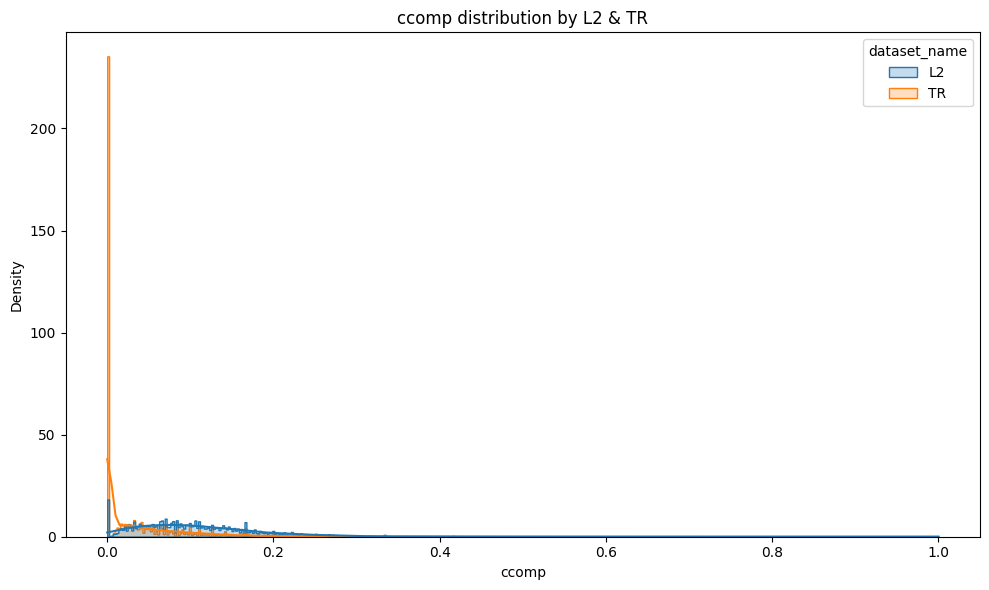

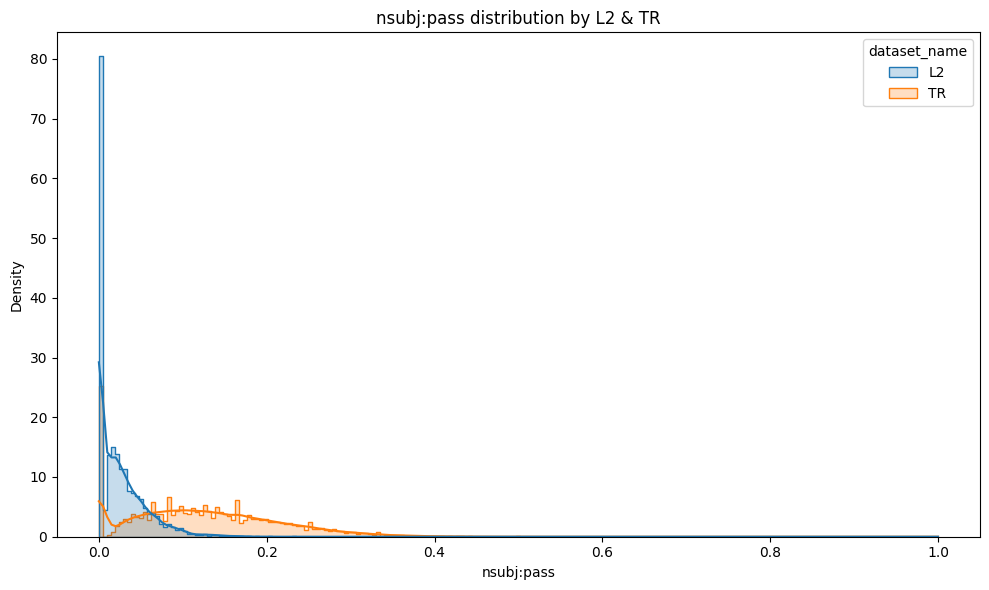

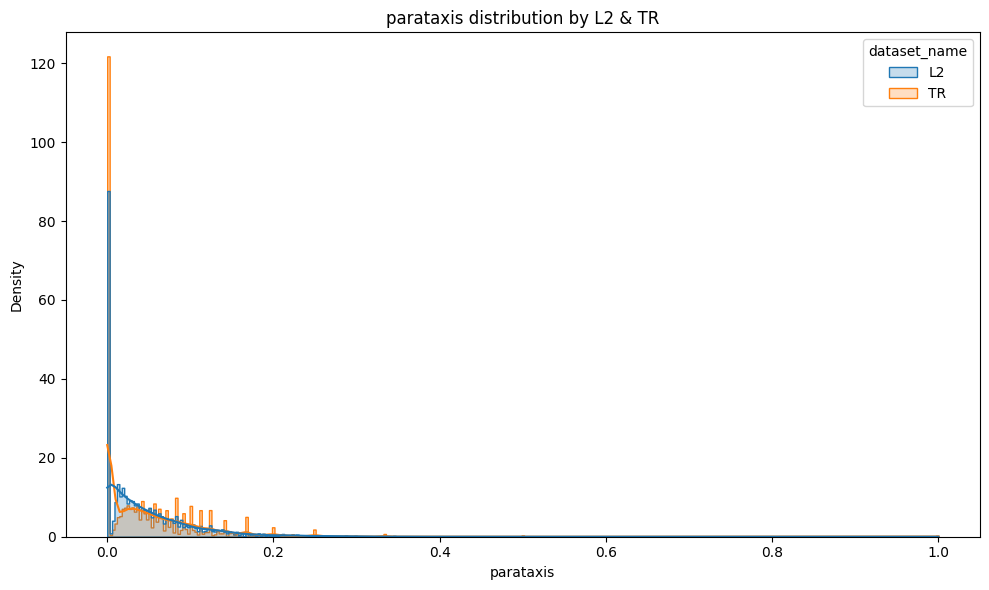

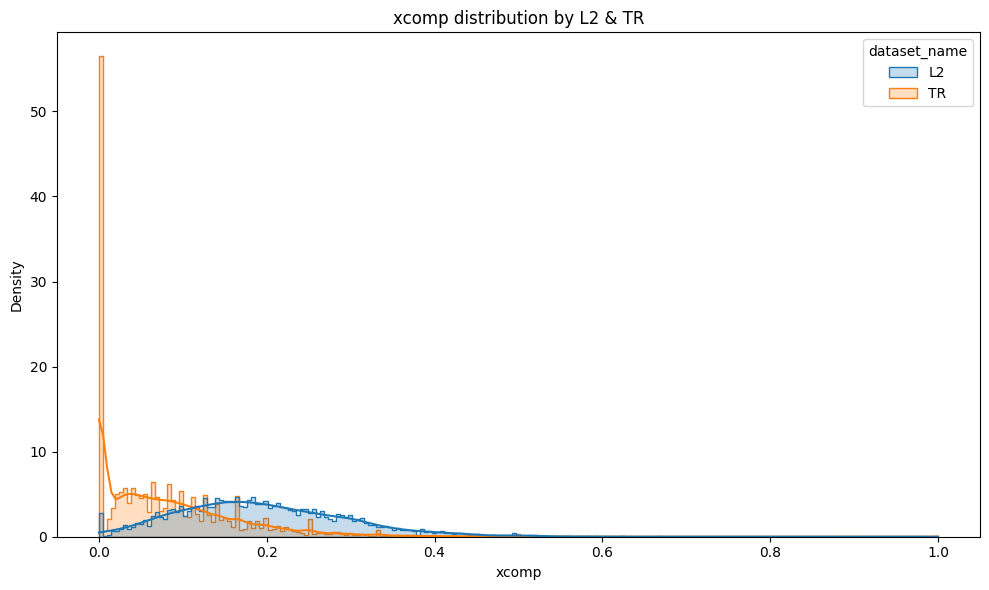

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns


# only the languages you want
dataset_groups = ["L2","TR"]

for col in num_cols:
    plt.figure(figsize=(10, 6))
    try:
      sns.histplot(
          data=df[df["dataset_name"].isin(dataset_groups)],
          x=col,
          hue="dataset_name",
          kde=True,
          element="step",
          stat="density",
          common_norm=False,
          label = dataset_groups
      )
    except:
      sns.histplot(
          data=df[df["dataset_name"].isin(dataset_groups)],
          x=col,
          hue="dataset_name",
          element="step",
          stat="density",
          common_norm=False,
          label = dataset_groups
      )

    plt.title(f"{col} distribution by L2 & TR")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.tight_layout()
    plt.show()

df = df.drop("dataset_name", axis = 'columns')

##Distribution of features by L1

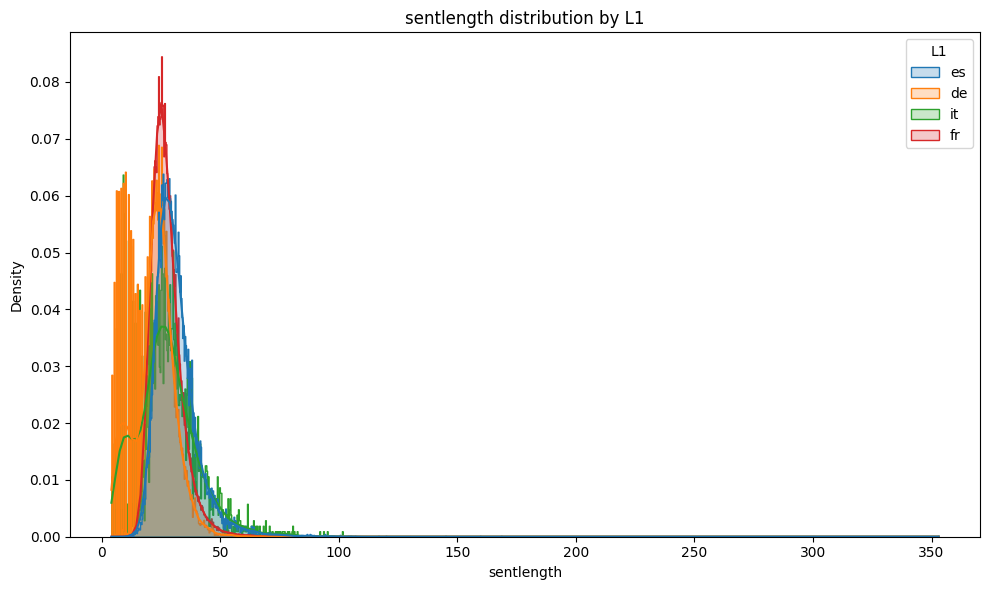

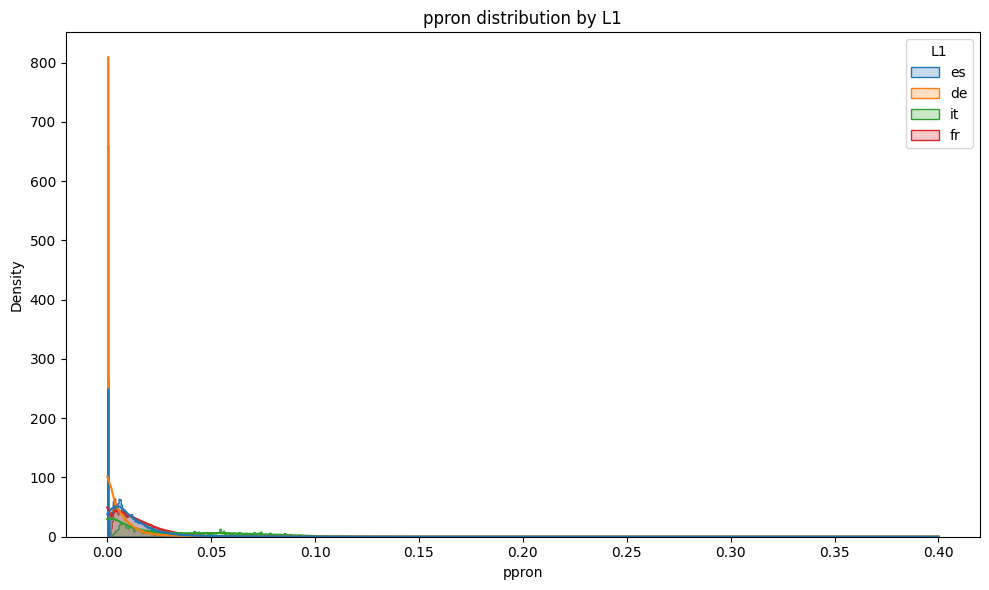

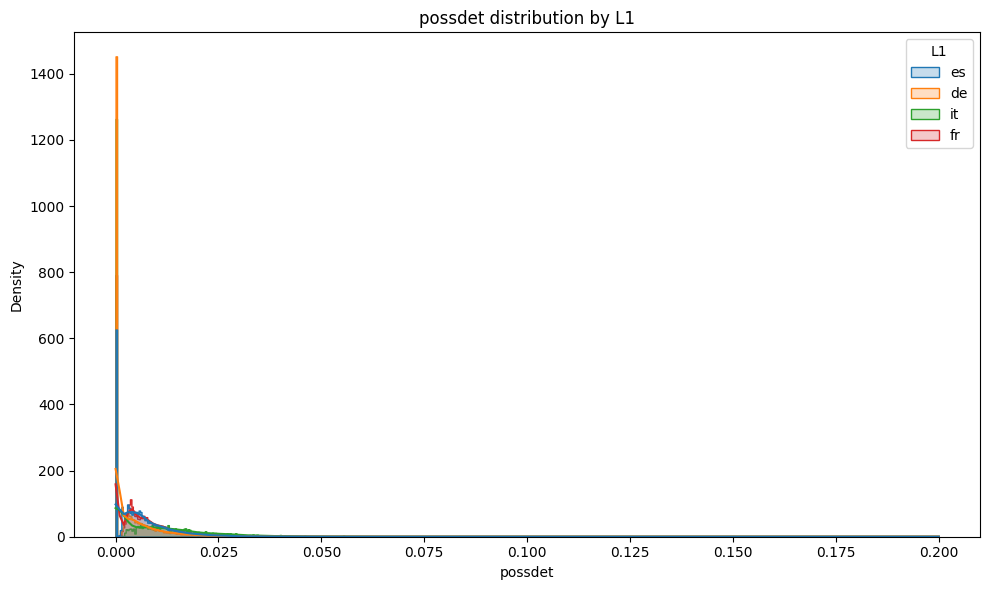

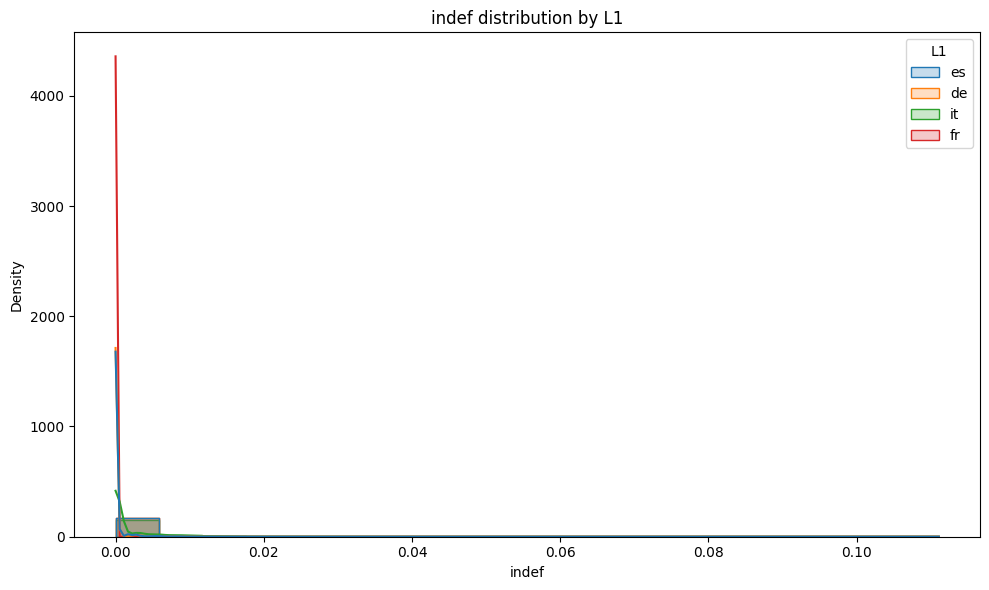

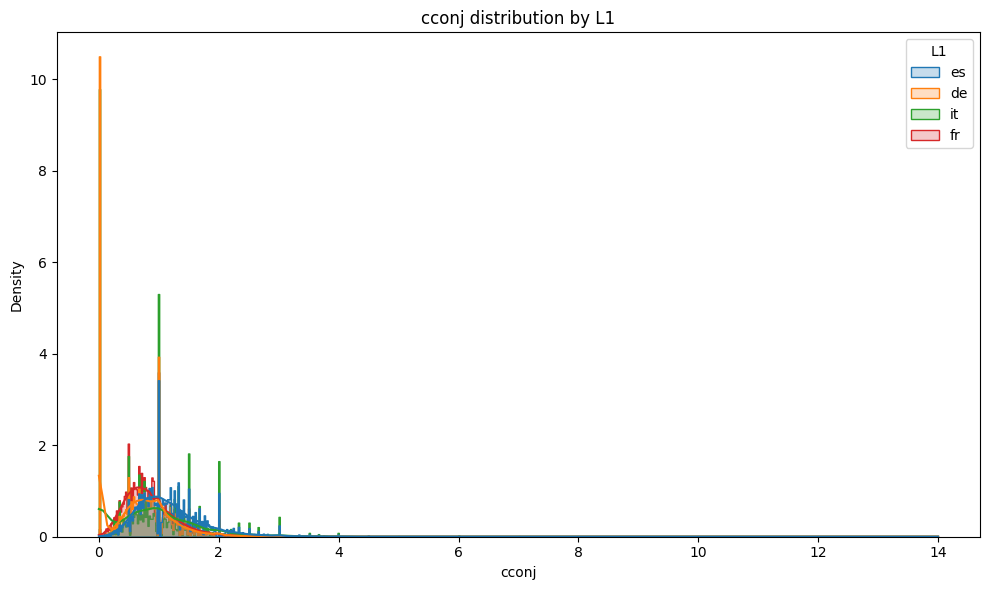

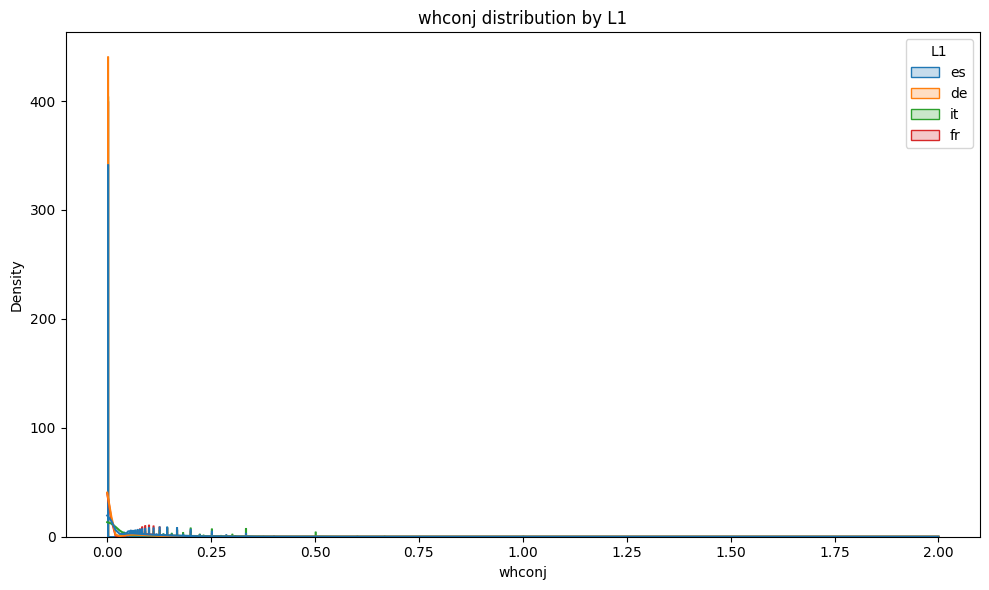

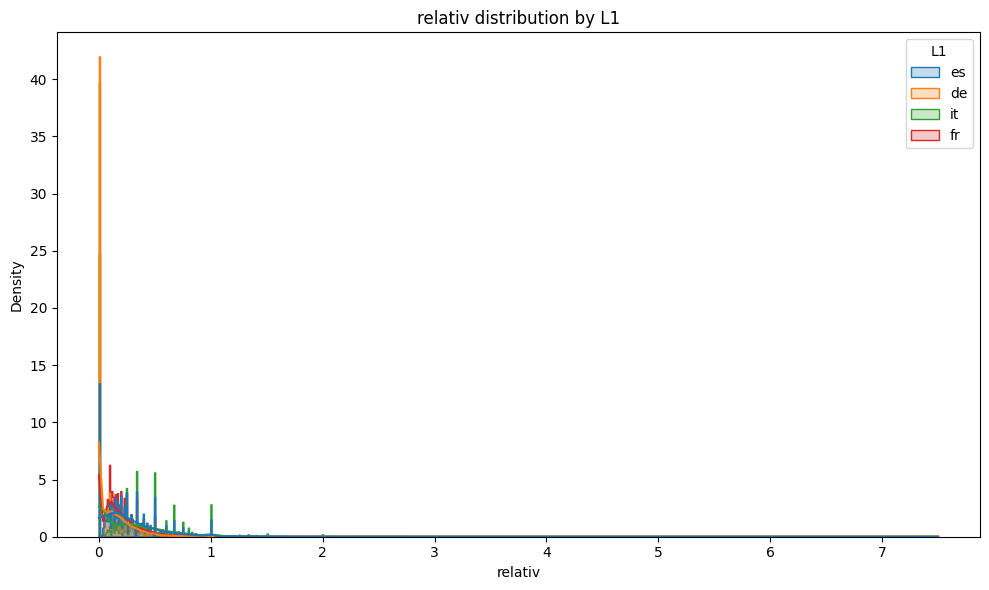

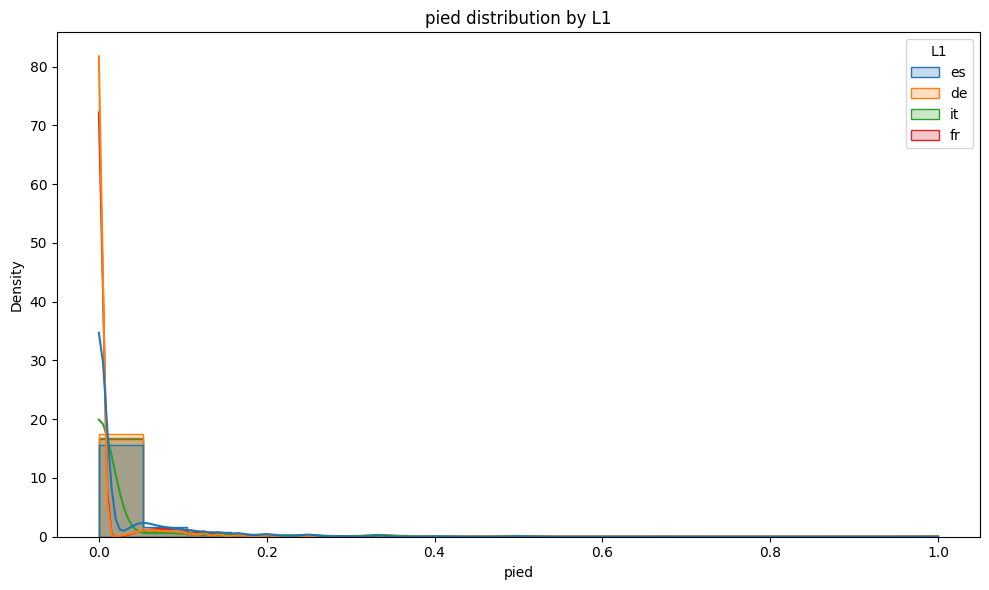

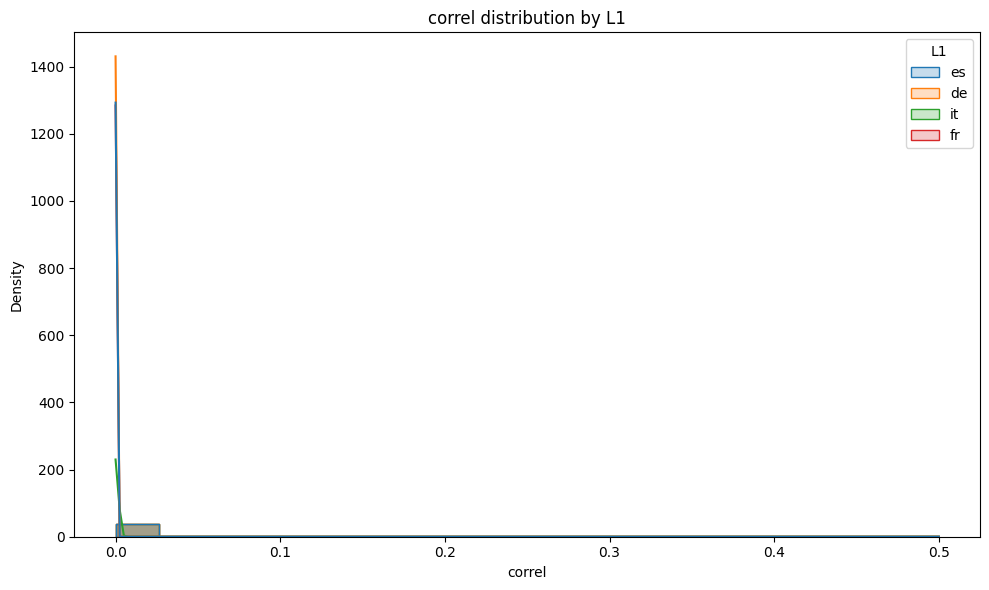

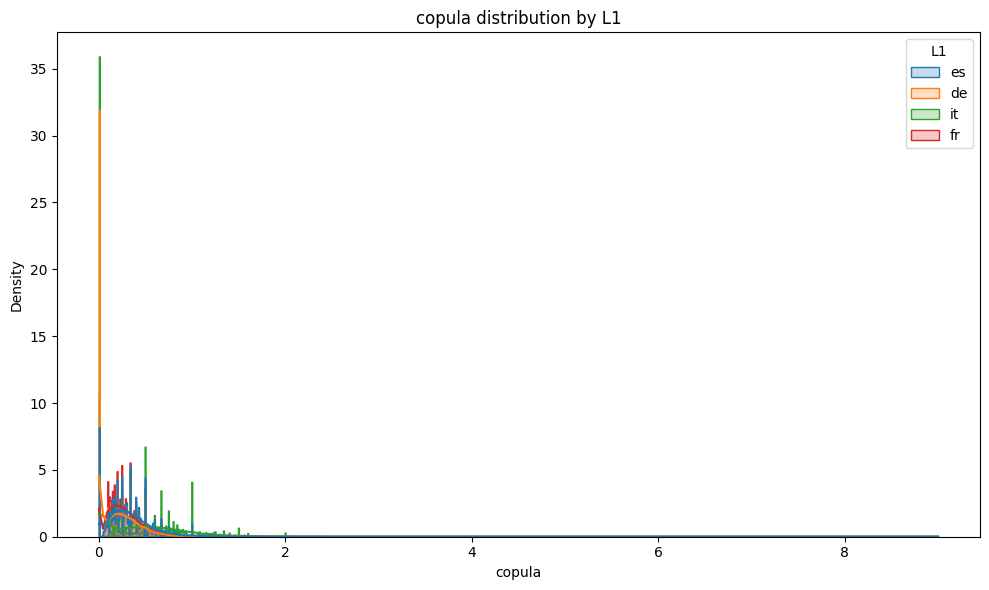

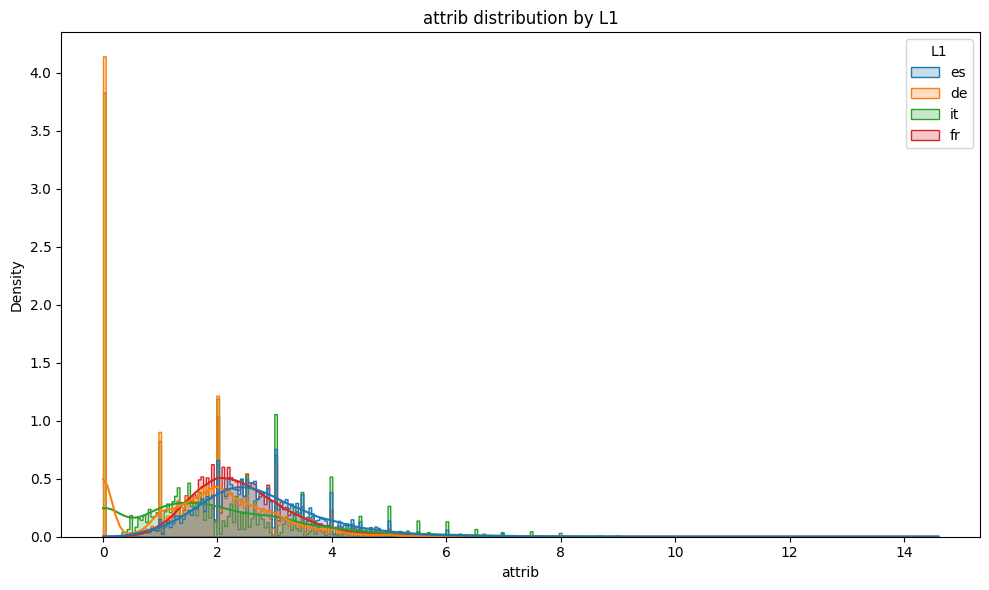

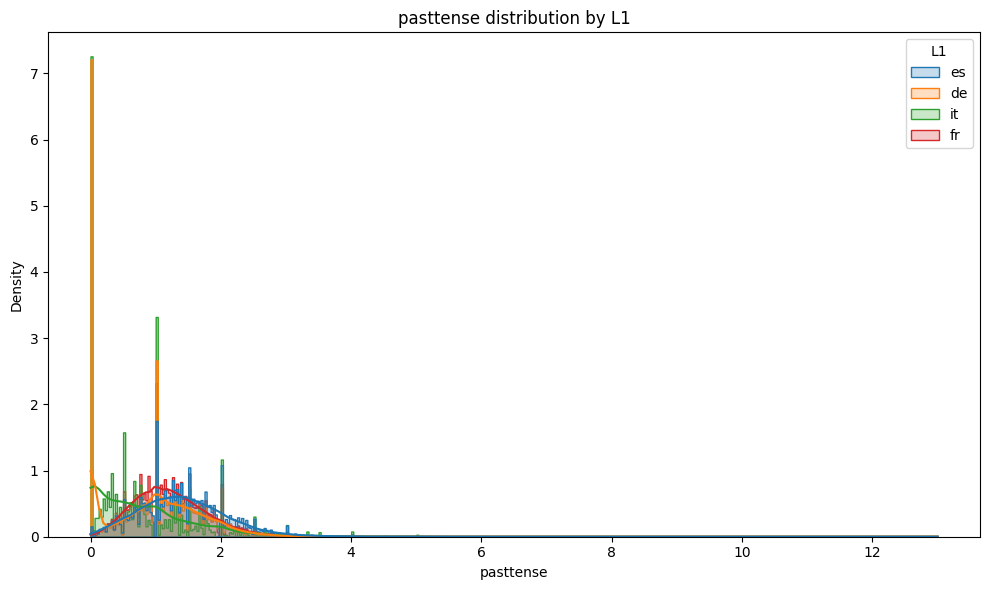

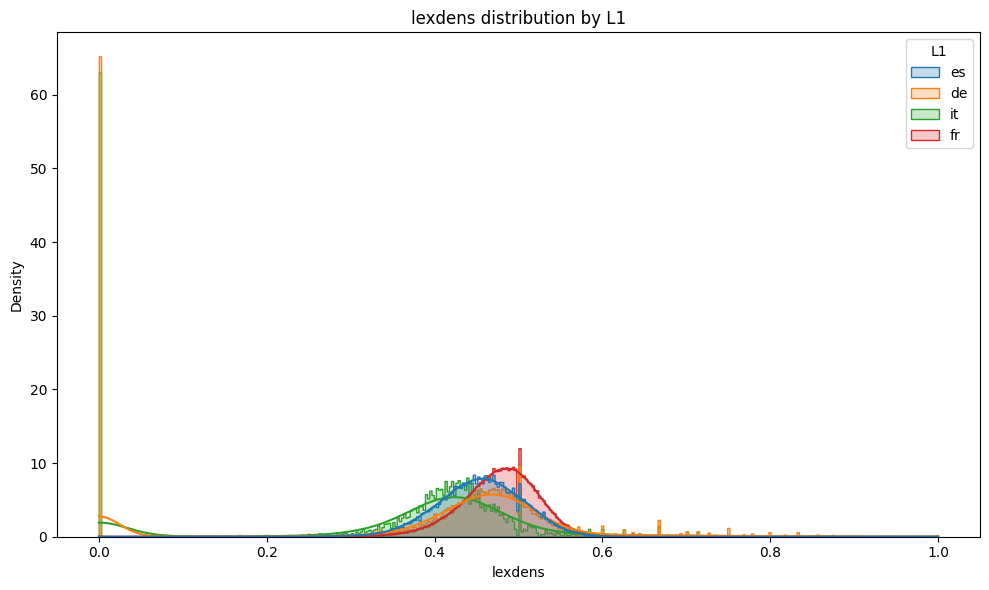

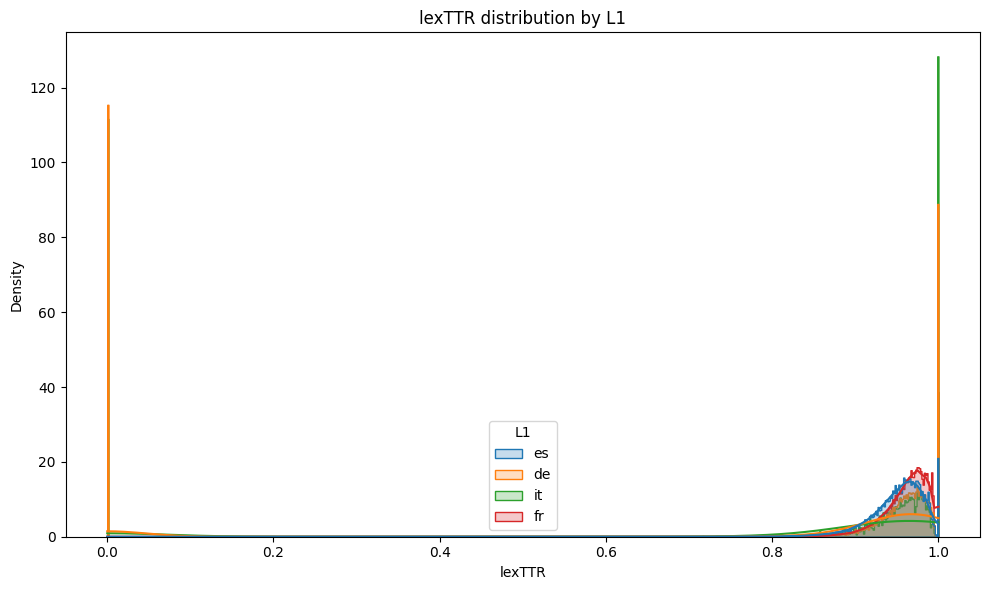

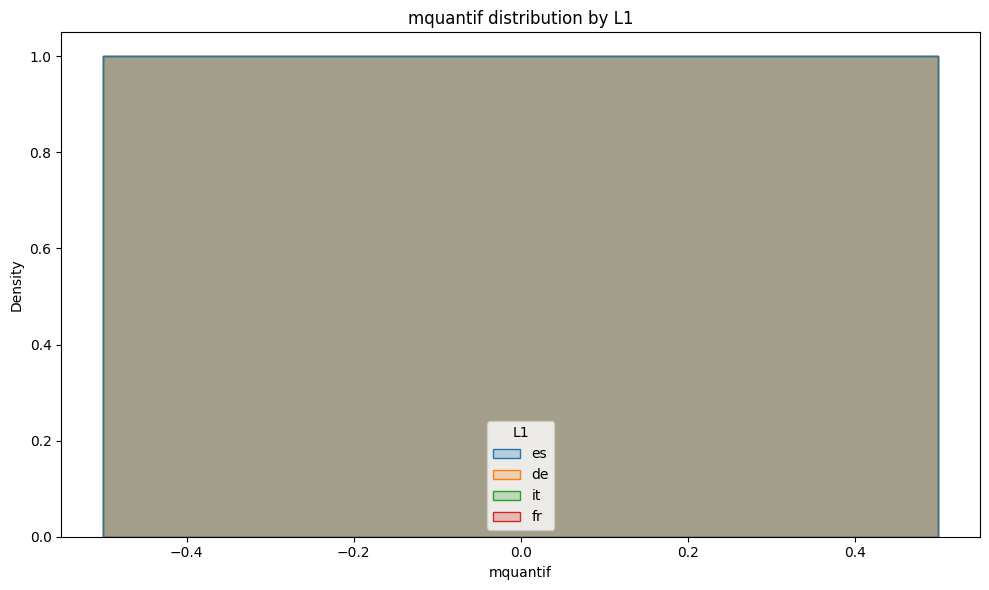

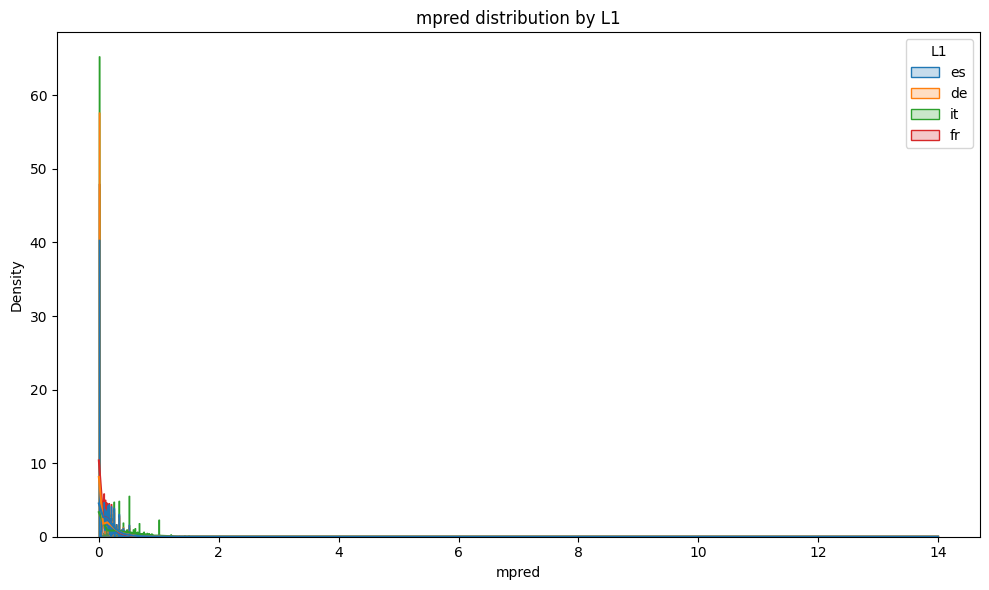

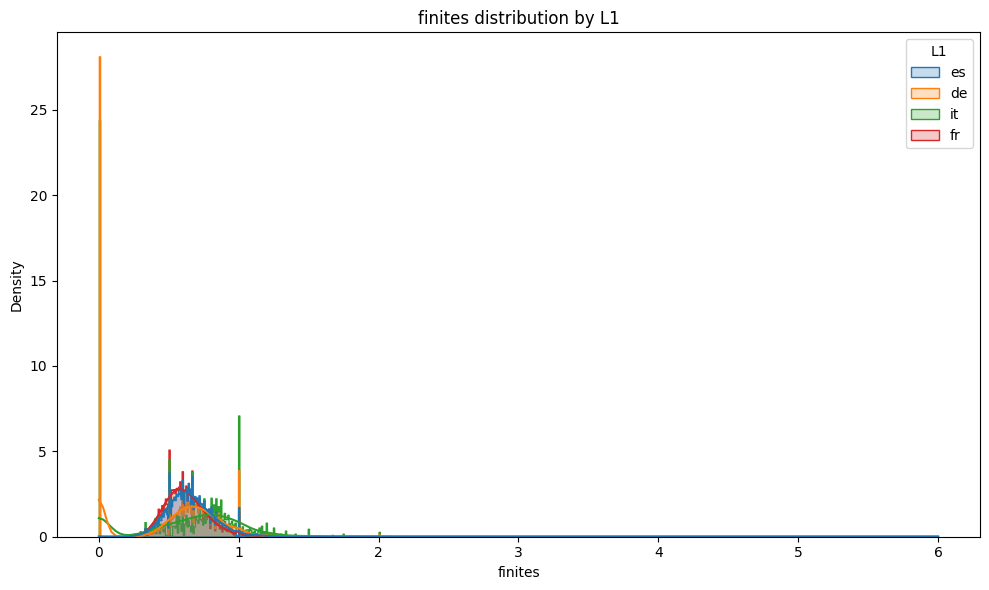

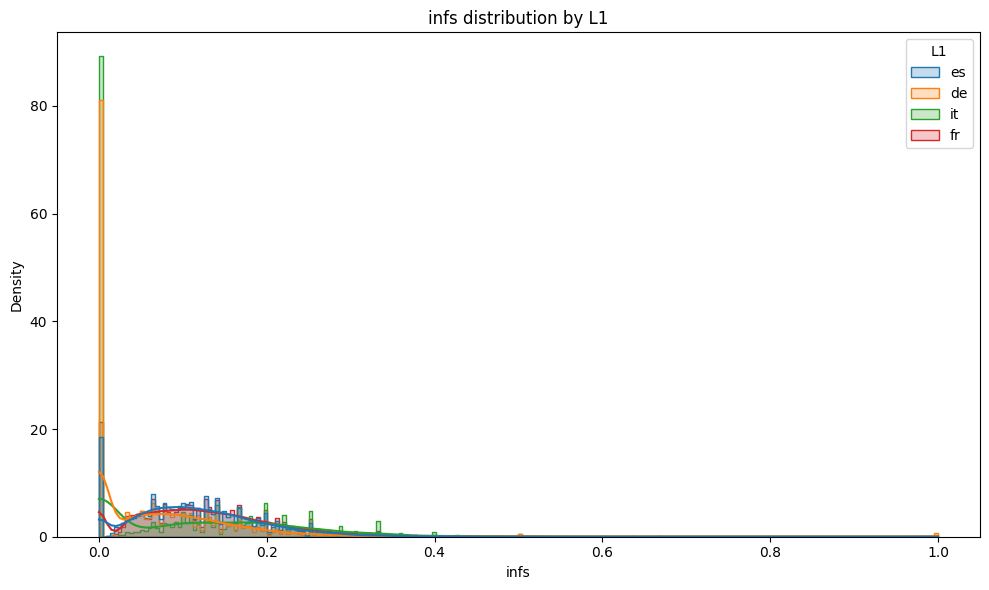

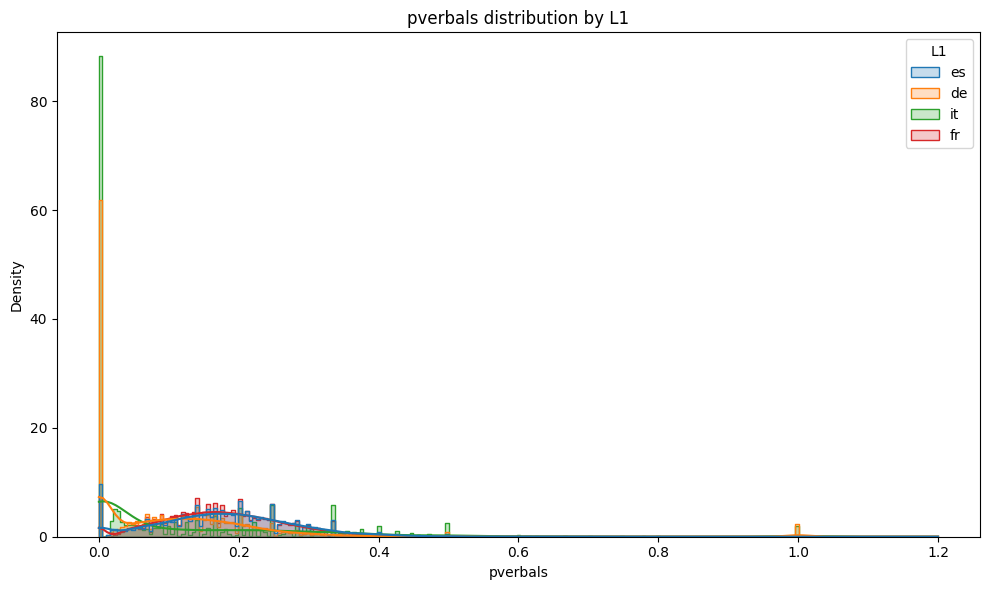

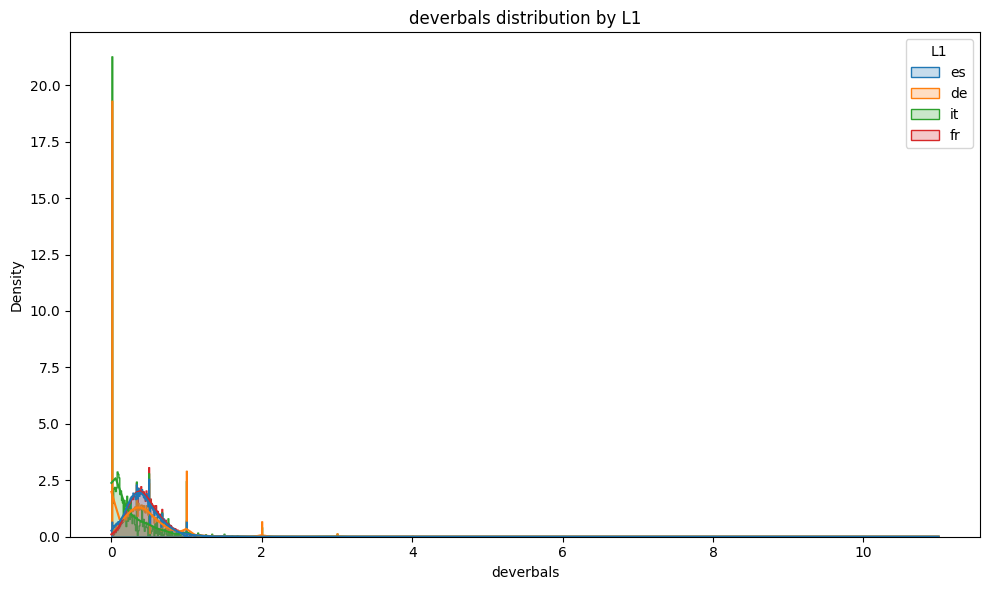

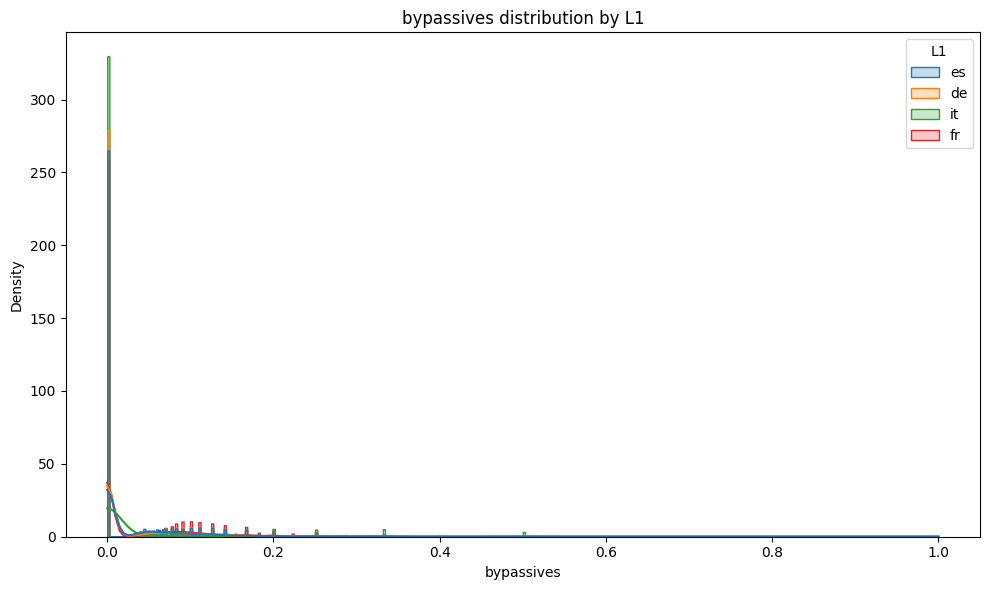

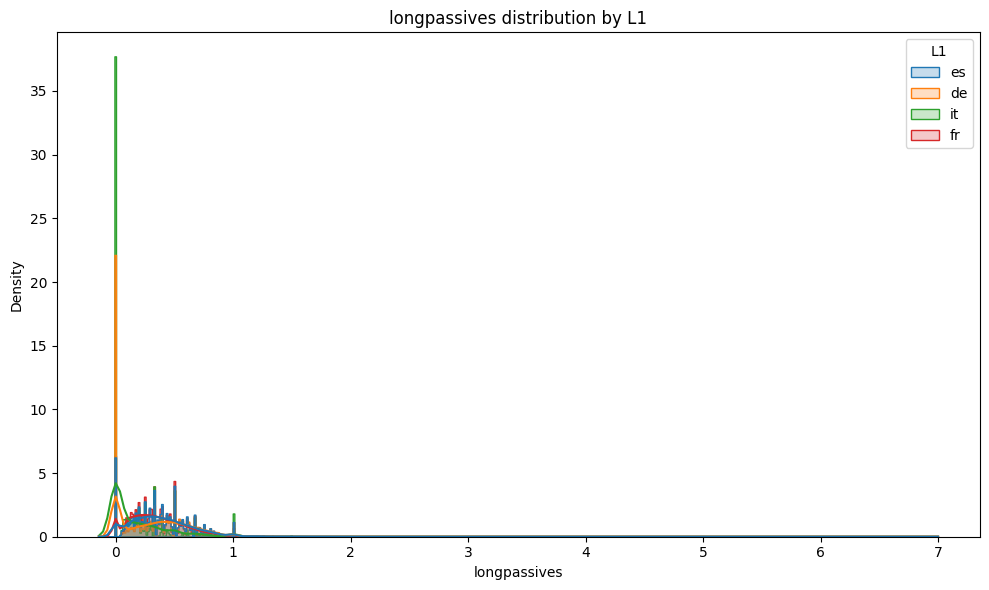

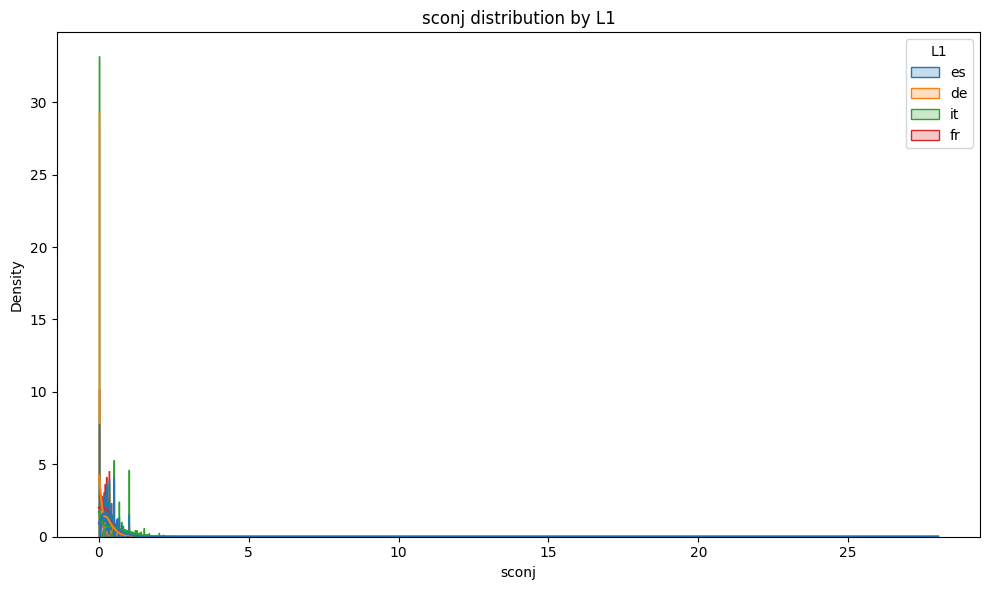

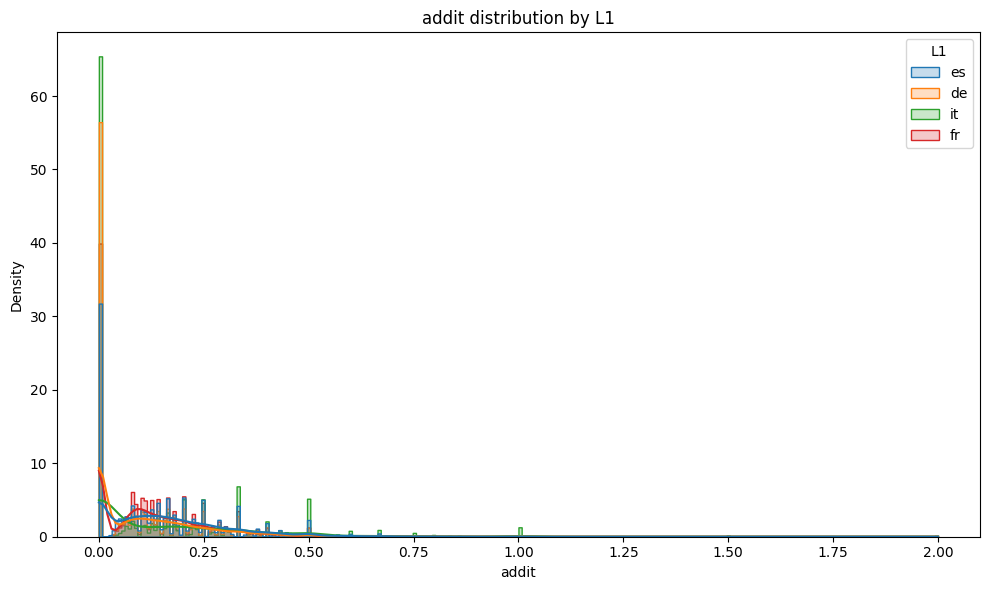

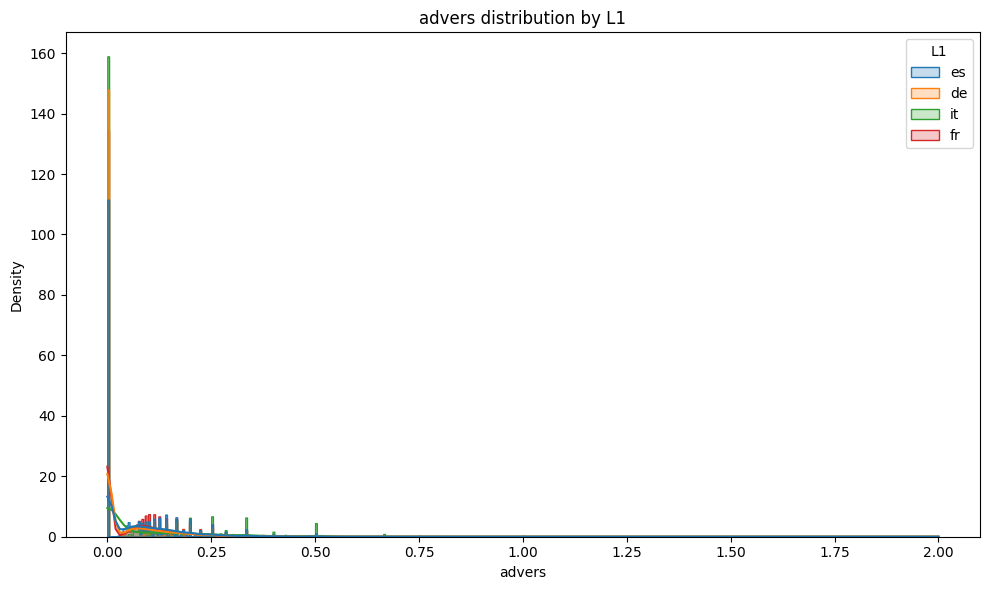

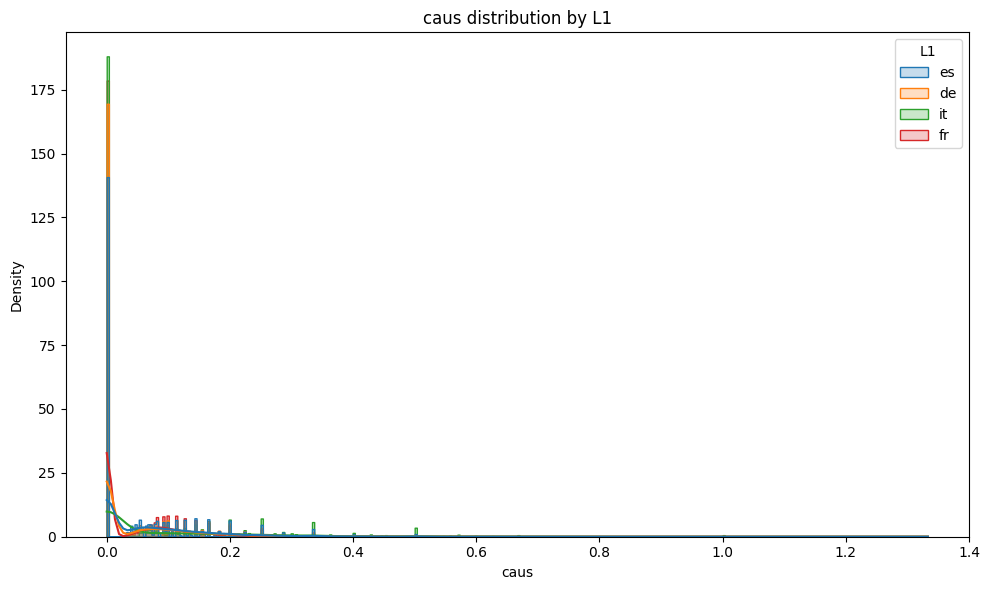

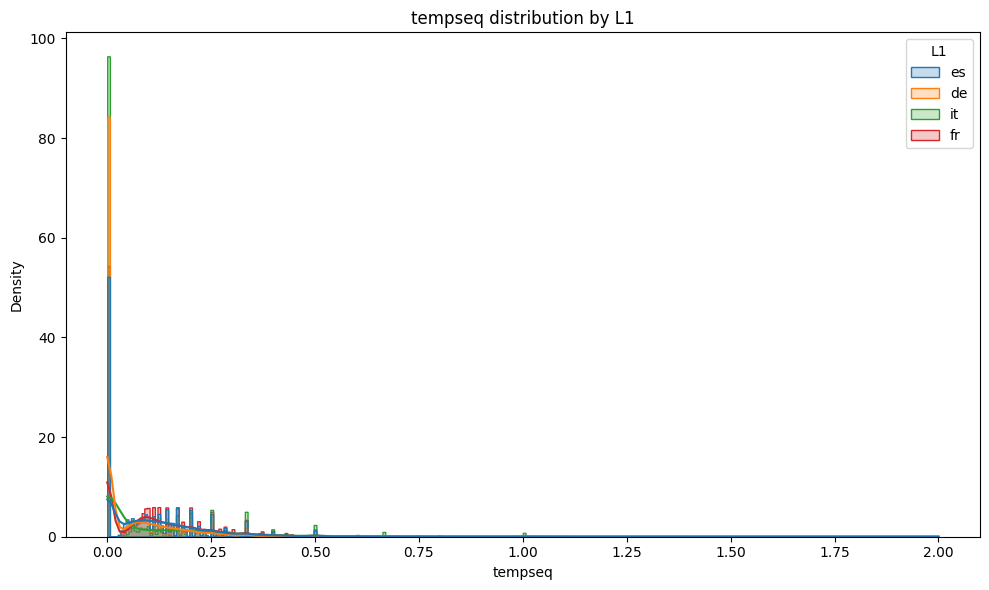

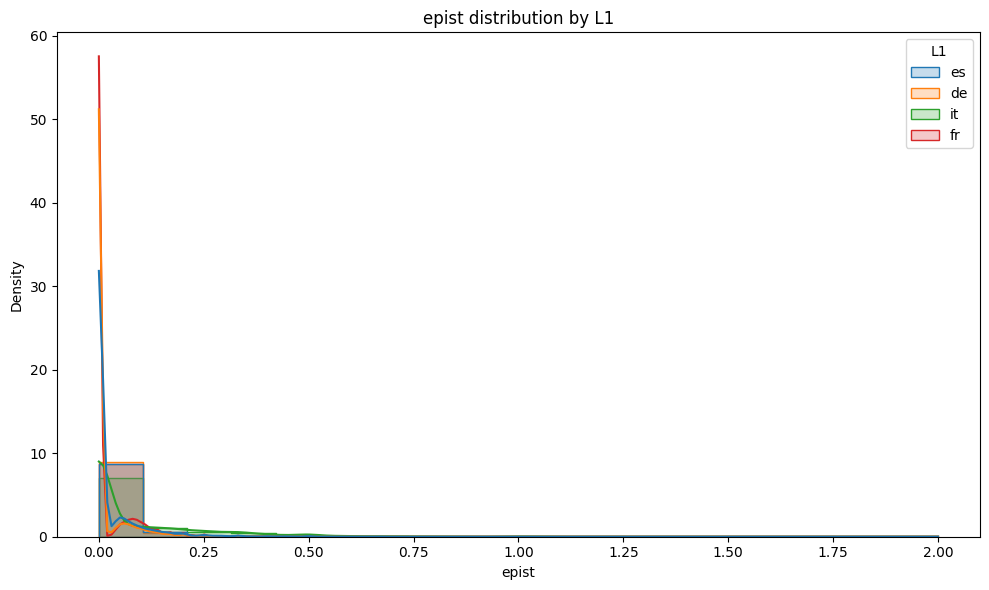

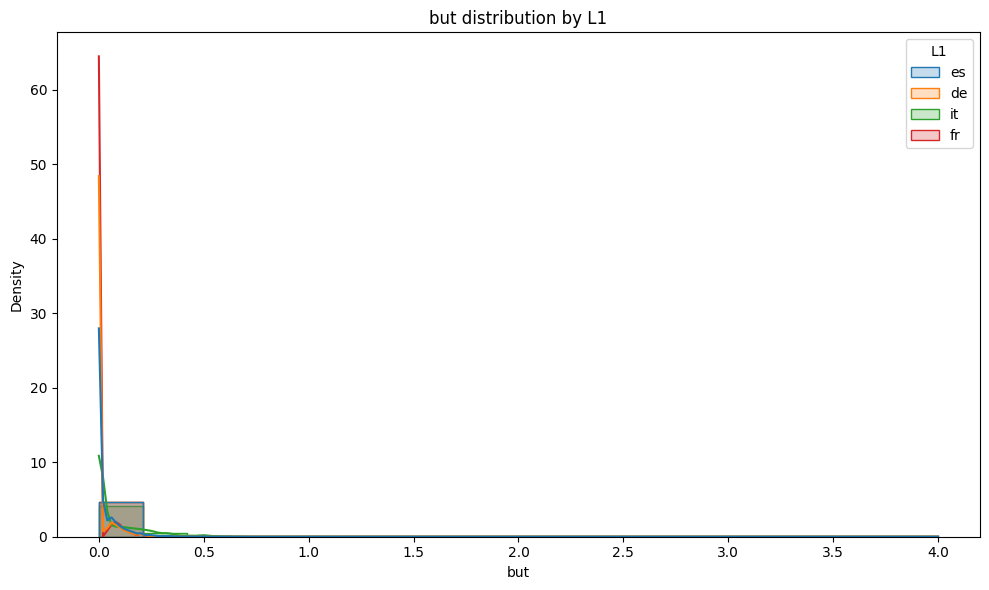

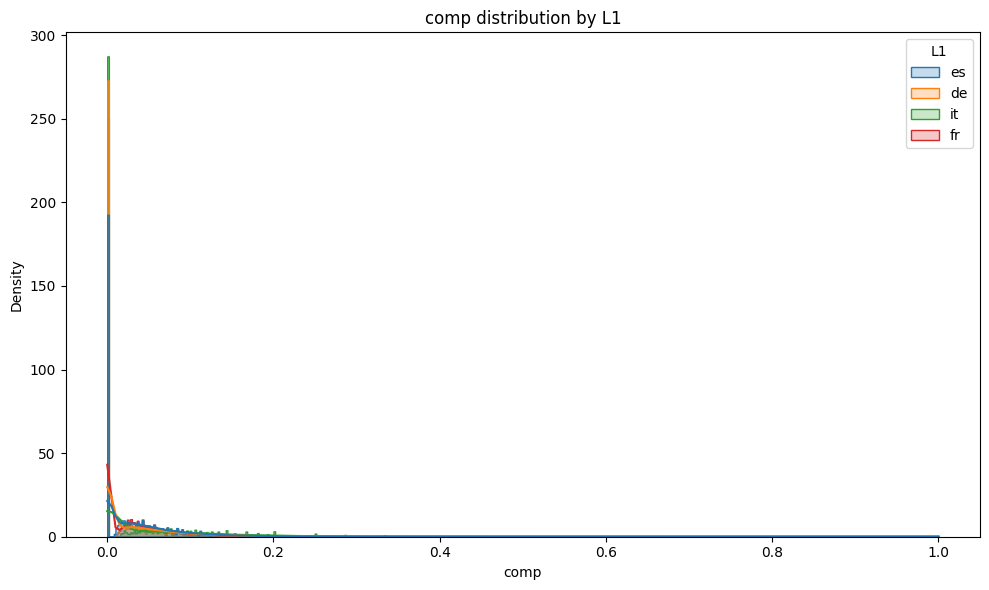

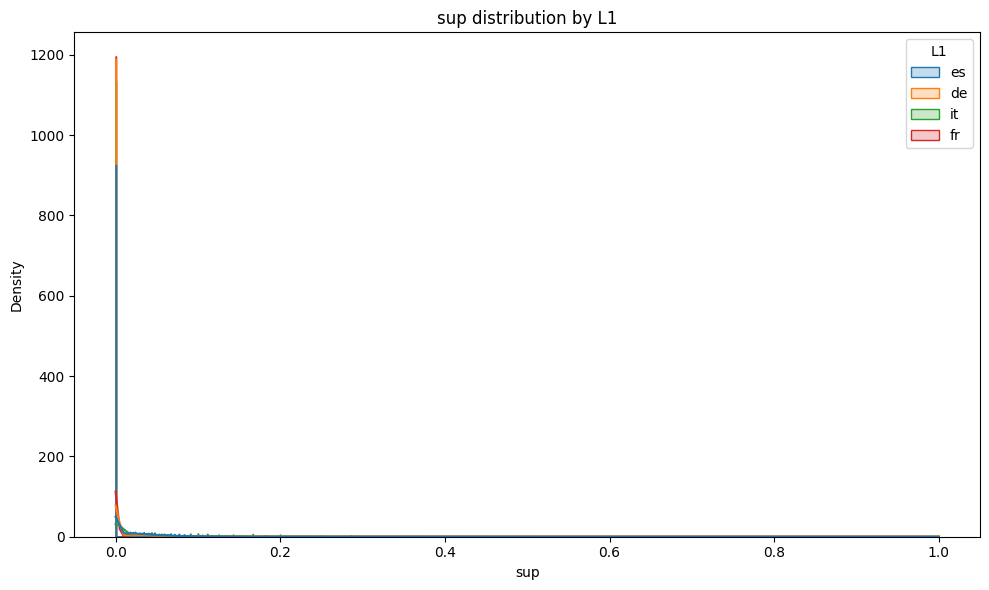

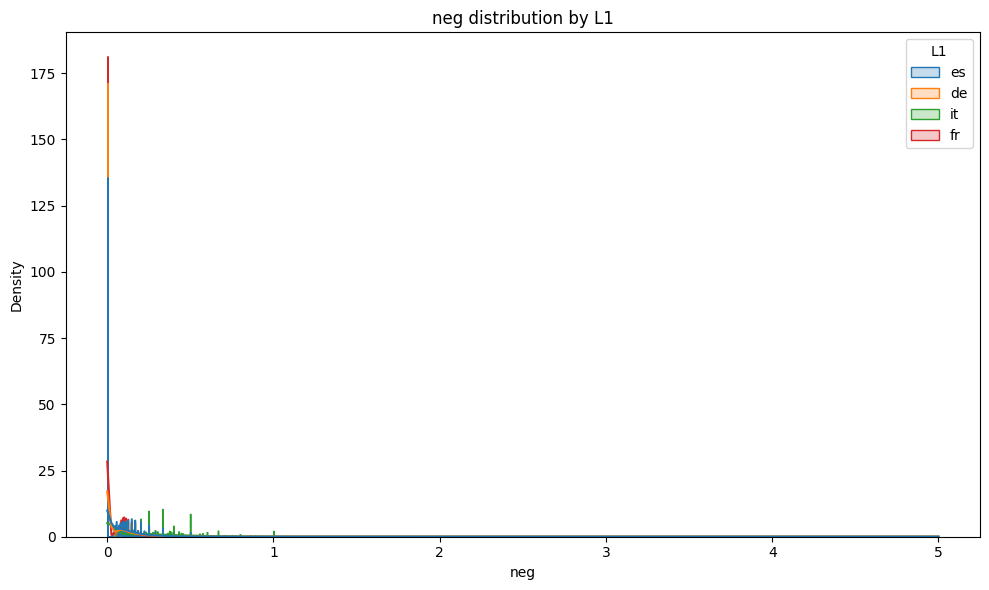

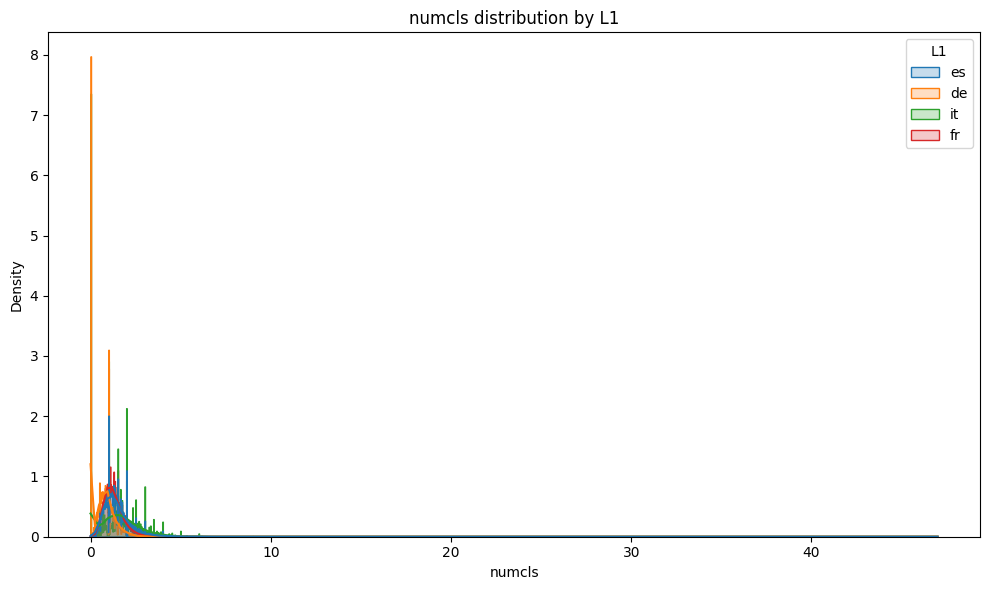

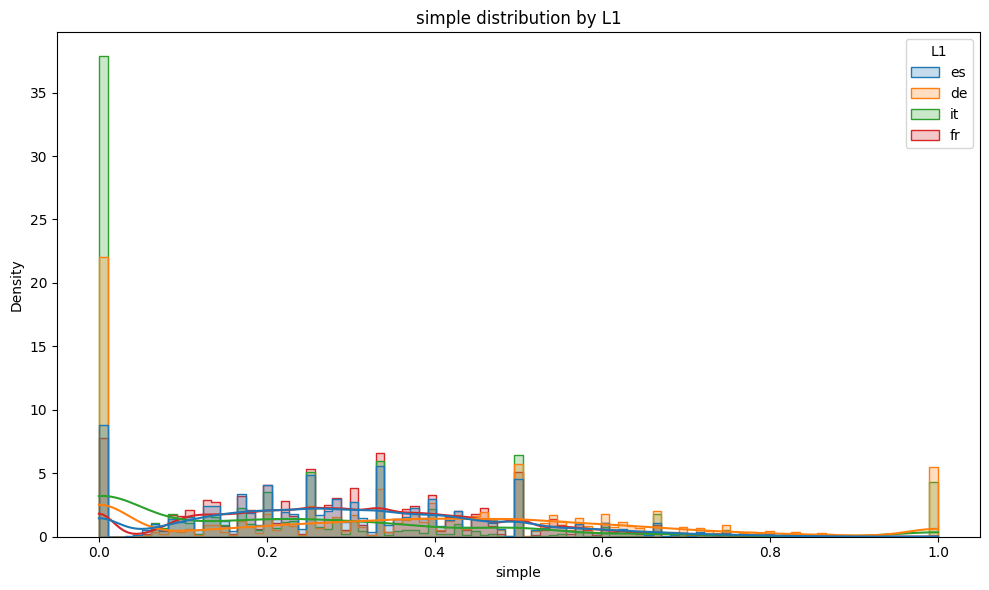

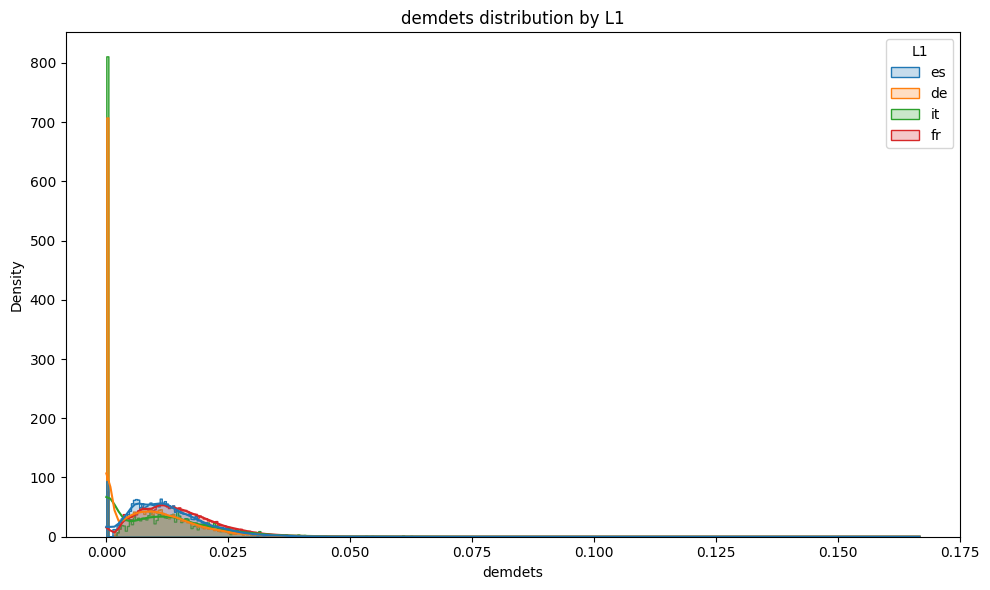

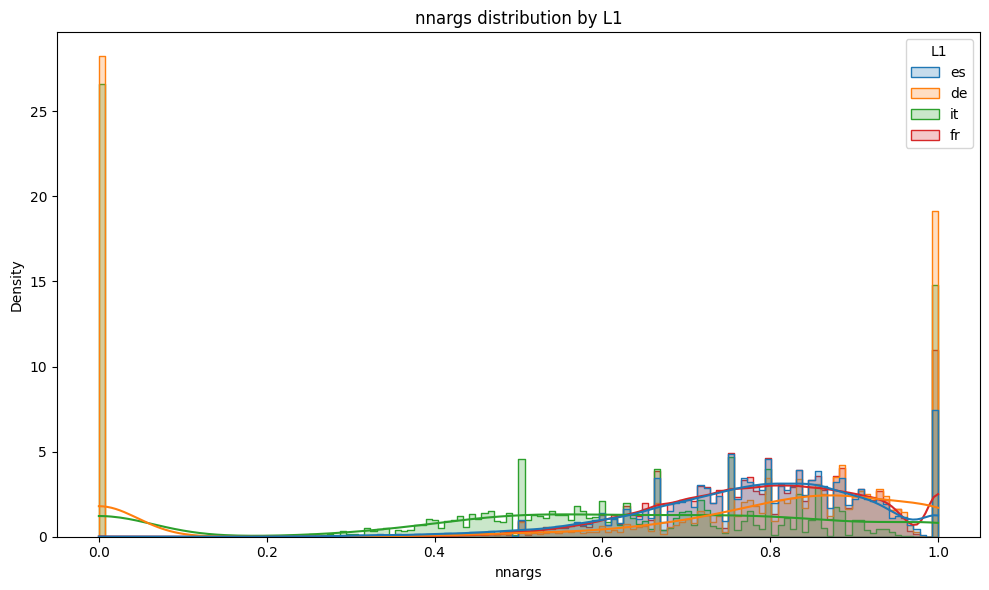

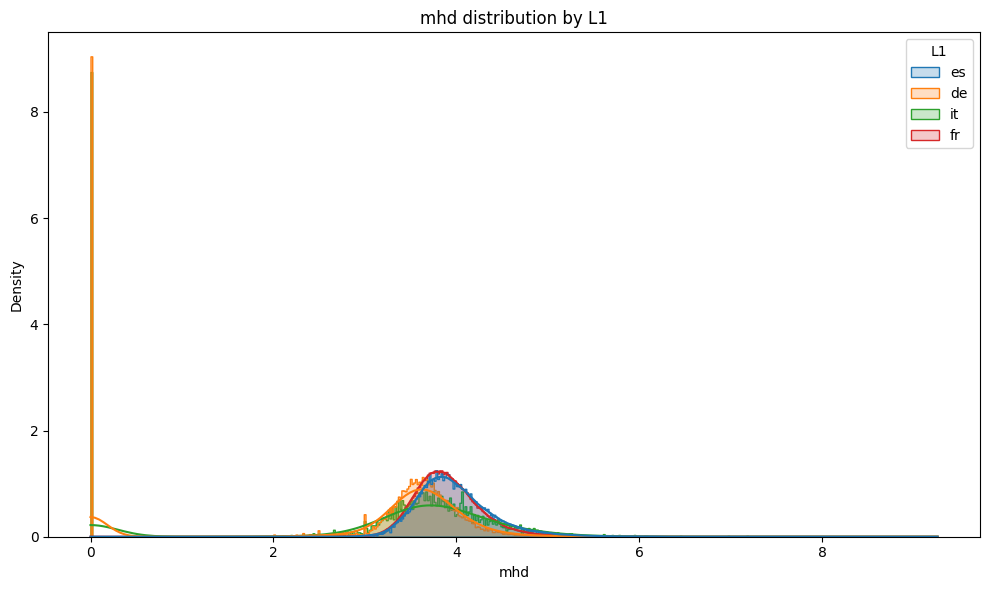

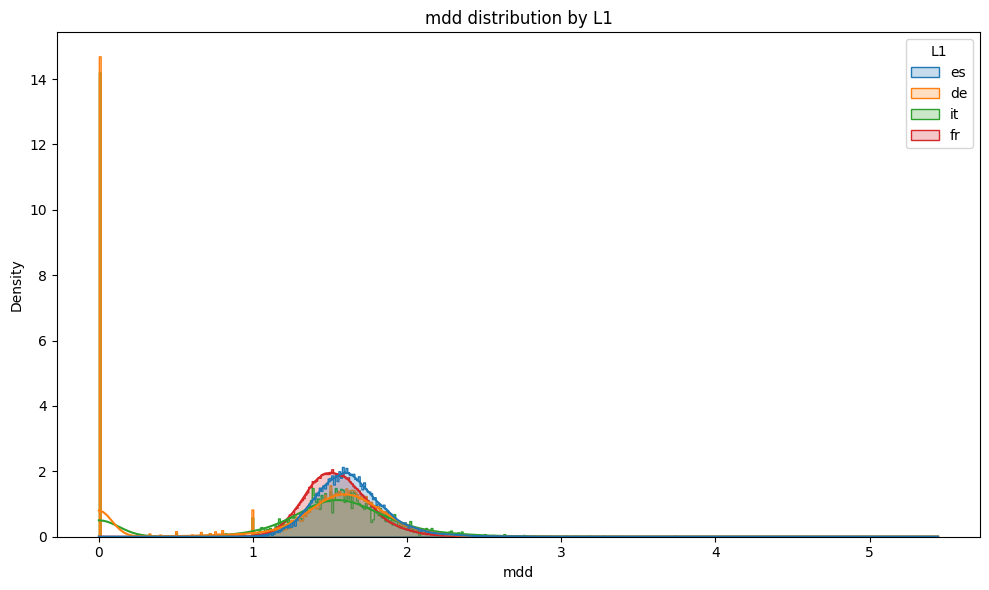

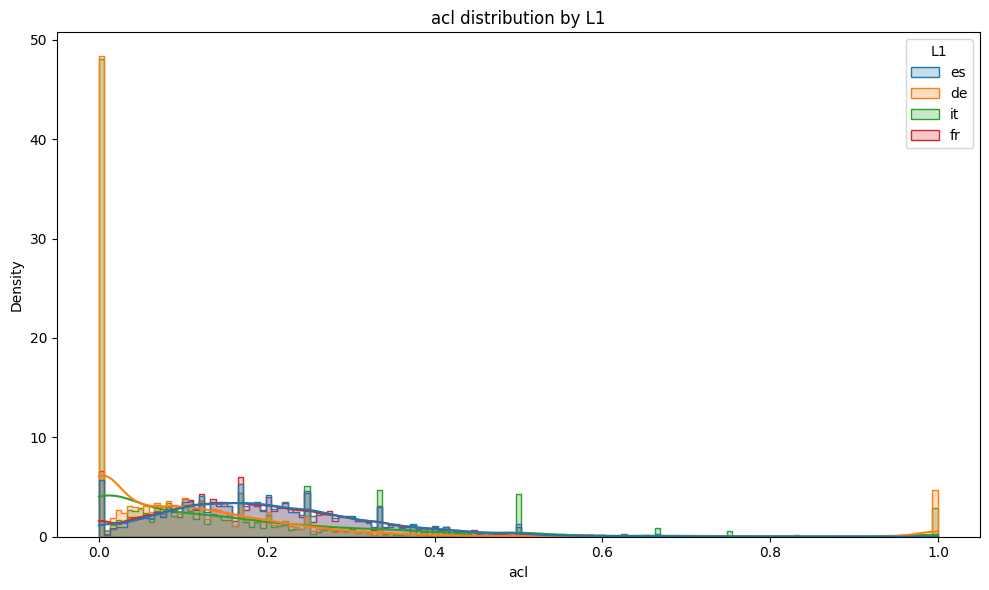

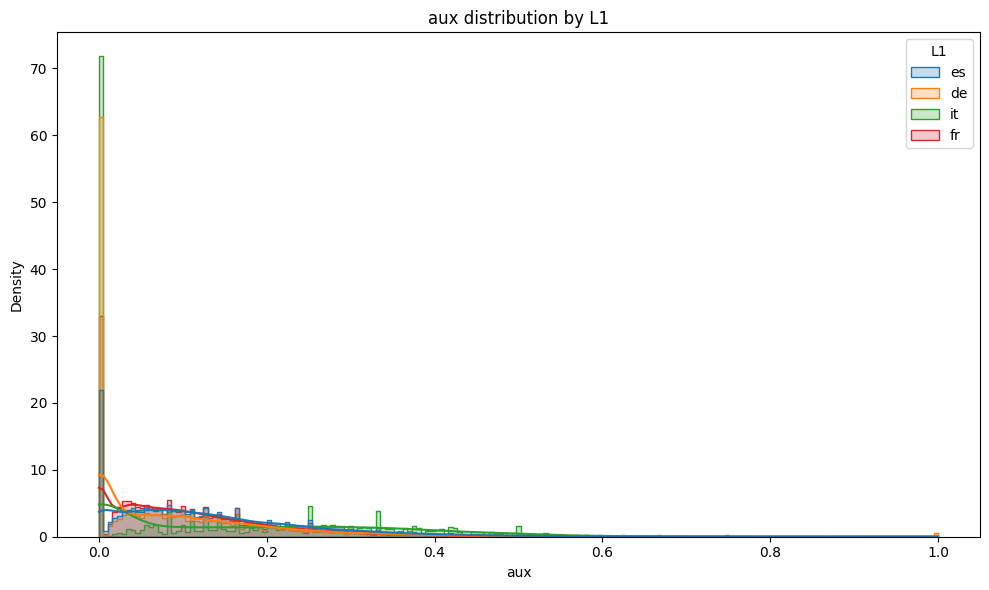

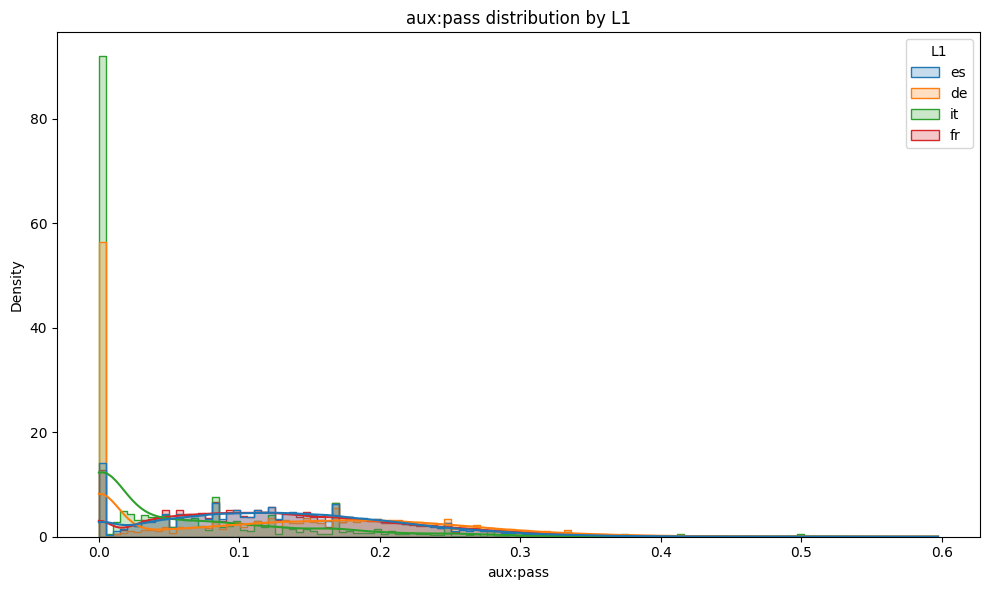

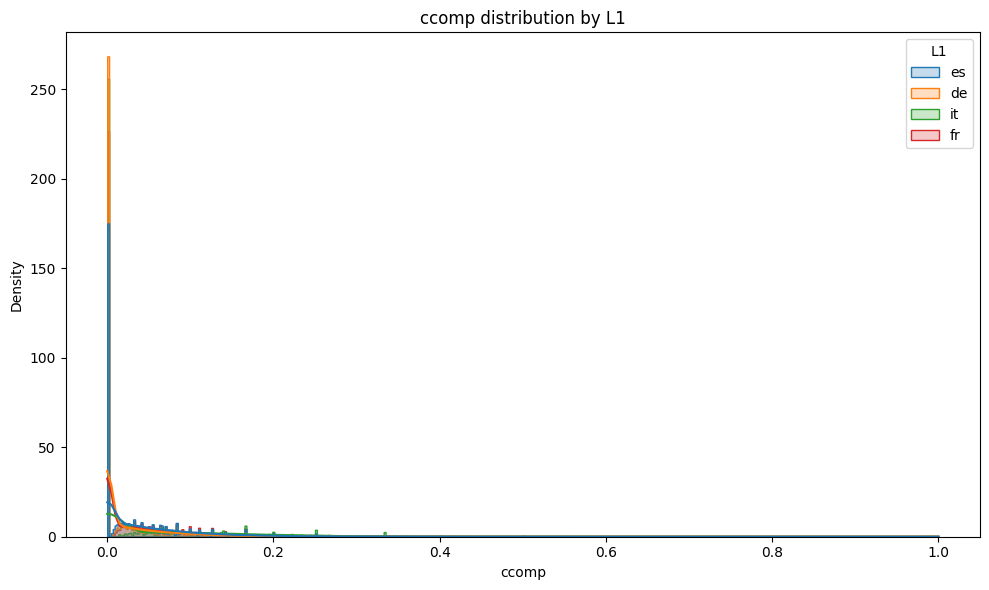

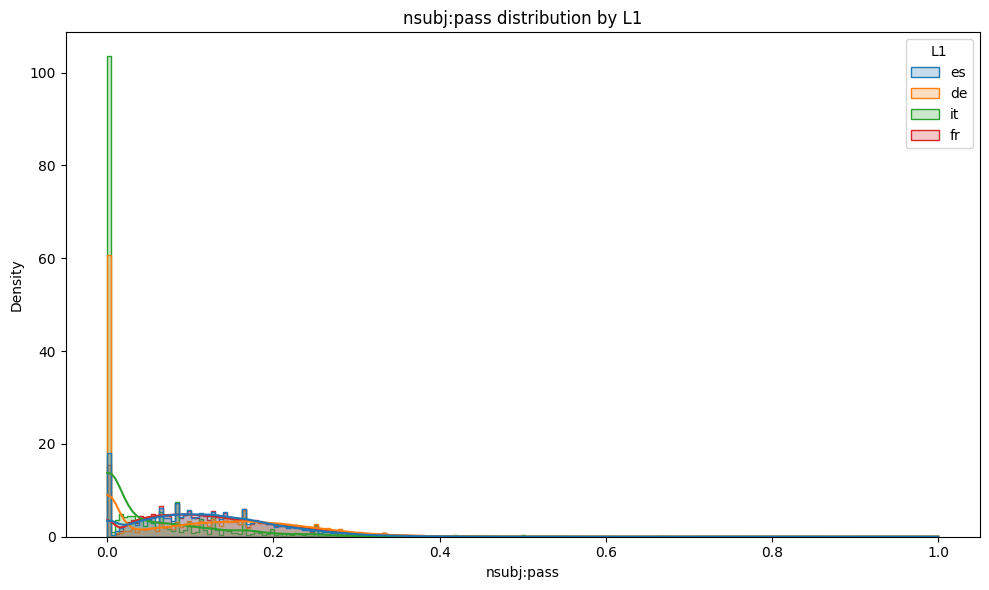

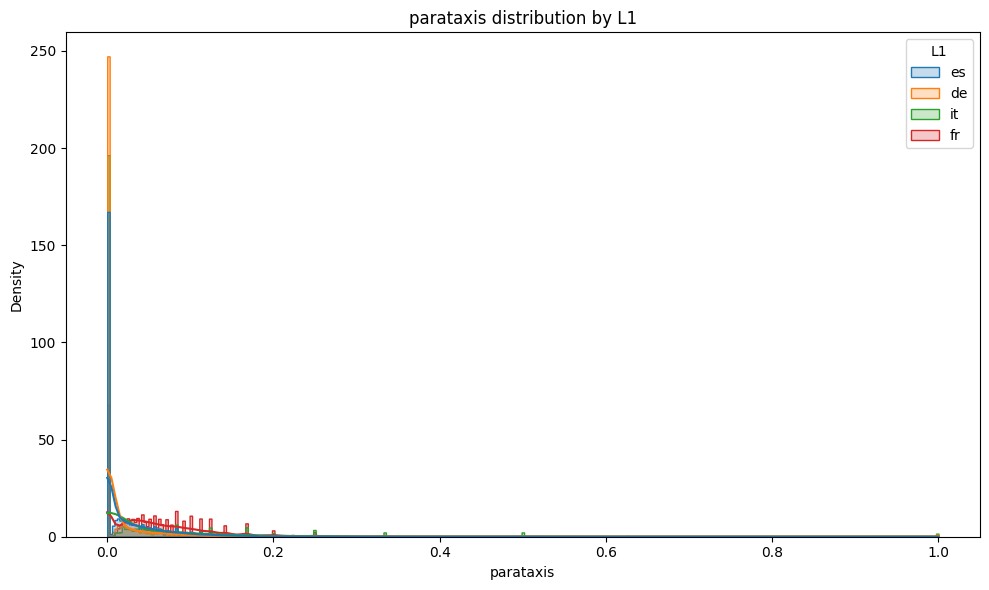

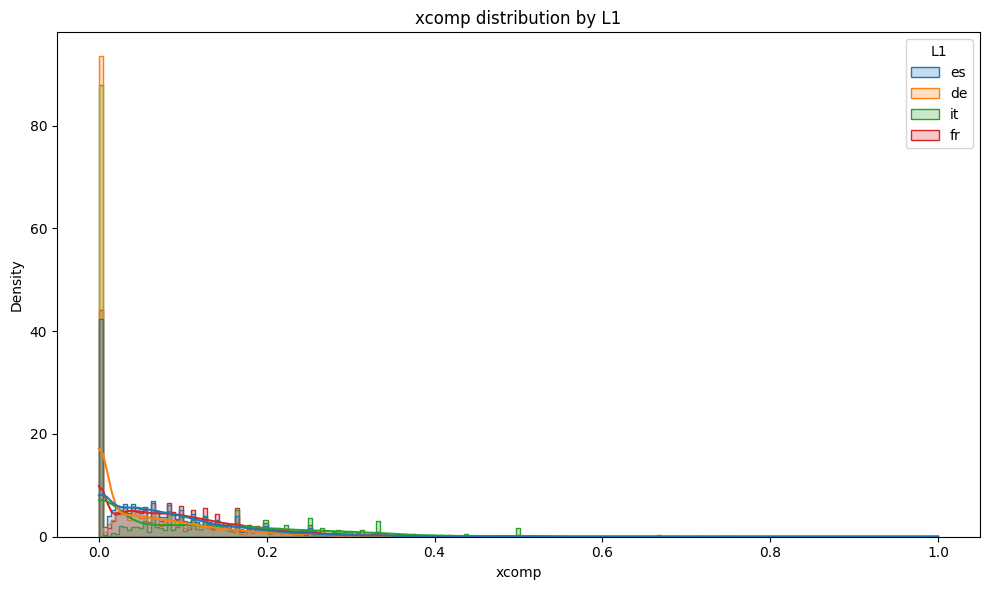

In [24]:

for col in num_cols:
    plt.figure(figsize=(10, 6))
    try:
      sns.histplot(
          data=df[df["L1"].isin(l1_groups)],
          x=col,
          hue="L1",
          kde=True,
          element="step",
          stat="density",
          common_norm=False,
          label = l1_groups
      )
    except:
      sns.histplot(
          data=df[df["L1"].isin(l1_groups)],
          x=col,
          hue="L1",
          element="step",
          stat="density",
          common_norm=False,
          label = l1_groups
      )

    plt.title(f"{col} distribution by L1")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.tight_layout()
    plt.show()
df = df.drop('L1',axis = 'columns')

#PCA

##PCA by L2 vs TR

In [26]:
df[num_cols]

,sentlength,ppron,possdet,indef,cconj,whconj,relativ,pied,correl,copula,...,nnargs,mhd,mdd,acl,aux,aux:pass,ccomp,nsubj:pass,parataxis,xcomp
0,51.875000,0.060241,0.004819,0.002410,2.500000,0.375000,1.000000,0.0,0.0,2.250000,...,0.547945,3.939911,2.099410,0.050000,0.491667,0.041667,0.087500,0.000000,0.112500,0.216667
1,22.769231,0.064189,0.037162,0.003378,0.538462,0.230769,0.307692,0.0,0.0,0.384615,...,0.545455,3.776333,1.435866,0.141026,0.371795,0.019231,0.205128,0.019231,0.000000,0.089744
2,21.866667,0.054878,0.006098,0.006098,0.666667,0.133333,0.266667,0.0,0.0,0.200000,...,0.520833,3.586628,1.380520,0.013333,0.457778,0.046667,0.166667,0.013333,0.035556,0.066667
3,34.916667,0.124105,0.023866,0.004773,1.750000,0.500000,0.333333,0.0,0.0,1.750000,...,0.352941,3.641703,1.688192,0.034226,0.132143,0.043155,0.220238,0.031250,0.236409,0.135913
4,18.636364,0.039024,0.017073,0.000000,0.909091,0.000000,0.136364,0.0,0.0,0.500000,...,0.595238,3.076063,1.286282,0.056818,0.147727,0.069697,0.060606,0.069697,0.022727,0.072727
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142535,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,...,1.000000,3.333333,1.166667,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
142536,5.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
142537,14.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,...,0.000000,3.090909,3.272727,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
142538,39.000000,0.000000,0.025641,0.000000,0.500000,0.000000,1.000000,0.0,0.0,1.000000,...,0.875000,3.976623,2.013636,0.875000,0.125000,0.000000,0.000000,0.000000,0.000000,0.000000


In [38]:
df.isna().sum()


,0
dataset_name,0
sentlength,143
ppron,0
possdet,0
indef,0
cconj,0
whconj,0
relativ,0
pied,0
correl,0


#t-SNE / UMAP (Uniform Manifold Approximation and Projection), a non-linear dimensionality reduction technique.
reveal fine-grained clusters not visible with PCA.

<Axes: >

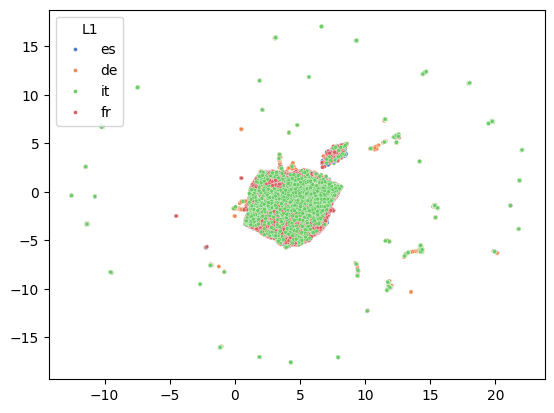

In [43]:
#t-SNE / UMAP for non-linear embedding
#Goal: reveal fine-grained clusters not visible with PCA.
import umap
embed = umap.UMAP(n_neighbors=15, min_dist=0.1).fit_transform(X)
sns.scatterplot(x=embed[:,0], y=embed[:,1], hue=df['L1'],  palette='muted',s=8)


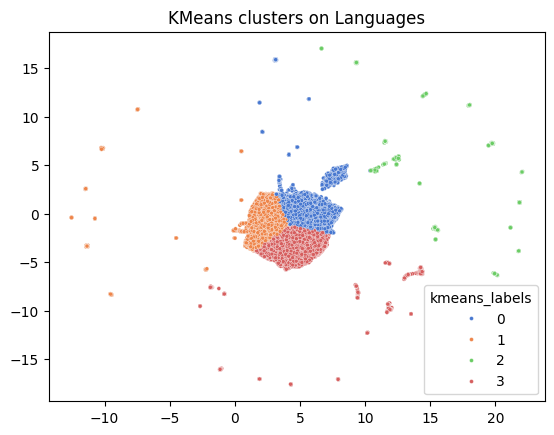

In [49]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# embed is your UMAP output (n_samples, 4)
kmeans = KMeans(n_clusters=4, random_state=42)  # k=2
labels = kmeans.fit_predict(embed)  # perform clustering

# Add KMeans labels to your dataframe (optional)
df['kmeans_labels'] = labels

# Visualize clusters on the UMAP embedding
sns.scatterplot(x=embed[:,0], y=embed[:,1], hue=df['kmeans_labels'], palette='muted', s=8)
plt.title("KMeans clusters on Languages")
plt.show()


Clustering Accuracy: 0.6572821664094289
Predicted    de     fr
True                  
de         2979  25864
es            2  19702
fr           16  90710
it          304   2963


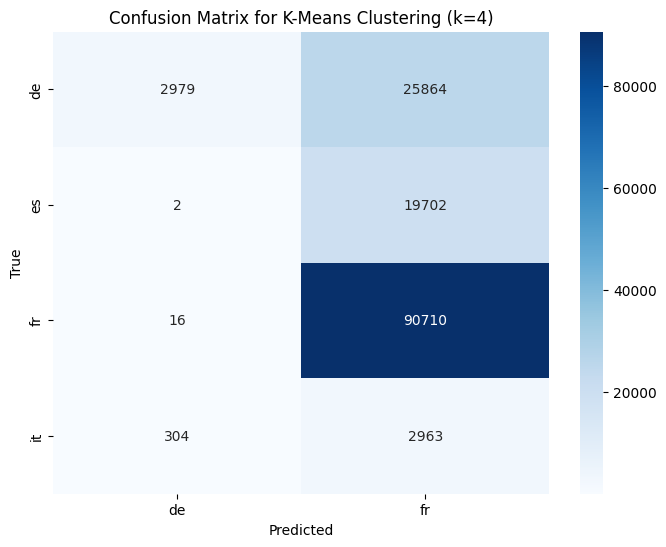

In [50]:

import numpy as np
from sklearn.metrics import accuracy_score
import pandas as pd

y_true = df['L1'].values
y_pred = df['kmeans_labels'].values

# Map each cluster to the majority true label inside that cluster
mapped_pred = np.empty_like(y_pred, dtype=object)

for cluster in np.unique(y_pred):
    mask = (y_pred == cluster)
    true_subset = y_true[mask]

    unique_labels, counts = np.unique(true_subset, return_counts=True)
    majority_label = unique_labels[np.argmax(counts)]

    mapped_pred[mask] = majority_label

accuracy = accuracy_score(y_true, mapped_pred)
print("Clustering Accuracy:", accuracy)
conf_mat = pd.crosstab(y_true, mapped_pred, rownames=['True'], colnames=['Predicted'])
print(conf_mat)

plt.figure(figsize=(8,6))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for K-Means Clustering (k=4)')
plt.show()


<Axes: >

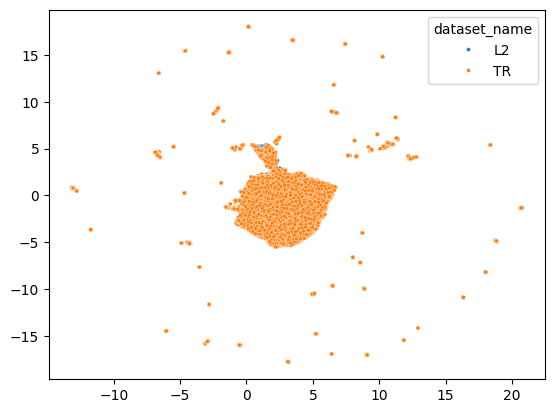

In [52]:
#t-SNE / UMAP for non-linear embedding
#Goal: reveal fine-grained clusters not visible with PCA.
import umap
embed = umap.UMAP(n_neighbors=15, min_dist=0.1).fit_transform(X)
sns.scatterplot(x=embed[:,0], y=embed[:,1], hue=df['dataset_name'], s=8)


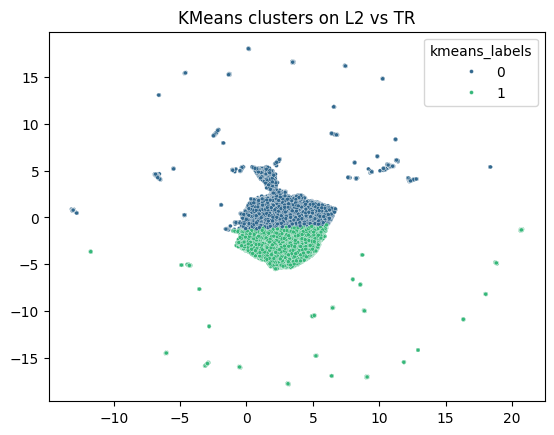

In [53]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# embed is your UMAP output (n_samples, 2)
kmeans = KMeans(n_clusters=2, random_state=42)  # k=2
labels = kmeans.fit_predict(embed)  # perform clustering

# Add KMeans labels to your dataframe (optional)
df['kmeans_labels'] = labels

# Visualize clusters on the UMAP embedding
sns.scatterplot(x=embed[:,0], y=embed[:,1], hue=df['kmeans_labels'], palette='viridis', s=8)
plt.title("KMeans clusters on L2 vs TR")
plt.show()


#Feature importance using a tree-based classifier

Text(0.5, 1.0, 'Top 20 Feature Importances')

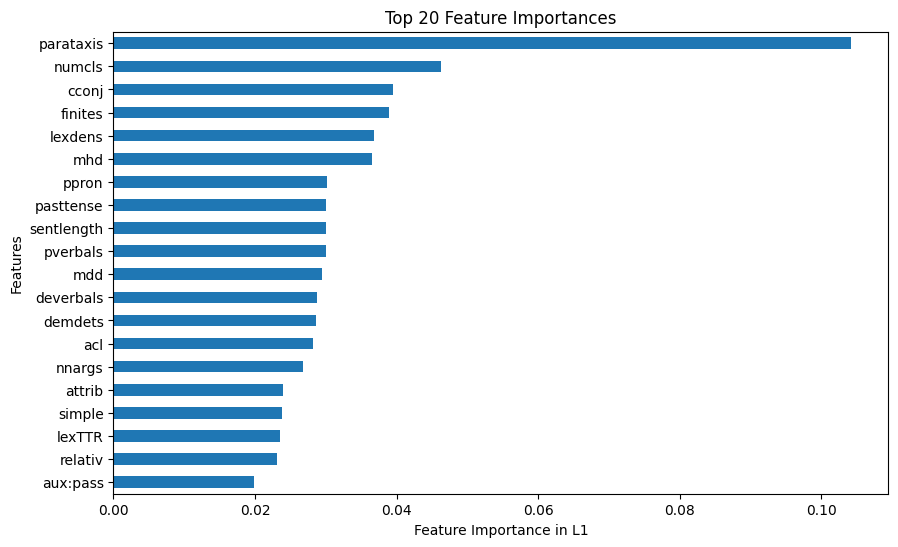

In [54]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df[num_cols], df['L1'], stratify=df['L1'])
rf = RandomForestClassifier(n_estimators=200).fit(X_train, y_train)
importances = pd.Series(rf.feature_importances_, index=num_cols).sort_values(ascending=False)
top_features = importances.head(20)[::-1]# reverses the top 20 features for correct horizontal orientation

ax = top_features.plot.barh(figsize=(10,6))
ax.set_xlabel("Feature Importance in L1")
ax.set_ylabel("Features")
ax.set_title("Top 20 Feature Importances")

Text(0.5, 1.0, 'Top 20 Feature Importances')

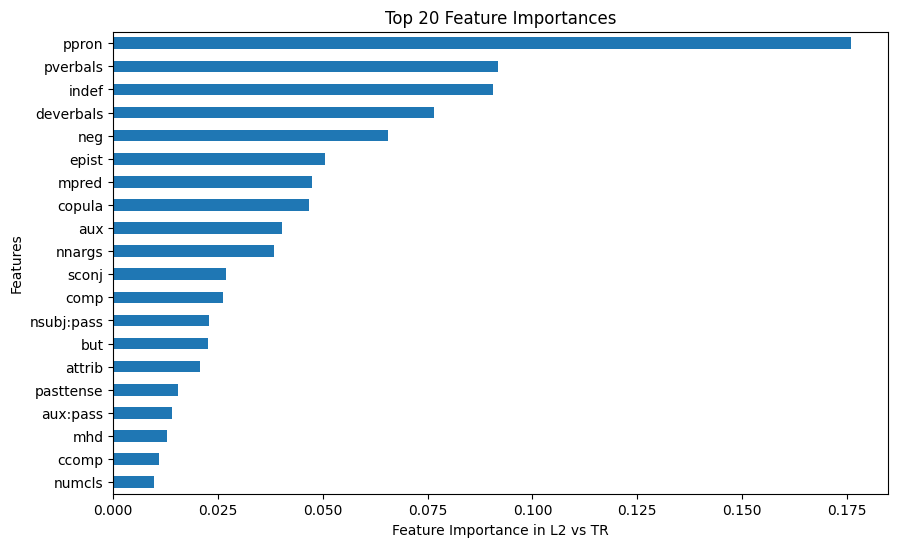

In [57]:
#NEW

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df[num_cols], df['dataset_name'], stratify=df['dataset_name'])
rf = RandomForestClassifier(n_estimators=200).fit(X_train, y_train)
importances = pd.Series(rf.feature_importances_, index=num_cols).sort_values(ascending=False)
top_features = importances.head(20)[::-1]# reverses the top 20 features for correct horizontal orientation

ax = top_features.plot.barh(figsize=(10,6))
ax.set_xlabel("Feature Importance in L2 vs TR")   # X-axis label
ax.set_ylabel("Features")             # Y-axis label
ax.set_title("Top 20 Feature Importances")  # Optional: title


#Outlier Detection


In [58]:
from sklearn.ensemble import IsolationForest
iso = IsolationForest(contamination=0.01).fit(X)
df['anomaly'] = iso.predict(X)  # -1 is anomaly
df[df['anomaly']==-1]


,dataset_name,sentlength,ppron,possdet,indef,cconj,whconj,relativ,pied,correl,...,acl,aux,aux:pass,ccomp,nsubj:pass,parataxis,xcomp,L1,kmeans_labels,anomaly
0,L2,51.875000,0.060241,0.004819,0.002410,2.500000,0.375000,1.000000,0.000000,0.0,...,0.050000,0.491667,0.041667,0.087500,0.000000,0.112500,0.216667,es,0,-1
3,L2,34.916667,0.124105,0.023866,0.004773,1.750000,0.500000,0.333333,0.000000,0.0,...,0.034226,0.132143,0.043155,0.220238,0.031250,0.236409,0.135913,es,0,-1
5,L2,29.416667,0.073654,0.002833,0.000000,1.083333,0.166667,0.250000,0.083333,0.0,...,0.106481,0.340278,0.013889,0.115741,0.013889,0.009259,0.317130,it,0,-1
11,L2,21.117647,0.066852,0.013928,0.005571,0.647059,0.000000,0.529412,0.000000,0.0,...,0.041176,0.366667,0.000000,0.139216,0.000000,0.078431,0.198039,fr,0,-1
14,L2,39.571429,0.064982,0.003610,0.018051,0.714286,0.285714,1.428571,0.000000,0.0,...,0.064286,0.471429,0.100000,0.028571,0.071429,0.071429,0.192857,es,0,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142293,TR,63.666667,0.013089,0.002618,0.000000,2.333333,0.000000,0.500000,0.000000,0.0,...,0.234921,0.079365,0.112698,0.000000,0.051587,0.055556,0.299206,it,0,-1
142468,TR,32.500000,0.015385,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.0,...,0.000000,0.000000,0.083333,0.083333,0.083333,0.250000,0.500000,it,0,-1
142472,TR,39.000000,0.008547,0.008547,0.000000,1.333333,0.000000,1.000000,0.000000,0.0,...,0.000000,0.150000,0.216667,0.000000,0.216667,0.000000,0.083333,it,0,-1
142475,TR,73.500000,0.006803,0.000000,0.000000,2.500000,0.000000,2.000000,0.500000,0.0,...,0.416667,0.333333,0.000000,0.000000,0.000000,0.000000,0.250000,it,0,-1


In [59]:
num=num_cols

In [60]:
#Multicollinearity check: VIF (variance inflation factor)
#Goal: quantify redundancy for regression models.
#Insight: drop or combine high-VIF features.
from statsmodels.stats.outliers_influence import variance_inflation_factor
X = df[num].fillna(0)
vif = pd.Series([variance_inflation_factor(X.values, i) for i in range(X.shape[1])], index=X.columns)
vif.sort_values(ascending=False).head(20)


/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


,0
lexTTR,450.108899
mhd,262.659818
lexdens,135.966065
mdd,78.788545
sentlength,67.397033
nnargs,56.783924
aux:pass,38.696872
finites,33.378845
numcls,31.784220
nsubj:pass,27.246055


#Finding Optimal K


Text(0, 0.5, 'inertia')

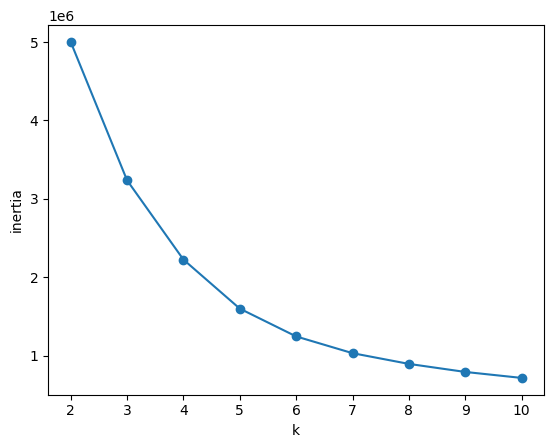

In [61]:
from sklearn.cluster import KMeans
inertia=[]
for k in range(2,11):
    inertia.append(KMeans(k, random_state=0).fit(X).inertia_)
plt.plot(range(2,11), inertia, '-o'); plt.xlabel('k'); plt.ylabel('inertia')


#K-means

In [62]:
X


,sentlength,ppron,possdet,indef,cconj,whconj,relativ,pied,correl,copula,...,nnargs,mhd,mdd,acl,aux,aux:pass,ccomp,nsubj:pass,parataxis,xcomp
0,51.875000,0.060241,0.004819,0.002410,2.500000,0.375000,1.000000,0.0,0.0,2.250000,...,0.547945,3.939911,2.099410,0.050000,0.491667,0.041667,0.087500,0.000000,0.112500,0.216667
1,22.769231,0.064189,0.037162,0.003378,0.538462,0.230769,0.307692,0.0,0.0,0.384615,...,0.545455,3.776333,1.435866,0.141026,0.371795,0.019231,0.205128,0.019231,0.000000,0.089744
2,21.866667,0.054878,0.006098,0.006098,0.666667,0.133333,0.266667,0.0,0.0,0.200000,...,0.520833,3.586628,1.380520,0.013333,0.457778,0.046667,0.166667,0.013333,0.035556,0.066667
3,34.916667,0.124105,0.023866,0.004773,1.750000,0.500000,0.333333,0.0,0.0,1.750000,...,0.352941,3.641703,1.688192,0.034226,0.132143,0.043155,0.220238,0.031250,0.236409,0.135913
4,18.636364,0.039024,0.017073,0.000000,0.909091,0.000000,0.136364,0.0,0.0,0.500000,...,0.595238,3.076063,1.286282,0.056818,0.147727,0.069697,0.060606,0.069697,0.022727,0.072727
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142535,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,...,1.000000,3.333333,1.166667,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
142536,5.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
142537,14.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,...,0.000000,3.090909,3.272727,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
142538,39.000000,0.000000,0.025641,0.000000,0.500000,0.000000,1.000000,0.0,0.0,1.000000,...,0.875000,3.976623,2.013636,0.875000,0.125000,0.000000,0.000000,0.000000,0.000000,0.000000


In [64]:
df

,dataset_name,sentlength,ppron,possdet,indef,cconj,whconj,relativ,pied,correl,...,acl,aux,aux:pass,ccomp,nsubj:pass,parataxis,xcomp,L1,kmeans_labels,anomaly
0,L2,51.875000,0.060241,0.004819,0.002410,2.500000,0.375000,1.000000,0.0,0.0,...,0.050000,0.491667,0.041667,0.087500,0.000000,0.112500,0.216667,es,0,-1
1,L2,22.769231,0.064189,0.037162,0.003378,0.538462,0.230769,0.307692,0.0,0.0,...,0.141026,0.371795,0.019231,0.205128,0.019231,0.000000,0.089744,de,0,1
2,L2,21.866667,0.054878,0.006098,0.006098,0.666667,0.133333,0.266667,0.0,0.0,...,0.013333,0.457778,0.046667,0.166667,0.013333,0.035556,0.066667,de,0,1
3,L2,34.916667,0.124105,0.023866,0.004773,1.750000,0.500000,0.333333,0.0,0.0,...,0.034226,0.132143,0.043155,0.220238,0.031250,0.236409,0.135913,es,0,-1
4,L2,18.636364,0.039024,0.017073,0.000000,0.909091,0.000000,0.136364,0.0,0.0,...,0.056818,0.147727,0.069697,0.060606,0.069697,0.022727,0.072727,de,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142535,TR,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,it,1,1
142536,TR,5.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,it,1,1
142537,TR,14.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,it,0,1
142538,TR,39.000000,0.000000,0.025641,0.000000,0.500000,0.000000,1.000000,0.0,0.0,...,0.875000,0.125000,0.000000,0.000000,0.000000,0.000000,0.000000,it,0,1


##K-means for 2 classes (L2 vs TR)

In [ ]:
# define mapping
l1_map = {
    "de": 0,
    "es": 1,
    "fr": 2,
    "it": 3
}

# apply mapping
df["L1_num"] = df["L1"].map(l1_map)



In [107]:
df

,dataset_name,sentlength,ppron,possdet,indef,cconj,whconj,relativ,pied,correl,...,acl,aux,aux:pass,ccomp,nsubj:pass,parataxis,xcomp,L1,anomaly,cluster
0,L2,51.875000,0.060241,0.004819,0.002410,2.500000,0.375000,1.000000,0.0,0.0,...,0.050000,0.491667,0.041667,0.087500,0.000000,0.112500,0.216667,es,-1,3
1,L2,22.769231,0.064189,0.037162,0.003378,0.538462,0.230769,0.307692,0.0,0.0,...,0.141026,0.371795,0.019231,0.205128,0.019231,0.000000,0.089744,de,1,1
2,L2,21.866667,0.054878,0.006098,0.006098,0.666667,0.133333,0.266667,0.0,0.0,...,0.013333,0.457778,0.046667,0.166667,0.013333,0.035556,0.066667,de,1,1
3,L2,34.916667,0.124105,0.023866,0.004773,1.750000,0.500000,0.333333,0.0,0.0,...,0.034226,0.132143,0.043155,0.220238,0.031250,0.236409,0.135913,es,-1,0
4,L2,18.636364,0.039024,0.017073,0.000000,0.909091,0.000000,0.136364,0.0,0.0,...,0.056818,0.147727,0.069697,0.060606,0.069697,0.022727,0.072727,de,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142535,TR,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,it,1,2
142536,TR,5.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,it,1,2
142537,TR,14.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,it,1,2
142538,TR,39.000000,0.000000,0.025641,0.000000,0.500000,0.000000,1.000000,0.0,0.0,...,0.875000,0.125000,0.000000,0.000000,0.000000,0.000000,0.000000,it,1,3


### DATA IMBALANCE!!

In [108]:
df_temp = df.drop(['dataset_name','L1','cluster'],axis = 'columns')
X = df_temp.values

# Apply KMeans with k=2
kmeans = KMeans(n_clusters=2, random_state=42)
df['cluster'] = kmeans.fit_predict(X)

Clustering Accuracy: 0.969131471867546
Cluster      TR
True           
L2         4400
TR       138140


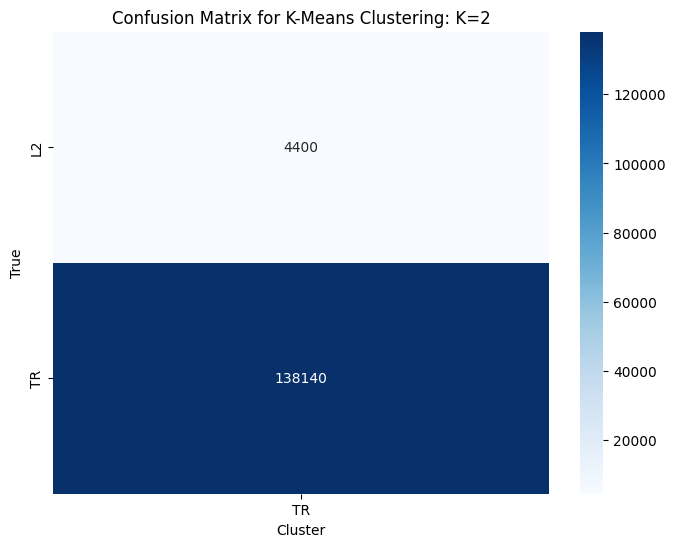

In [109]:
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Map boolean to string for readability
y_true = df['dataset_name']
y_pred = df['cluster'].values

# Map clusters to majority true label
labels = np.empty_like(y_pred, dtype=object)
for cluster in np.unique(y_pred):
    mask = (y_pred == cluster)
    unique_labels, counts = np.unique(y_true[mask], return_counts=True)
    majority_label = unique_labels[np.argmax(counts)]
    labels[mask] = majority_label

# Compute accuracy
accuracy = accuracy_score(y_true, labels)
print("Clustering Accuracy:", accuracy)

# Confusion matrix
confusion_matrix = pd.crosstab(y_true, labels, rownames=['True'], colnames=['Cluster'])
print(confusion_matrix)

# Plot confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for K-Means Clustering: K=2')
plt.show()
df = df.drop('cluster',axis = 'columns')

dataset_name
L2    4400
TR    4400
Name: count, dtype: int64
cluster
0    6560
1    2240
Name: count, dtype: int64
Clustering Accuracy: 0.5456818181818182
Cluster    L2    TR
True               
L2       3481   919
TR       3079  1321


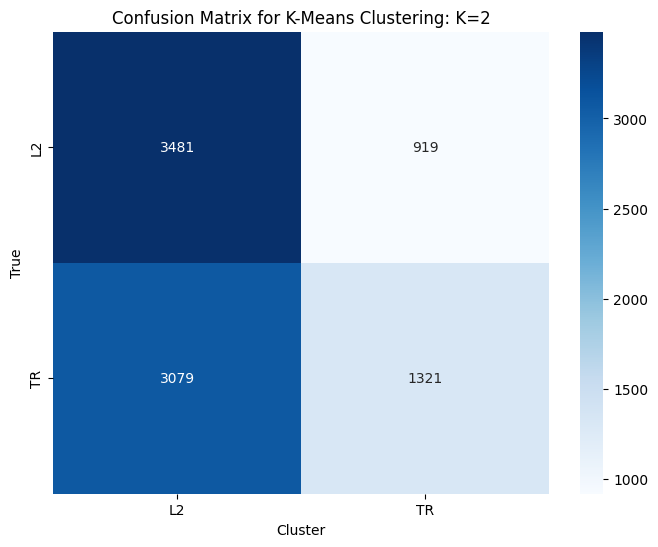

In [110]:
import pandas as pd
from sklearn.cluster import KMeans

df_L2 = df[df['dataset_name'] == 'L2']
df_TR = df[df['dataset_name'] == 'TR']

df_TR_downsampled = df_TR.sample(n=len(df_L2), random_state=42)

df_balanced = pd.concat([df_L2, df_TR_downsampled], ignore_index=True)

df_temp = df_balanced.drop(['dataset_name','L1'], axis='columns')
X = df_temp.values

kmeans = KMeans(n_clusters=2, random_state=42)
df_balanced['cluster'] = kmeans.fit_predict(X)

print(df_balanced['dataset_name'].value_counts())
print(df_balanced['cluster'].value_counts())

# Map boolean to string for readability
y_true = df_balanced['dataset_name']
y_pred = df_balanced['cluster'].values

# Map clusters to majority true label
labels = np.empty_like(y_pred, dtype=object)
for cluster in np.unique(y_pred):
    mask = (y_pred == cluster)
    unique_labels, counts = np.unique(y_true[mask], return_counts=True)
    majority_label = unique_labels[np.argmax(counts)]
    labels[mask] = majority_label

# Compute accuracy
accuracy = accuracy_score(y_true, labels)
print("Clustering Accuracy:", accuracy)

# Confusion matrix
confusion_matrix = pd.crosstab(y_true, labels, rownames=['True'], colnames=['Cluster'])
print(confusion_matrix)

# Plot confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for K-Means Clustering: K=2')
plt.show()
df_balanced = df_balanced.drop('cluster',axis = 'columns')

##K-means for 4 classes (Languages)

#Data Imbalance!

In [100]:
df = df.drop(['L1_num', 'L1_name'],axis = 'columns')
df = df.drop(['kmeans_labels'],axis = 'columns')


In [103]:
df_temp = df.drop('L1',axis = 'columns')


# mapping dictionary
l2_map = {
    "TR":1,
    "L2":0,
}
# replace L1 with mapped values
df_temp["dataset_name"] = df_temp["dataset_name"].map(l2_map)
X = df_temp.values
# Apply KMeans with k=4
kmeans = KMeans(n_clusters=4, random_state=42)
df['cluster'] = kmeans.fit_predict(X)



In [112]:
import pandas as pd

print(df['L1'].value_counts())

min_count = df['L1'].value_counts().min()
print("Smallest group size:", min_count)

df_balanced = df.groupby('L1').apply(lambda x: x.sample(n=min_count, random_state=42)).reset_index(drop=True)

print(df_balanced['L1'].value_counts())

#df_temp = df_balanced.drop(['L1','L1_name'],axis = 'columns')
df_temp = df_balanced.drop(['L1'],axis = 'columns')
# mapping dictionary
l2_map = {
    "TR":1,
    "L2":0,
}
# replace L1 with mapped values
df_temp["dataset_name"] = df_temp["dataset_name"].map(l2_map)

X = df_temp.values

# Apply KMeans with k=4
kmeans = KMeans(n_clusters=4, random_state=42)
df_balanced['cluster'] = kmeans.fit_predict(X)



L1
fr    90726
de    28843
es    19704
it     3267
Name: count, dtype: int64
Smallest group size: 3267
L1
de    3267
es    3267
fr    3267
it    3267
Name: count, dtype: int64


/tmp/ipython-input-2779876756.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_balanced = df.groupby('L1').apply(lambda x: x.sample(n=min_count, random_state=42)).reset_index(drop=True)


Clustering Accuracy: 0.3622589531680441
Predicted   de    es    fr   it
True                           
de         817   586  1814   50
es          14  1584  1335  334
fr          51  1131  1973  112
it         696  1023  1188  360


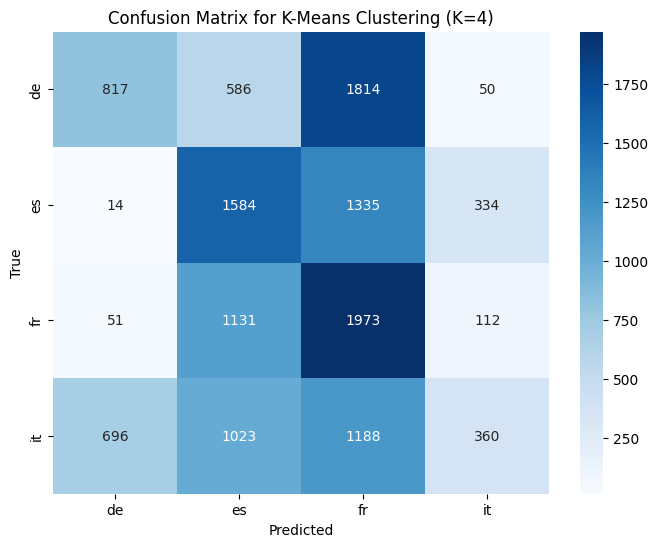

In [113]:

# True labels (as strings)
y_true = df_balanced["L1"].values
y_pred = df_balanced["cluster"].values

# Map clusters to majority true label (using string labels)
labels = np.empty_like(y_pred, dtype=object)
for cluster in np.unique(y_pred):
    mask = (y_pred == cluster)
    true_labels_in_cluster = y_true[mask]
    uniq, counts = np.unique(true_labels_in_cluster, return_counts=True)
    majority_label = uniq[np.argmax(counts)]
    labels[mask] = majority_label

# Accuracy
accuracy = accuracy_score(y_true, labels)
print("Clustering Accuracy:", accuracy)

# Confusion matrix
conf_mat = pd.crosstab(pd.Series(y_true, name='True'),
                       pd.Series(labels, name='Predicted'))
print(conf_mat)

# Plot confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for K-Means Clustering (K=4)')
plt.show()
#df = df.drop(['cluster'],axis = 'columns')

#Splitting datasets into L2 and TR

In [122]:

table = df.groupby("L1")["dataset_name"].value_counts().unstack(fill_value=0)
print(table)


dataset_name    L2     TR
L1                       
de            1100  27743
es            1100  18604
fr            1100  89626
it            1100   2167


In [134]:
import pandas as pd


df_L2 = df[df["dataset_name"] == "L2"].copy()
df_TR = df[df["dataset_name"] == "TR"].copy()


In [135]:
df_L2

,dataset_name,sentlength,ppron,possdet,indef,cconj,whconj,relativ,pied,correl,...,mdd,acl,aux,aux:pass,ccomp,nsubj:pass,parataxis,xcomp,L1,anomaly
0,L2,51.875000,0.060241,0.004819,0.002410,2.500000,0.375000,1.000000,0.0,0.0,...,2.099410,0.050000,0.491667,0.041667,0.087500,0.000000,0.112500,0.216667,es,-1
1,L2,22.769231,0.064189,0.037162,0.003378,0.538462,0.230769,0.307692,0.0,0.0,...,1.435866,0.141026,0.371795,0.019231,0.205128,0.019231,0.000000,0.089744,de,1
2,L2,21.866667,0.054878,0.006098,0.006098,0.666667,0.133333,0.266667,0.0,0.0,...,1.380520,0.013333,0.457778,0.046667,0.166667,0.013333,0.035556,0.066667,de,1
3,L2,34.916667,0.124105,0.023866,0.004773,1.750000,0.500000,0.333333,0.0,0.0,...,1.688192,0.034226,0.132143,0.043155,0.220238,0.031250,0.236409,0.135913,es,-1
4,L2,18.636364,0.039024,0.017073,0.000000,0.909091,0.000000,0.136364,0.0,0.0,...,1.286282,0.056818,0.147727,0.069697,0.060606,0.069697,0.022727,0.072727,de,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4395,L2,21.764706,0.013514,0.013514,0.002703,0.529412,0.058824,0.000000,0.0,0.0,...,1.673307,0.058824,0.460784,0.053922,0.093137,0.053922,0.056373,0.105392,de,1
4396,L2,20.619048,0.020785,0.011547,0.000000,0.619048,0.047619,0.238095,0.0,0.0,...,1.508645,0.015873,0.420408,0.120635,0.038549,0.049206,0.071429,0.141043,fr,1
4397,L2,31.333333,0.042553,0.014184,0.000000,1.000000,0.000000,0.333333,0.0,0.0,...,1.404791,0.129630,0.350000,0.000000,0.111111,0.000000,0.087037,0.211111,es,1
4398,L2,21.812500,0.028653,0.008596,0.008596,1.000000,0.000000,0.125000,0.0,0.0,...,1.651952,0.102679,0.202083,0.021429,0.073512,0.008929,0.125000,0.153869,it,1


### Without PCA (Splitting datasets into L2 and TR)

In [129]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns


def run_clustering(df, features, label_col="L1", k=4, title="Clustering"):
    # -----------------------------
    # K-means clustering
    # -----------------------------
    X = df[features].values

    # -----------------------------
    # Standardize features
    # -----------------------------
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    df["cluster"] = kmeans.fit_predict(X)

    # -----------------------------
    # True labels
    # -----------------------------
    y_true = df[label_col].values
    y_pred = df["cluster"].values

    # -----------------------------
    # Map cluster → majority true label
    # -----------------------------
    labels = np.empty_like(y_pred, dtype=object)

    for cluster in np.unique(y_pred):
        mask = (y_pred == cluster)
        unique_labels, counts = np.unique(y_true[mask], return_counts=True)
        majority_label = unique_labels[np.argmax(counts)]
        labels[mask] = majority_label

    # -----------------------------
    # Accuracy
    # -----------------------------
    accuracy = accuracy_score(y_true, labels)
    print(f"\n===== {title} =====")
    print("Accuracy:", accuracy)

    # -----------------------------
    # Confusion Matrix
    # -----------------------------
    cm = pd.crosstab(y_true, labels, rownames=["True"], colnames=["Predicted"])
    print(cm)

    # -----------------------------
    # Heatmap
    # -----------------------------
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix: {title}")
    plt.show()

    return df, accuracy, cm

features = df_L2.drop(columns=["L1", "dataset_name"]).select_dtypes(include=[np.number]).columns


####L2


===== L2 Dataset (k=4) =====
Accuracy: 0.3184090909090909
Predicted    de   es
True                
de         1010   90
es          709  391
fr          923  177
it          767  333


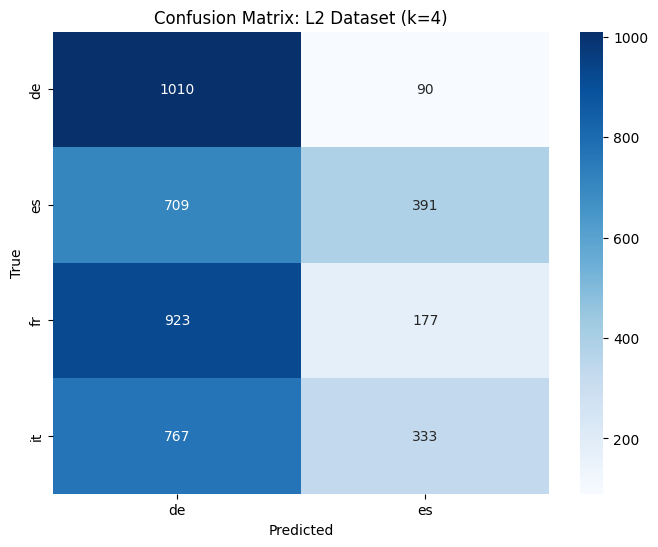

In [130]:

df_L2, acc_L2, cm_L2 = run_clustering(
    df_L2,
    features=features,
    label_col="L1",
    k=4,
    title="L2 Dataset (k=4)"
)


####TR

In [133]:
df_TR

,dataset_name,sentlength,ppron,possdet,indef,cconj,whconj,relativ,pied,correl,...,acl,aux,aux:pass,ccomp,nsubj:pass,parataxis,xcomp,L1,anomaly,cluster
4400,TR,19.900000,0.010050,0.000000,0.0,0.700000,0.000000,0.200000,0.0,0.0,...,0.000000,0.150000,0.300000,0.0,0.300000,0.000000,0.050000,NaN,1,3
4401,TR,19.571429,0.000000,0.000000,0.0,1.142857,0.000000,0.000000,0.0,0.0,...,0.000000,0.000000,0.309524,0.0,0.309524,0.000000,0.095238,NaN,1,3
4402,TR,28.181818,0.000000,0.000000,0.0,0.818182,0.000000,0.000000,0.0,0.0,...,0.136364,0.075758,0.151515,0.0,0.181818,0.000000,0.000000,NaN,1,3
4403,TR,23.733333,0.002809,0.002809,0.0,1.000000,0.000000,0.133333,0.0,0.0,...,0.138889,0.000000,0.305556,0.0,0.238889,0.000000,0.050000,NaN,1,3
4404,TR,25.400000,0.005249,0.000000,0.0,1.000000,0.066667,0.000000,0.0,0.0,...,0.100000,0.133333,0.117460,0.0,0.126984,0.066667,0.055556,NaN,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142535,TR,7.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,NaN,1,1
142536,TR,5.500000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,NaN,1,2
142537,TR,14.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,NaN,1,1
142538,TR,39.000000,0.000000,0.025641,0.0,0.500000,0.000000,1.000000,0.0,0.0,...,0.875000,0.125000,0.000000,0.0,0.000000,0.000000,0.000000,NaN,1,0



===== TR Dataset (k=4) =====
Accuracy: 0.6841392789923266
Predicted    de     fr
True                  
de         4889  22854
es            2  18602
fr            8  89618
it          537   1630


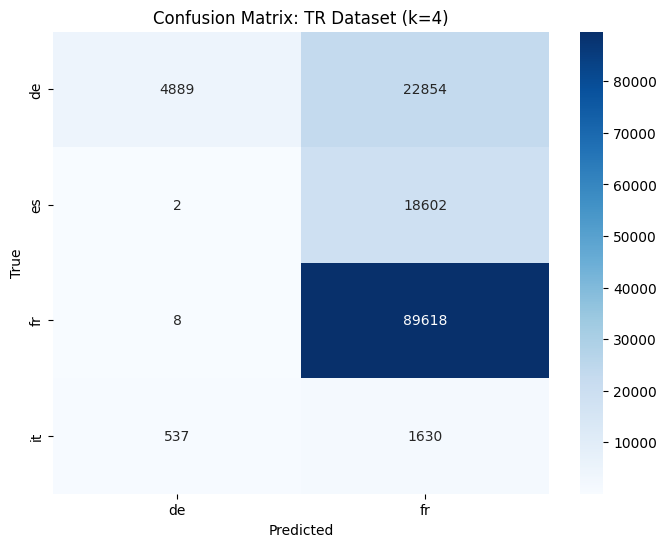

In [136]:
features_tr = df_TR.drop(columns=["L1", "dataset_name"]).select_dtypes(include=[np.number]).columns


df_TR, acc_TR, cm_TR = run_clustering(
    df_TR,
    features=features_tr,
    label_col="L1",
    k=4,
    title="TR Dataset (k=4)"
)


### With PCA (Splitting datasets into L2 and TR)

In [139]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

random_state = 42

def clustering_with_pca_analysis(df, label_col="L1", k=4, title="Dataset"):
    # -----------------------------
    # Features
    # -----------------------------
    features = df.drop(columns=[label_col, "dataset_name"]).select_dtypes(include=[np.number]).columns
    X = df[features].values

    # -----------------------------
    # Standardize features
    # -----------------------------
    scaler = StandardScaler()
    X_s = scaler.fit_transform(X)

    # -----------------------------
    # PCA (retain 95% variance)
    # -----------------------------
    pca = PCA(n_components=0.95, random_state=random_state)
    X_pca = pca.fit_transform(X_s)
    print(f"\n{title} PCA retained variance:", pca.explained_variance_ratio_.sum())
    print(f"{title} PCA components shape:", X_pca.shape)

    # -----------------------------
    # K-means clustering
    # -----------------------------
    kmeans = KMeans(n_clusters=k, random_state=random_state, n_init=10)
    df["cluster"] = kmeans.fit_predict(X_pca)

    # -----------------------------
    # Map cluster → majority label
    # -----------------------------
    y_true = df[label_col].values
    y_pred = df["cluster"].values
    labels = np.empty_like(y_pred, dtype=object)

    for cluster in np.unique(y_pred):
        mask = (y_pred == cluster)
        unique_labels, counts = np.unique(y_true[mask], return_counts=True)
        majority_label = unique_labels[np.argmax(counts)]
        labels[mask] = majority_label

    # -----------------------------
    # Accuracy
    # -----------------------------
    accuracy = accuracy_score(y_true, labels)
    print(f"{title} Clustering Accuracy:", accuracy)

    # -----------------------------
    # Confusion matrix
    # -----------------------------
    cm = pd.crosstab(y_true, labels, rownames=["True"], colnames=["Predicted"])
    print(cm)

    # -----------------------------
    # Heatmap
    # -----------------------------
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix: {title}")
    plt.show()

    return df, accuracy, cm, X_pca


#### L2


L2 Dataset PCA retained variance: 0.9512811539312468
L2 Dataset PCA components shape: (4400, 33)
L2 Dataset Clustering Accuracy: 0.31613636363636366
Predicted   de   es   fr
True                    
de         368   77  655
es         249  367  484
fr         298  146  656
it         298  315  487


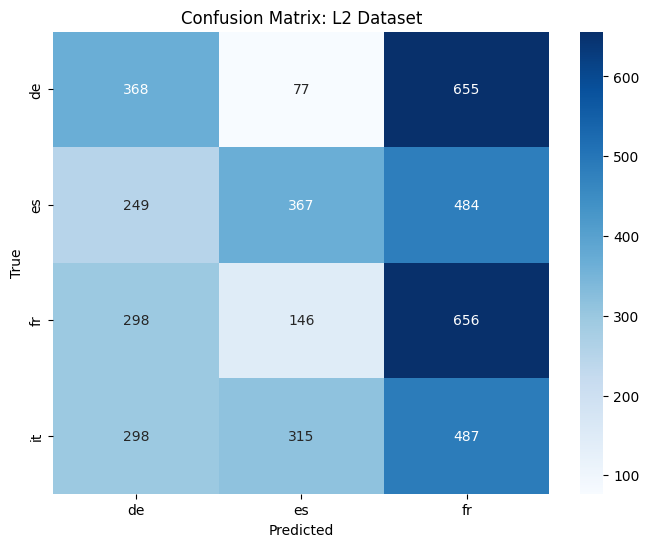

In [140]:
df_L2, acc_L2, cm_L2, X_L2_pca = clustering_with_pca_analysis(df_L2, label_col="L1", k=4, title="L2 Dataset")
#IN L2 WITHOUT PCA ITS EXACT SAME RESULT!

####TR


TR Dataset PCA retained variance: 0.9567446476124483
TR Dataset PCA components shape: (138140, 34)
TR Dataset Clustering Accuracy: 0.6841392789923266
Predicted    de     fr
True                  
de         4889  22854
es            2  18602
fr            8  89618
it          537   1630


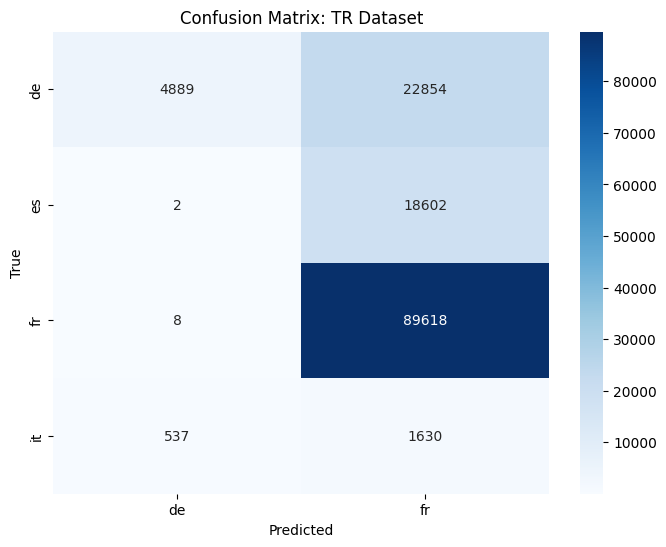

In [141]:
df_TR, acc_TR, cm_TR, X_TR_pca = clustering_with_pca_analysis(df_TR, label_col="L1", k=4, title="TR Dataset")


#### TR with balanced data (PCA)


```
OLD
dataset    L2    TR
L1                 
de       1100   926
es       1100   615
fr       1100  2888
it       1100    79

NEW!!
dataset_name    L2     TR
L1                       
de            1100  27743
es            1100  18604
fr            1100  89626
it            1100   2167
```




L1
de    2167
es    2167
fr    2167
it    2167
Name: count, dtype: int64

TR Dataset (Balanced, k=4, PCA) PCA retained variance: 0.9554453263443431
TR Dataset (Balanced, k=4, PCA) PCA components shape: (8668, 33)
TR Dataset (Balanced, k=4, PCA) Clustering Accuracy: 0.3710198431010614
Predicted   de   es   fr   it
True                         
de         936  197  639  395
es         771  795  600    1
fr         824  394  948    1
it         302  667  661  537


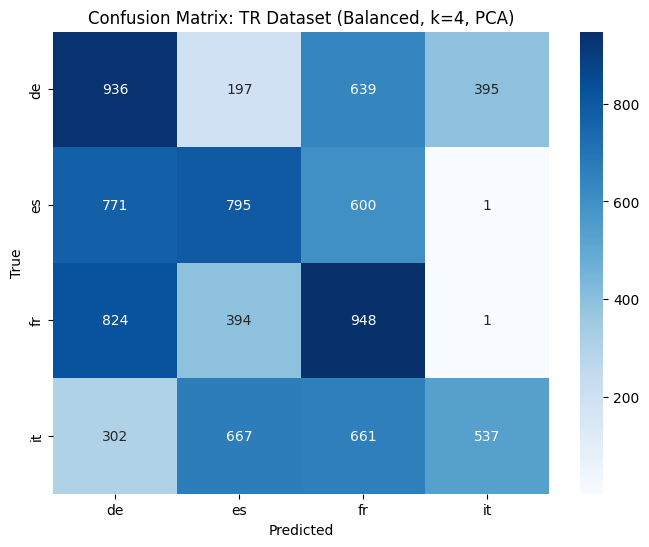

In [142]:
# Number of samples per class
n_samples = 2167

# Sample 2167 rows from each L1 class
df_TR_balanced = df_TR.groupby("L1").sample(n=n_samples, random_state=42)

# Check the new class counts
print(df_TR_balanced["L1"].value_counts())

df_TR_balanced, acc_TR, cm_TR, X_TR_pca = clustering_with_pca_analysis(
    df_TR_balanced,
    label_col="L1",
    k=4,
    title="TR Dataset (Balanced, k=4, PCA)"
)


In [143]:
df_L2

,dataset_name,sentlength,ppron,possdet,indef,cconj,whconj,relativ,pied,correl,...,acl,aux,aux:pass,ccomp,nsubj:pass,parataxis,xcomp,L1,anomaly,cluster
0,L2,51.875000,0.060241,0.004819,0.002410,2.500000,0.375000,1.000000,0.0,0.0,...,0.050000,0.491667,0.041667,0.087500,0.000000,0.112500,0.216667,es,-1,3
1,L2,22.769231,0.064189,0.037162,0.003378,0.538462,0.230769,0.307692,0.0,0.0,...,0.141026,0.371795,0.019231,0.205128,0.019231,0.000000,0.089744,de,1,0
2,L2,21.866667,0.054878,0.006098,0.006098,0.666667,0.133333,0.266667,0.0,0.0,...,0.013333,0.457778,0.046667,0.166667,0.013333,0.035556,0.066667,de,1,0
3,L2,34.916667,0.124105,0.023866,0.004773,1.750000,0.500000,0.333333,0.0,0.0,...,0.034226,0.132143,0.043155,0.220238,0.031250,0.236409,0.135913,es,-1,3
4,L2,18.636364,0.039024,0.017073,0.000000,0.909091,0.000000,0.136364,0.0,0.0,...,0.056818,0.147727,0.069697,0.060606,0.069697,0.022727,0.072727,de,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4395,L2,21.764706,0.013514,0.013514,0.002703,0.529412,0.058824,0.000000,0.0,0.0,...,0.058824,0.460784,0.053922,0.093137,0.053922,0.056373,0.105392,de,1,2
4396,L2,20.619048,0.020785,0.011547,0.000000,0.619048,0.047619,0.238095,0.0,0.0,...,0.015873,0.420408,0.120635,0.038549,0.049206,0.071429,0.141043,fr,1,2
4397,L2,31.333333,0.042553,0.014184,0.000000,1.000000,0.000000,0.333333,0.0,0.0,...,0.129630,0.350000,0.000000,0.111111,0.000000,0.087037,0.211111,es,1,0
4398,L2,21.812500,0.028653,0.008596,0.008596,1.000000,0.000000,0.125000,0.0,0.0,...,0.102679,0.202083,0.021429,0.073512,0.008929,0.125000,0.153869,it,1,0


### Splitting data - NN



===== MLP Classification L2 =====
Test Accuracy: 0.4727272727272727

Confusion matrix:
[[126  28  36  30]
 [ 43  97  21  59]
 [ 49  36  81  54]
 [ 30  44  34 112]]


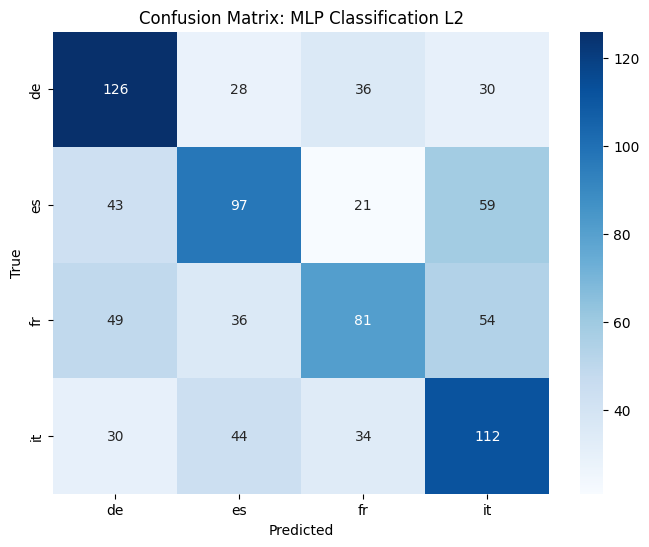

In [144]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

def run_nn(df, features, label_col="L1", title="Neural Network"):
    # -----------------------------
    # Prepare data
    # -----------------------------
    X = df[features].values
    y = df[label_col].values

    # -----------------------------
    # Label encode if needed
    # -----------------------------
    if y.dtype.kind in {'O', 'U', 'S'}:  # string/object
        le = LabelEncoder()
        y = le.fit_transform(y)

    # -----------------------------
    # Train-test split
    # -----------------------------
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # -----------------------------
    # Scale features
    # -----------------------------
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    # -----------------------------
    # Neural network
    # -----------------------------
    mlp = MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        solver='adam',
        max_iter=200,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42
    )
    mlp.fit(X_train_s, y_train)

    # -----------------------------
    # Predict on test set
    # -----------------------------
    y_pred = mlp.predict(X_test_s)

    # -----------------------------
    # Accuracy
    # -----------------------------
    accuracy = accuracy_score(y_test, y_pred)
    print(f"\n===== {title} =====")
    print("Test Accuracy:", accuracy)

    # -----------------------------
    # Confusion Matrix
    # -----------------------------
        # -----------------------------
    # Confusion Matrix with labels
    # -----------------------------
    cm = confusion_matrix(y_test, y_pred)

    # Map integer labels → language strings
    label_map = {0: "de", 1: "es", 2: "fr", 3: "it"}

    # The LabelEncoder may re-order classes, so use le.classes_
    # and convert them back to original coded labels
    classes = le.classes_                    # e.g. ["de","es","fr","it"]
    classes_int = le.transform(classes)      # e.g. [0,1,2,3]
    classes_str = [label_map[i] for i in classes_int]

    print("\nConfusion matrix:")
    print(cm)

    plt.figure(figsize=(8,6))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=classes_str,
        yticklabels=classes_str
    )
    plt.title(f"Confusion Matrix: {title}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()


    return mlp, accuracy, cm

# Example usage:
features = df_L2.drop(columns=["L1", "dataset_name"]).select_dtypes(include=[np.number]).columns
mlp_model, acc, cm = run_nn(df_L2, features, label_col="L1", title="MLP Classification L2")



===== MLP Classification TR =====
Test Accuracy: 0.7905023888808456

Confusion matrix:
[[ 3707   373  1458    11]
 [  399  1420  1887    15]
 [  604   628 16683    10]
 [  193    65   145    30]]


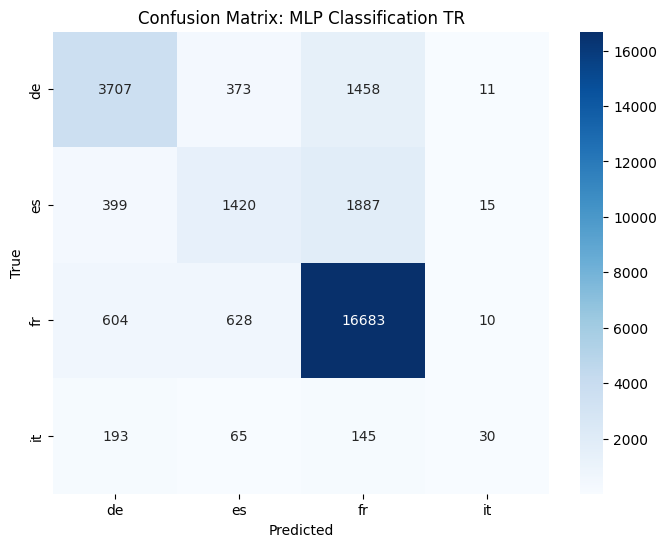

In [145]:

features_tr = df_TR.drop(columns=["L1", "dataset_name"]).select_dtypes(include=[np.number]).columns
mlp_model, acc, cm = run_nn(df_TR, features_tr, label_col="L1", title="MLP Classification TR")

### TR with Balanced data


===== MLP Classification TR =====
Test Accuracy: 0.6199538638985006

Confusion matrix:
[[201  66  45 122]
 [ 54 272  76  31]
 [ 46  69 286  33]
 [ 42  51  24 316]]


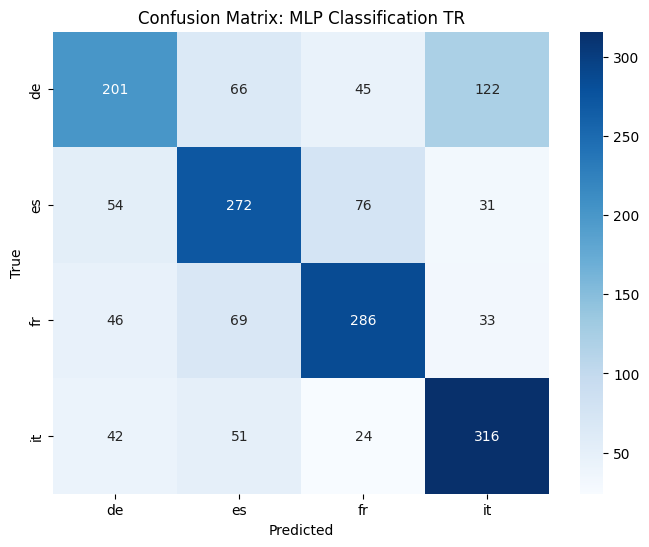

In [147]:

features_tr = df_TR_balanced.drop(columns=["L1", "dataset_name"]).select_dtypes(include=[np.number]).columns
mlp_model, acc, cm = run_nn(df_TR_balanced, features_tr, label_col="L1", title="MLP Classification TR")

## Kmeans with PCA

In [ ]:
l2_map = {"TR":1, "L2":0}
df["dataset_name"] = df["dataset_name"].map(l2_map)


In [156]:
n_samples = 3267 #(1100 from L2, 2167 from TR - lowest value avaiable)

# Sample 2167 rows from each L1 class
df_balanced = df.groupby("L1").sample(n=n_samples, random_state=42)


to_drop = [c for c in ['L1','cluster','kmeans_labels'] if c in df_balanced.columns]
feature_cols = [c for c in df_balanced.columns if c not in to_drop]


X = df_balanced[feature_cols].values
y = df_balanced['L1'].values


scaler = StandardScaler()
X_s = scaler.fit_transform(X)


In [157]:
df_balanced

,dataset_name,sentlength,ppron,possdet,indef,cconj,whconj,relativ,pied,correl,...,mdd,acl,aux,aux:pass,ccomp,nsubj:pass,parataxis,xcomp,L1,anomaly
9804,1,22.928571,0.000000,0.003115,0.0,0.857143,0.000000,0.071429,0.000000,0.0,...,1.528169,0.023810,0.071429,0.184524,0.000000,0.220238,0.000000,0.000000,de,1
21491,1,22.230538,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,...,0.000000,0.124581,0.098514,0.129547,0.027490,0.117948,0.018531,0.057606,de,1
12265,1,36.692308,0.004193,0.014675,0.0,2.384615,0.000000,0.153846,0.000000,0.0,...,1.920791,0.207692,0.000000,0.133333,0.156410,0.117949,0.038462,0.115385,de,1
5976,1,20.500000,0.003484,0.000000,0.0,1.142857,0.000000,0.071429,0.000000,0.0,...,1.799930,0.047619,0.085884,0.274660,0.000000,0.282313,0.000000,0.095238,de,1
16264,1,10.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,...,1.125000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,de,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142326,1,26.142857,0.005464,0.000000,0.0,0.571429,0.142857,0.285714,0.000000,0.0,...,1.429625,0.071429,0.071429,0.142857,0.000000,0.107143,0.142857,0.178571,it,1
140746,1,34.785714,0.014374,0.004107,0.0,0.428571,0.000000,0.500000,0.142857,0.0,...,1.691200,0.178571,0.300000,0.050000,0.067857,0.050000,0.053571,0.085714,it,1
141084,1,10.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,it,1
2301,0,25.083333,0.043189,0.013289,0.0,1.333333,0.083333,0.666667,0.083333,0.0,...,1.845675,0.194444,0.319444,0.125000,0.020833,0.055556,0.041667,0.159722,it,-1


PCA variance retained: 0.9509709212421624

Cluster → Majority Label Mapping:
{np.int32(0): 'es', np.int32(1): 'fr', np.int32(2): 'de', np.int32(3): 'it'}

Overall accuracy (same data used for clustering): 0.40633608815426997

Classification Report:
              precision    recall  f1-score   support

          de     0.5162    0.1760    0.2625      3267
          es     0.3896    0.4365    0.4117      3267
          fr     0.3210    0.6746    0.4350      3267
          it     0.7738    0.3382    0.4707      3267

    accuracy                         0.4063     13068
   macro avg     0.5001    0.4063    0.3950     13068
weighted avg     0.5001    0.4063    0.3950     13068



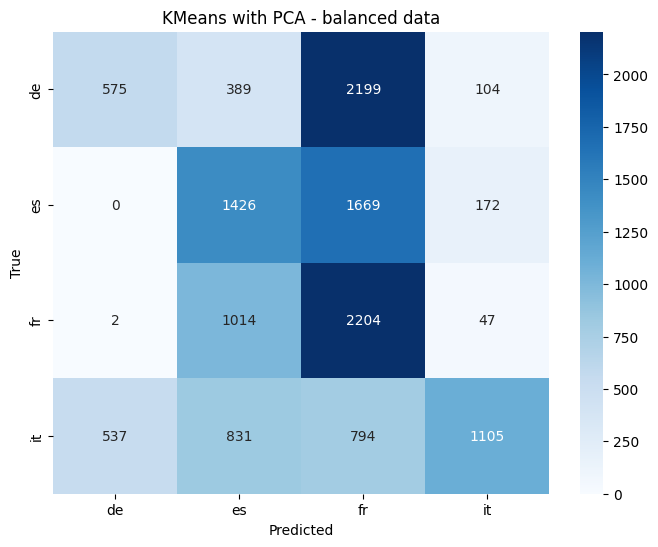


TP and FP per class:

      TP    FP
de   575   539
es  1426  2234
fr  2204  4662
it  1105   323


In [159]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# PCA
pca = PCA(n_components=0.95) #variance high keep only those features
X_p = pca.fit_transform(X_s)
print("PCA variance retained:", pca.explained_variance_ratio_.sum())

# KMeans on full PCA-transformed dataset
k = len(np.unique(y))
kmeans = KMeans(n_clusters=k, random_state=random_state, n_init=20)
clusters = kmeans.fit_predict(X_p)

# Majority voting: cluster -> class label
cluster_to_label = {}
for cl in np.unique(clusters):
    mask = (clusters == cl)
    true_labels = y[mask]
    uniq, counts = np.unique(true_labels, return_counts=True)
    cluster_to_label[cl] = uniq[np.argmax(counts)]

print("\nCluster → Majority Label Mapping:")
print(cluster_to_label)

# Map clusters to predicted labels
y_pred = np.array([cluster_to_label[c] for c in clusters])

# 8) Evaluation
acc = np.mean(y_pred == y)
print("\nOverall accuracy (same data used for clustering):", acc)
print("\nClassification Report:")
print(classification_report(y, y_pred, digits=4))

# Confusion Matrix
labels_order = np.unique(y)
conf_mat = pd.crosstab(pd.Series(y, name='True'),
                       pd.Series(y_pred, name='Predicted'))
conf_mat = conf_mat.reindex(index=labels_order,
                            columns=labels_order, fill_value=0)

plt.figure(figsize=(8,6))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
plt.title('KMeans with PCA - balanced data')
plt.show()

# TP / FP per class
tp_fp_df = pd.DataFrame(index=labels_order, columns=['TP','FP'])
for cls in labels_order:
    tp = conf_mat.loc[cls, cls]
    fp = conf_mat.loc[:, cls].sum() - tp
    tp_fp_df.loc[cls] = [int(tp), int(fp)]

print("\nTP and FP per class:\n")
print(tp_fp_df)


### TOP 10 features - balanced dataset

/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [15] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Top 10 features used for clustering: ['dataset_name' 'sentlength' 'ppron' 'pasttense' 'lexdens' 'numcls'
 'nnargs' 'mhd' 'aux:pass' 'nsubj:pass']

========== KMeans ==========

Cluster → Majority Label Mapping:
  Cluster 0 → de
  Cluster 1 → es
  Cluster 2 → it
  Cluster 3 → fr

Classification Report:
              precision    recall  f1-score   support

          de     0.5158    0.1800    0.2668      3267
          es     0.3076    0.4506    0.3656      3267
          fr     0.3241    0.5672    0.4125      3267
          it     0.7749    0.3382    0.4709      3267

    accuracy                         0.3840     13068
   macro avg     0.4806    0.3840    0.3790     13068
weighted avg     0.4806    0.3840    0.3790     13068



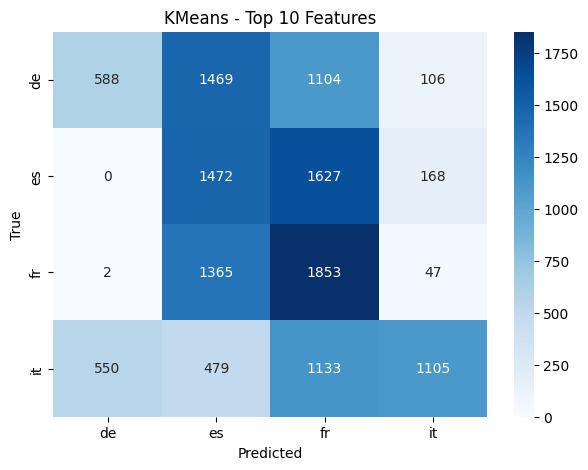


TP and FP per class:
       TP    FP
de   588   552
es  1472  3313
fr  1853  3864
it  1105   321

========== GMM ==========

Cluster → Majority Label Mapping:
  Cluster 0 → fr
  Cluster 1 → es
  Cluster 2 → de
  Cluster 3 → it

Classification Report:
              precision    recall  f1-score   support

          de     0.5158    0.1748    0.2611      3267
          es     0.3652    0.4530    0.4044      3267
          fr     0.3337    0.6636    0.4441      3267
          it     0.7790    0.3367    0.4702      3267

    accuracy                         0.4070     13068
   macro avg     0.4984    0.4070    0.3949     13068
weighted avg     0.4984    0.4070    0.3949     13068



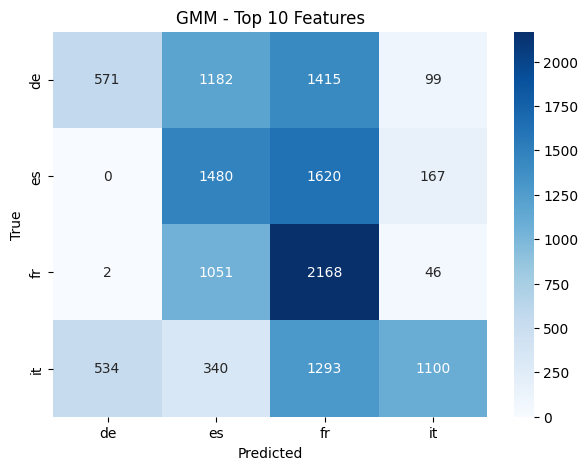


TP and FP per class:
       TP    FP
de   571   536
es  1480  2573
fr  2168  4328
it  1100   312


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(



========== Spectral Clustering ==========

Cluster → Majority Label Mapping:
  Cluster 0 → de
  Cluster 1 → es
  Cluster 2 → it
  Cluster 3 → it

Classification Report:
              precision    recall  f1-score   support

          de     0.5211    0.0530    0.0961      3267
          es     0.2622    1.0000    0.4155      3267
          fr     0.0000    0.0000    0.0000      3267
          it     0.5254    0.0444    0.0819      3267

    accuracy                         0.2743     13068
   macro avg     0.3272    0.2743    0.1484     13068
weighted avg     0.3272    0.2743    0.1484     13068



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


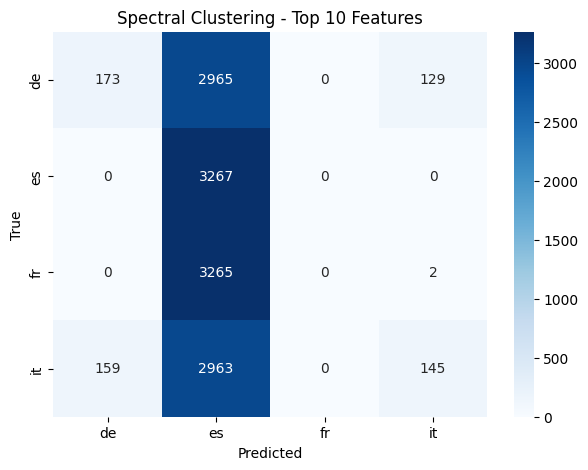


TP and FP per class:
       TP    FP
de   173   159
es  3267  9193
fr     0     0
it   145   131


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



========== HDBSCAN ==========

Cluster → Majority Label Mapping:
  Cluster -1 → it
  Cluster 0 → it
  Cluster 1 → it
  Cluster 2 → it
  Cluster 3 → it
  Cluster 4 → it
  Cluster 5 → de
  Cluster 6 → it
  Cluster 7 → de
  Cluster 8 → de
  Cluster 9 → de
  Cluster 10 → it
  Cluster 11 → de
  Cluster 12 → fr
  Cluster 13 → de

Classification Report:
              precision    recall  f1-score   support

          de     0.5707    0.1062    0.1791      3267
          es     0.0000    0.0000    0.0000      3267
          fr     0.3188    0.9770    0.4808      3267
          it     0.6664    0.4995    0.5710      3267

    accuracy                         0.3957     13068
   macro avg     0.3890    0.3957    0.3077     13068
weighted avg     0.3890    0.3957    0.3077     13068



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


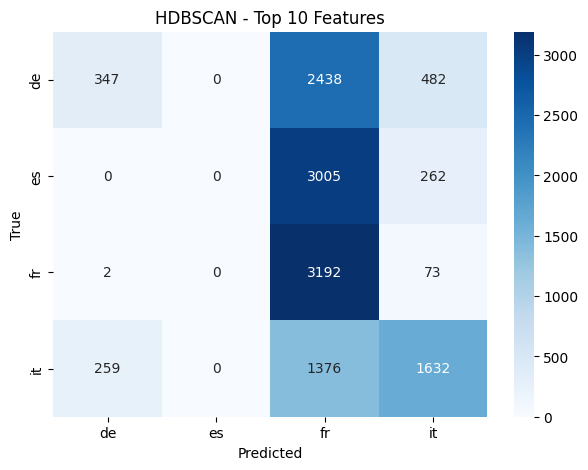


TP and FP per class:
       TP    FP
de   347   261
es     0     0
fr  3192  6819
it  1632   817


Predicted,de,es,fr,it
True,,,,
de,347,0,2438,482
es,0,0,3005,262
fr,2,0,3192,73
it,259,0,1376,1632


In [161]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.mixture import GaussianMixture
import hdbscan
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------
# 0) Utility: evaluate clustering
# ------------------------------
def evaluate_clustering(y_true, clusters, method_name):
    labels = np.unique(y_true)
    # Map cluster -> majority label
    cluster_to_label = {}
    for c in np.unique(clusters):
        idx = np.where(clusters == c)[0]
        assigned_true = y_true[idx]
        if len(assigned_true) == 0:
            cluster_to_label[c] = labels[0]
        else:
            uniq, counts = np.unique(assigned_true, return_counts=True)
            cluster_to_label[c] = uniq[np.argmax(counts)]
    # Map clusters -> predicted labels
    y_pred = np.array([cluster_to_label[c] for c in clusters])
    # Confusion matrix
    conf_mat = pd.crosstab(pd.Series(y_true, name="True"),
                           pd.Series(y_pred, name="Predicted"))
    conf_mat = conf_mat.reindex(index=labels, columns=labels, fill_value=0)
    # Print results
    print(f"\n========== {method_name} ==========")
    print("\nCluster → Majority Label Mapping:")
    for c, lab in cluster_to_label.items():
        print(f"  Cluster {c} → {lab}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, digits=4))
    # Plot confusion matrix
    plt.figure(figsize=(7,5))
    sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{method_name} - Top 10 Features")
    plt.show()
    # TP / FP per class
    tp_fp_df = pd.DataFrame(index=labels, columns=['TP','FP'])
    for cls in labels:
        tp = conf_mat.loc[cls, cls]
        fp = conf_mat.loc[:, cls].sum() - tp
        tp_fp_df.loc[cls] = [int(tp), int(fp)]
    print("\nTP and FP per class:\n", tp_fp_df)
    return conf_mat

# ------------------------------
# 1) Scale full dataset
# ------------------------------
scaler = StandardScaler()
X_s = scaler.fit_transform(df_balanced[feature_cols].values)
y_balanced = df_balanced['L1'].values

# ------------------------------
# 2) Select Top 10 features (ANOVA F-test)
# ------------------------------
selector = SelectKBest(f_classif, k=10)
X_top10 = selector.fit_transform(X_s, y_balanced)
top_features = np.array(feature_cols)[selector.get_support()]
print("Top 10 features used for clustering:", top_features)

# ------------------------------
# 3) KMeans
# ------------------------------
k = len(np.unique(y_balanced))
kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
clusters_km = kmeans.fit_predict(X_top10)
evaluate_clustering(y_balanced, clusters_km, "KMeans")

# ------------------------------
# 4) Gaussian Mixture Model (GMM)
# ------------------------------
gmm = GaussianMixture(n_components=k, covariance_type="full", random_state=42)
clusters_gmm = gmm.fit_predict(X_top10)
evaluate_clustering(y_balanced, clusters_gmm, "GMM")

# ------------------------------
# 5) Spectral Clustering
# ------------------------------
spectral = SpectralClustering(n_clusters=k, affinity='nearest_neighbors', random_state=42)
clusters_spectral = spectral.fit_predict(X_top10)
evaluate_clustering(y_balanced, clusters_spectral, "Spectral Clustering")

# ------------------------------
# 6) HDBSCAN Clustering
# ------------------------------
clusterer = hdbscan.HDBSCAN(min_cluster_size=50, metric='euclidean', cluster_selection_method='eom')
clusters_hdb = clusterer.fit_predict(X_top10)
evaluate_clustering(y_balanced, clusters_hdb, "HDBSCAN")


### Top 20 features Balanced Dataset

/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [15] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Top 20 features used for clustering: ['dataset_name' 'sentlength' 'ppron' 'cconj' 'relativ' 'copula' 'attrib'
 'pasttense' 'lexdens' 'lexTTR' 'pverbals' 'longpassives' 'epist' 'numcls'
 'nnargs' 'mhd' 'mdd' 'aux:pass' 'nsubj:pass' 'anomaly']

========== KMeans ==========

Cluster → Majority Label Mapping:
  Cluster 0 → es
  Cluster 1 → fr
  Cluster 2 → it
  Cluster 3 → de

Classification Report:
              precision    recall  f1-score   support

          de     0.5157    0.1757    0.2621      3267
          es     0.3301    0.4998    0.3976      3267
          fr     0.3372    0.5745    0.4249      3267
          it     0.7800    0.3440    0.4775      3267

    accuracy                         0.3985     13068
   macro avg     0.4908    0.3985    0.3905     13068
weighted avg     0.4908    0.3985    0.3905     13068



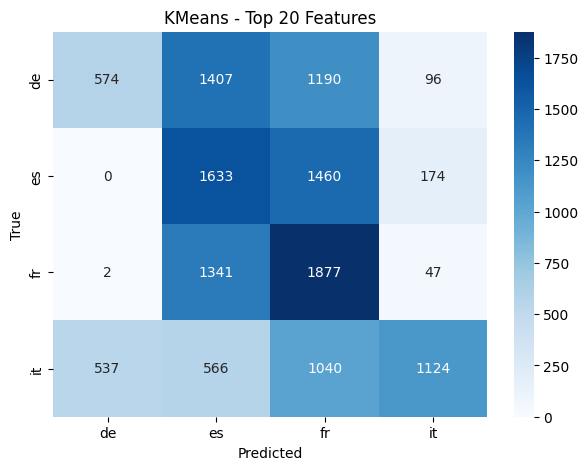


TP and FP per class:
       TP    FP
de   574   539
es  1633  3314
fr  1877  3690
it  1124   317

========== GMM ==========

Cluster → Majority Label Mapping:
  Cluster 0 → it
  Cluster 1 → fr
  Cluster 2 → de
  Cluster 3 → it

Classification Report:
              precision    recall  f1-score   support

          de     0.5158    0.1748    0.2611      3267
          es     0.0000    0.0000    0.0000      3267
          fr     0.3265    0.9721    0.4888      3267
          it     0.6907    0.4723    0.5610      3267

    accuracy                         0.4048     13068
   macro avg     0.3833    0.4048    0.3277     13068
weighted avg     0.3833    0.4048    0.3277     13068



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


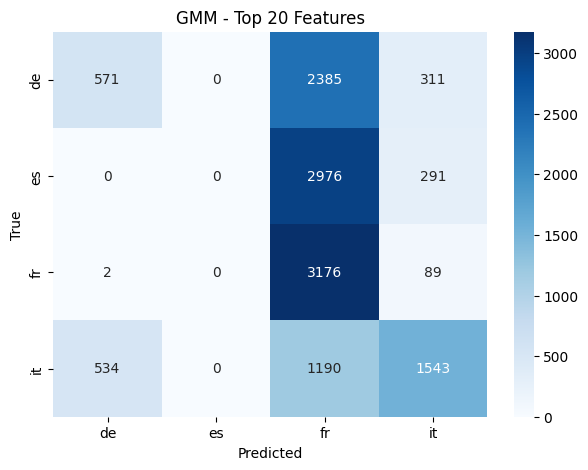


TP and FP per class:
       TP    FP
de   571   536
es     0     0
fr  3176  6551
it  1543   691


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(



========== Spectral Clustering ==========

Cluster → Majority Label Mapping:
  Cluster 0 → de
  Cluster 1 → es
  Cluster 2 → it
  Cluster 3 → it

Classification Report:
              precision    recall  f1-score   support

          de     0.5105    0.0447    0.0822      3267
          es     0.2573    1.0000    0.4093      3267
          fr     0.0000    0.0000    0.0000      3267
          it     0.5529    0.0144    0.0280      3267

    accuracy                         0.2648     13068
   macro avg     0.3302    0.2648    0.1299     13068
weighted avg     0.3302    0.2648    0.1299     13068



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


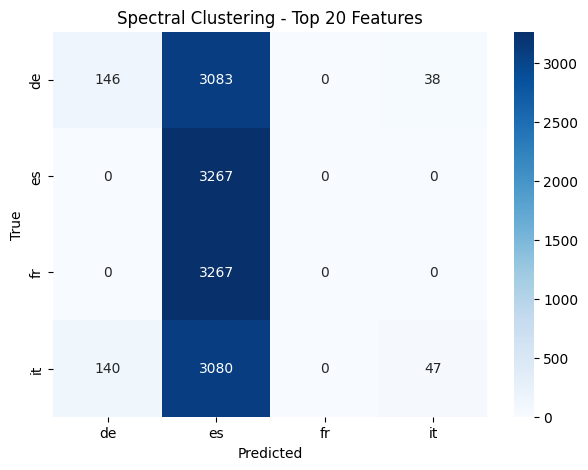


TP and FP per class:
       TP    FP
de   146   140
es  3267  9430
fr     0     0
it    47    38


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



========== HDBSCAN ==========

Cluster → Majority Label Mapping:
  Cluster -1 → it
  Cluster 0 → it
  Cluster 1 → it
  Cluster 2 → it
  Cluster 3 → it
  Cluster 4 → it
  Cluster 5 → de
  Cluster 6 → it
  Cluster 7 → de
  Cluster 8 → it
  Cluster 9 → de
  Cluster 10 → de
  Cluster 11 → de
  Cluster 12 → it
  Cluster 13 → de
  Cluster 14 → fr

Classification Report:
              precision    recall  f1-score   support

          de     0.5779    0.0943    0.1621      3267
          es     0.0000    0.0000    0.0000      3267
          fr     0.3422    0.9167    0.4983      3267
          it     0.5849    0.6771    0.6276      3267

    accuracy                         0.4220     13068
   macro avg     0.3762    0.4220    0.3220     13068
weighted avg     0.3762    0.4220    0.3220     13068



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


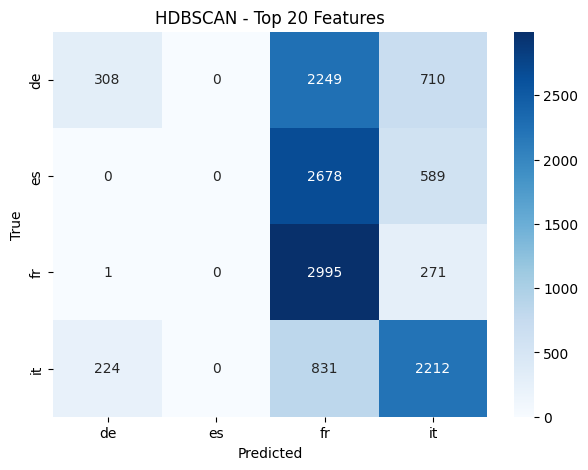


TP and FP per class:
       TP    FP
de   308   225
es     0     0
fr  2995  5758
it  2212  1570


Predicted,de,es,fr,it
True,,,,
de,308,0,2249,710
es,0,0,2678,589
fr,1,0,2995,271
it,224,0,831,2212


In [163]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.mixture import GaussianMixture
import hdbscan
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------
# 0) Utility: evaluate clustering
# ------------------------------
def evaluate_clustering(y_true, clusters, method_name):
    labels = np.unique(y_true)
    # Map cluster -> majority label
    cluster_to_label = {}
    for c in np.unique(clusters):
        idx = np.where(clusters == c)[0]
        assigned_true = y_true[idx]
        if len(assigned_true) == 0:
            cluster_to_label[c] = labels[0]
        else:
            uniq, counts = np.unique(assigned_true, return_counts=True)
            cluster_to_label[c] = uniq[np.argmax(counts)]
    # Map clusters -> predicted labels
    y_pred = np.array([cluster_to_label[c] for c in clusters])
    # Confusion matrix
    conf_mat = pd.crosstab(pd.Series(y_true, name="True"),
                           pd.Series(y_pred, name="Predicted"))
    conf_mat = conf_mat.reindex(index=labels, columns=labels, fill_value=0)
    # Print results
    print(f"\n========== {method_name} ==========")
    print("\nCluster → Majority Label Mapping:")
    for c, lab in cluster_to_label.items():
        print(f"  Cluster {c} → {lab}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, digits=4))
    # Plot confusion matrix
    plt.figure(figsize=(7,5))
    sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{method_name} - Top 20 Features")
    plt.show()
    # TP / FP per class
    tp_fp_df = pd.DataFrame(index=labels, columns=['TP','FP'])
    for cls in labels:
        tp = conf_mat.loc[cls, cls]
        fp = conf_mat.loc[:, cls].sum() - tp
        tp_fp_df.loc[cls] = [int(tp), int(fp)]
    print("\nTP and FP per class:\n", tp_fp_df)
    return conf_mat

# ------------------------------
# 1) Scale full dataset
# ------------------------------
scaler = StandardScaler()
X_s = scaler.fit_transform(df_balanced[feature_cols].values)
y_balanced = df_balanced['L1'].values


# ------------------------------
# 2) Select Top 20 features (ANOVA F-test)
# ------------------------------
selector = SelectKBest(f_classif, k=20)
X_top20 = selector.fit_transform(X_s, y_balanced)
top_features = np.array(feature_cols)[selector.get_support()]
print("Top 20 features used for clustering:", top_features)

# ------------------------------
# 3) KMeans
# ------------------------------
k = len(np.unique(y_balanced))
kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
clusters_km = kmeans.fit_predict(X_top20)
evaluate_clustering(y_balanced, clusters_km, "KMeans")

# ------------------------------
# 4) Gaussian Mixture Model (GMM)
# ------------------------------
gmm = GaussianMixture(n_components=k, covariance_type="full", random_state=42)
clusters_gmm = gmm.fit_predict(X_top20)
evaluate_clustering(y_balanced, clusters_gmm, "GMM")

# ------------------------------
# 5) Spectral Clustering
# ------------------------------
spectral = SpectralClustering(n_clusters=k, affinity='nearest_neighbors', random_state=42)
clusters_spectral = spectral.fit_predict(X_top20)
evaluate_clustering(y_balanced, clusters_spectral, "Spectral Clustering")

# ------------------------------
# 6) HDBSCAN Clustering
# ------------------------------
clusterer = hdbscan.HDBSCAN(min_cluster_size=50, metric='euclidean', cluster_selection_method='eom')
clusters_hdb = clusterer.fit_predict(X_top20)
evaluate_clustering(y_balanced, clusters_hdb, "HDBSCAN")


## Top feature selection with random forest

#### Top 10 features

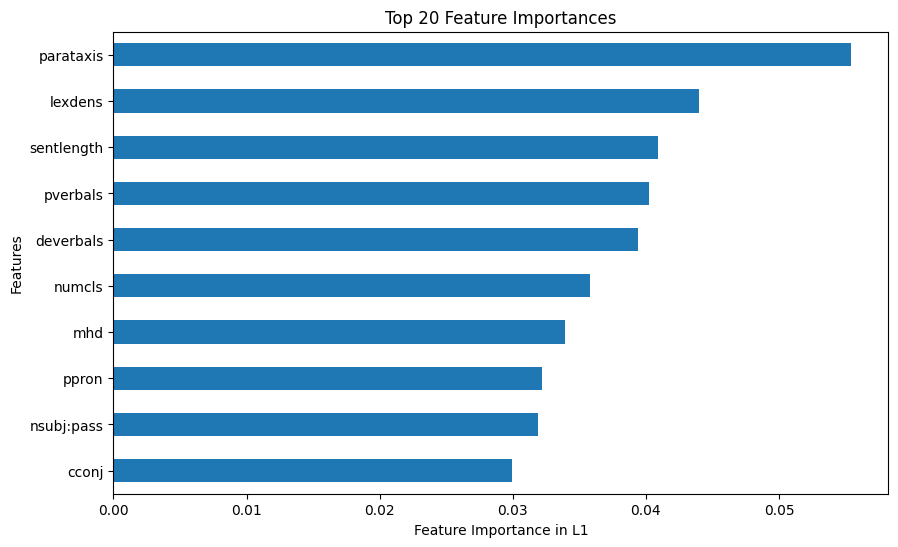

Clustering Accuracy: 0.24892868074686256


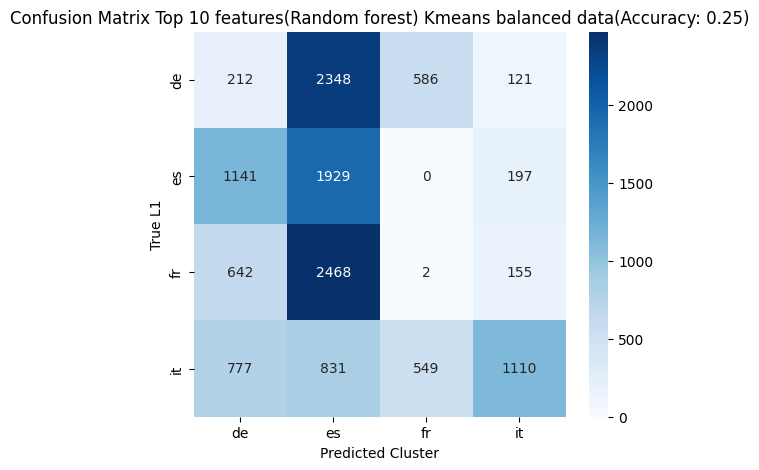

In [171]:
# Features and target
X = df_balanced[num_cols]
y = df_balanced['L1']

# Train-test split (stratified to keep balance)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

# RandomForest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

# Feature importances
importances = pd.Series(rf.feature_importances_, index=num_cols).sort_values(ascending=False)
top_features = importances.head(10)[::-1]  # reversed for horizontal bar plot

# Plot
ax = top_features.plot.barh(figsize=(10,6))
ax.set_xlabel("Feature Importance in L1")
ax.set_ylabel("Features")
ax.set_title("Top 20 Feature Importances")
plt.show()

selected_features = top_features.index.tolist()
X_kmeans = df_balanced[selected_features].values

# Standardize features before clustering
X_scaled = StandardScaler().fit_transform(X_kmeans)

# KMeans (for example, k=4 for 4 languages)
kmeans = KMeans(n_clusters=4, random_state=42)
df_balanced['cluster'] = kmeans.fit_predict(X_scaled)


# Map L1 to integers if not done already
l1_map = {"de":0, "es":1, "fr":2, "it":3}
df_balanced['L1_num'] = df_balanced['L1'].map(l1_map)

y_true = df_balanced['L1_num'].values
y_pred = df_balanced['cluster'].values

acc = accuracy_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)

print("Clustering Accuracy:", acc)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['de','es','fr','it'],
            yticklabels=['de','es','fr','it'])
plt.xlabel('Predicted Cluster')
plt.ylabel('True L1')
plt.title(f'Confusion Matrix Top 10 features(Random forest) Kmeans balanced data(Accuracy: {acc:.2f})')
plt.show()



##### Top 20 features

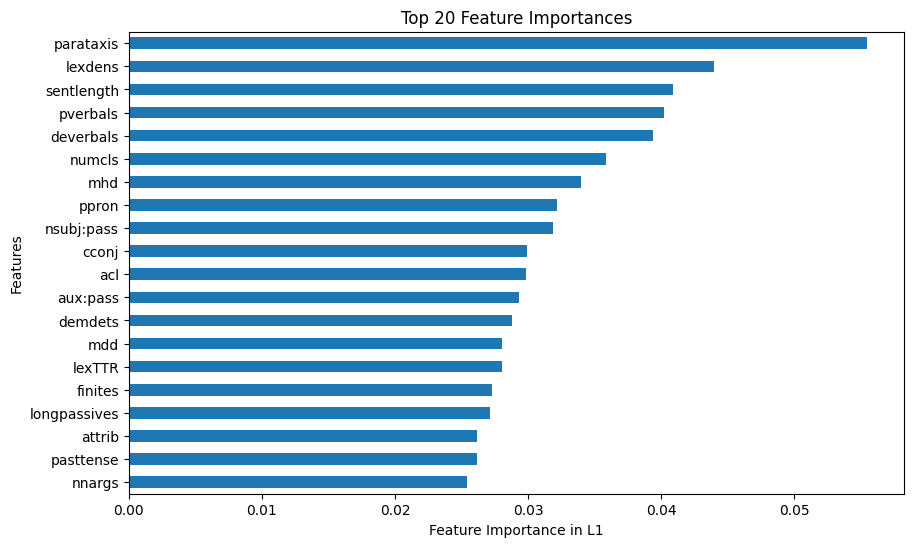

Clustering Accuracy: 0.13039485766758493


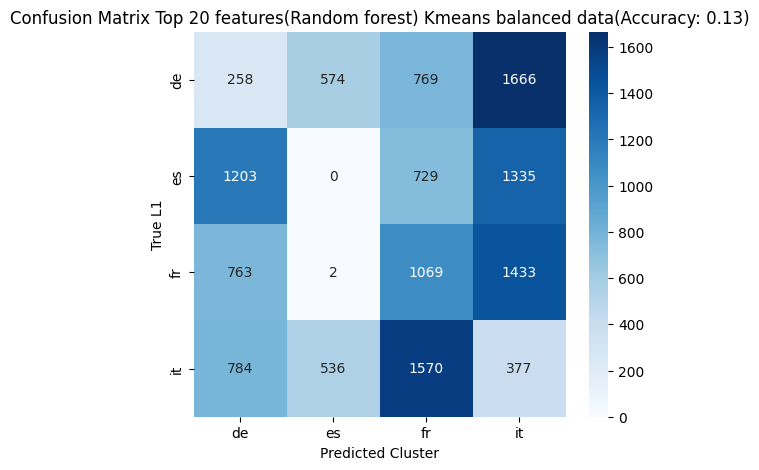

In [172]:
# Features and target
X = df_balanced[num_cols]
y = df_balanced['L1']

# Train-test split (stratified to keep balance)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

# RandomForest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

# Feature importances
importances = pd.Series(rf.feature_importances_, index=num_cols).sort_values(ascending=False)
top_features = importances.head(20)[::-1]  # reversed for horizontal bar plot

# Plot
ax = top_features.plot.barh(figsize=(10,6))
ax.set_xlabel("Feature Importance in L1")
ax.set_ylabel("Features")
ax.set_title("Top 20 Feature Importances")
plt.show()

selected_features = top_features.index.tolist()
X_kmeans = df_balanced[selected_features].values

# Standardize features before clustering
X_scaled = StandardScaler().fit_transform(X_kmeans)

# KMeans (for example, k=4 for 4 languages)
kmeans = KMeans(n_clusters=4, random_state=42)
df_balanced['cluster'] = kmeans.fit_predict(X_scaled)


# Map L1 to integers if not done already
l1_map = {"de":0, "es":1, "fr":2, "it":3}
df_balanced['L1_num'] = df_balanced['L1'].map(l1_map)

y_true = df_balanced['L1_num'].values
y_pred = df_balanced['cluster'].values

acc = accuracy_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)

print("Clustering Accuracy:", acc)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['de','es','fr','it'],
            yticklabels=['de','es','fr','it'])
plt.xlabel('Predicted Cluster')
plt.ylabel('True L1')
plt.title(f'Confusion Matrix Top 20 features(Random forest) Kmeans balanced data(Accuracy: {acc:.2f})')
plt.show()



PCA variance retained: 0.9509709212421624

Cluster → Majority Label Mapping:
{np.int32(0): 'es', np.int32(1): 'fr', np.int32(2): 'de', np.int32(3): 'it'}

Overall accuracy (same data used for clustering): 0.40633608815426997

Classification Report:
              precision    recall  f1-score   support

          de     0.5162    0.1760    0.2625      3267
          es     0.3896    0.4365    0.4117      3267
          fr     0.3210    0.6746    0.4350      3267
          it     0.7738    0.3382    0.4707      3267

    accuracy                         0.4063     13068
   macro avg     0.5001    0.4063    0.3950     13068
weighted avg     0.5001    0.4063    0.3950     13068



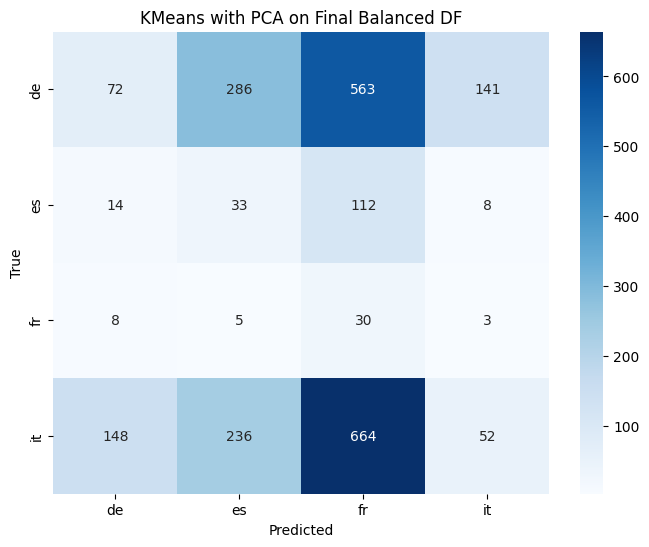


TP and FP per class:

    TP    FP
de  72   170
es  33   527
fr  30  1339
it  52   152


In [173]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# PCA
# -----------------------------
pca = PCA(n_components=0.95)  # retain 95% variance
X_p = pca.fit_transform(X_s)
print("PCA variance retained:", pca.explained_variance_ratio_.sum())

# -----------------------------
# KMeans on PCA-transformed data
# -----------------------------
k = len(np.unique(y))
kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
clusters = kmeans.fit_predict(X_p)

# -----------------------------
# Map clusters to majority class label
# -----------------------------
cluster_to_label = {}
for cl in np.unique(clusters):
    mask = (clusters == cl)
    true_labels = y[mask]
    uniq, counts = np.unique(true_labels, return_counts=True)
    cluster_to_label[cl] = uniq[np.argmax(counts)]

print("\nCluster → Majority Label Mapping:")
print(cluster_to_label)

# Map clusters to predicted labels
y_pred = np.array([cluster_to_label[c] for c in clusters])

# -----------------------------
# Evaluation
# -----------------------------
acc = np.mean(y_pred == y)
print("\nOverall accuracy (same data used for clustering):", acc)
print("\nClassification Report:")
print(classification_report(y, y_pred, digits=4))

# -----------------------------
# Confusion Matrix
# -----------------------------
labels_order = np.unique(y)
conf_mat = pd.crosstab(pd.Series(y, name='True'),
                       pd.Series(y_pred, name='Predicted'))
conf_mat = conf_mat.reindex(index=labels_order, columns=labels_order, fill_value=0)

plt.figure(figsize=(8,6))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
plt.title('KMeans with PCA on Final Balanced DF')
plt.show()

# -----------------------------
# TP / FP per class
# -----------------------------
tp_fp_df = pd.DataFrame(index=labels_order, columns=['TP','FP'])
for cls in labels_order:
    tp = conf_mat.loc[cls, cls]
    fp = conf_mat.loc[:, cls].sum() - tp
    tp_fp_df.loc[cls] = [int(tp), int(fp)]

print("\nTP and FP per class:\n")
print(tp_fp_df)


### PCA

/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [15] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Top 10 features used for clustering: ['dataset_name' 'sentlength' 'ppron' 'pasttense' 'lexdens' 'numcls'
 'nnargs' 'mhd' 'aux:pass' 'nsubj:pass']

========== KMeans ==========

Cluster → Majority Label Mapping:
  Cluster 0 → de
  Cluster 1 → es
  Cluster 2 → it
  Cluster 3 → fr

Classification Report:
              precision    recall  f1-score   support

          de     0.5158    0.1800    0.2668      3267
          es     0.3076    0.4506    0.3656      3267
          fr     0.3241    0.5672    0.4125      3267
          it     0.7749    0.3382    0.4709      3267

    accuracy                         0.3840     13068
   macro avg     0.4806    0.3840    0.3790     13068
weighted avg     0.4806    0.3840    0.3790     13068



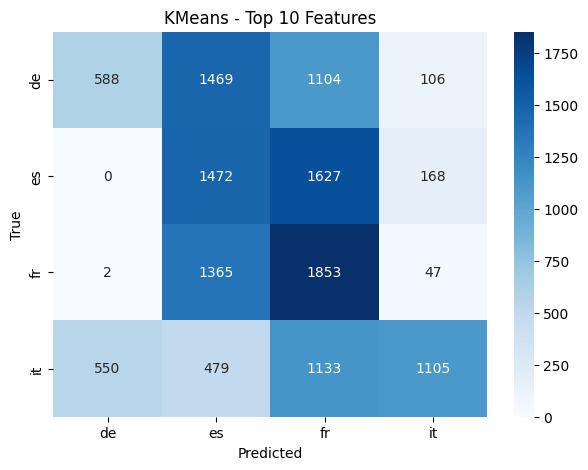


TP and FP per class:
       TP    FP
de   588   552
es  1472  3313
fr  1853  3864
it  1105   321

========== GMM ==========

Cluster → Majority Label Mapping:
  Cluster 0 → fr
  Cluster 1 → es
  Cluster 2 → de
  Cluster 3 → it

Classification Report:
              precision    recall  f1-score   support

          de     0.5158    0.1748    0.2611      3267
          es     0.3652    0.4530    0.4044      3267
          fr     0.3337    0.6636    0.4441      3267
          it     0.7790    0.3367    0.4702      3267

    accuracy                         0.4070     13068
   macro avg     0.4984    0.4070    0.3949     13068
weighted avg     0.4984    0.4070    0.3949     13068



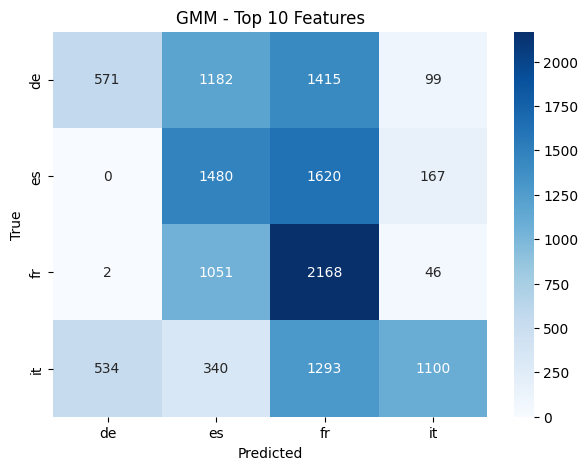


TP and FP per class:
       TP    FP
de   571   536
es  1480  2573
fr  2168  4328
it  1100   312


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(



========== Spectral Clustering ==========

Cluster → Majority Label Mapping:
  Cluster 0 → de
  Cluster 1 → es
  Cluster 2 → it
  Cluster 3 → it

Classification Report:
              precision    recall  f1-score   support

          de     0.5211    0.0530    0.0961      3267
          es     0.2622    1.0000    0.4155      3267
          fr     0.0000    0.0000    0.0000      3267
          it     0.5254    0.0444    0.0819      3267

    accuracy                         0.2743     13068
   macro avg     0.3272    0.2743    0.1484     13068
weighted avg     0.3272    0.2743    0.1484     13068



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


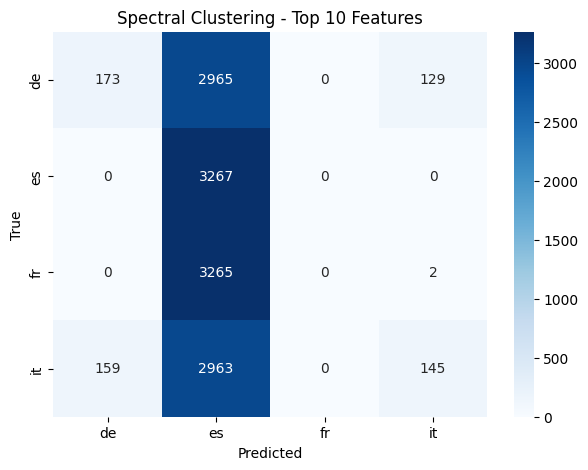


TP and FP per class:
       TP    FP
de   173   159
es  3267  9193
fr     0     0
it   145   131


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



========== HDBSCAN ==========

Cluster → Majority Label Mapping:
  Cluster -1 → it
  Cluster 0 → it
  Cluster 1 → it
  Cluster 2 → it
  Cluster 3 → it
  Cluster 4 → it
  Cluster 5 → de
  Cluster 6 → it
  Cluster 7 → de
  Cluster 8 → de
  Cluster 9 → de
  Cluster 10 → it
  Cluster 11 → de
  Cluster 12 → fr
  Cluster 13 → de

Classification Report:
              precision    recall  f1-score   support

          de     0.5707    0.1062    0.1791      3267
          es     0.0000    0.0000    0.0000      3267
          fr     0.3188    0.9770    0.4808      3267
          it     0.6664    0.4995    0.5710      3267

    accuracy                         0.3957     13068
   macro avg     0.3890    0.3957    0.3077     13068
weighted avg     0.3890    0.3957    0.3077     13068



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


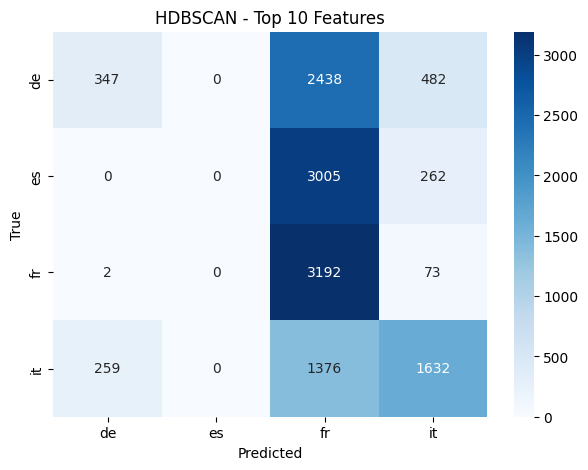


TP and FP per class:
       TP    FP
de   347   261
es     0     0
fr  3192  6819
it  1632   817


Predicted,de,es,fr,it
True,,,,
de,347,0,2438,482
es,0,0,3005,262
fr,2,0,3192,73
it,259,0,1376,1632


In [174]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.mixture import GaussianMixture
import hdbscan
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------
# 0) Utility: evaluate clustering
# ------------------------------
def evaluate_clustering(y_true, clusters, method_name):
    labels = np.unique(y_true)
    # Map cluster -> majority label
    cluster_to_label = {}
    for c in np.unique(clusters):
        idx = np.where(clusters == c)[0]
        assigned_true = y_true[idx]
        if len(assigned_true) == 0:
            cluster_to_label[c] = labels[0]
        else:
            uniq, counts = np.unique(assigned_true, return_counts=True)
            cluster_to_label[c] = uniq[np.argmax(counts)]
    # Map clusters -> predicted labels
    y_pred = np.array([cluster_to_label[c] for c in clusters])
    # Confusion matrix
    conf_mat = pd.crosstab(pd.Series(y_true, name="True"),
                           pd.Series(y_pred, name="Predicted"))
    conf_mat = conf_mat.reindex(index=labels, columns=labels, fill_value=0)
    # Print results
    print(f"\n========== {method_name} ==========")
    print("\nCluster → Majority Label Mapping:")
    for c, lab in cluster_to_label.items():
        print(f"  Cluster {c} → {lab}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, digits=4))
    # Plot confusion matrix
    plt.figure(figsize=(7,5))
    sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{method_name} - Top 10 Features")
    plt.show()
    # TP / FP per class
    tp_fp_df = pd.DataFrame(index=labels, columns=['TP','FP'])
    for cls in labels:
        tp = conf_mat.loc[cls, cls]
        fp = conf_mat.loc[:, cls].sum() - tp
        tp_fp_df.loc[cls] = [int(tp), int(fp)]
    print("\nTP and FP per class:\n", tp_fp_df)
    return conf_mat

# ------------------------------
# 2) Select Top 10 features (ANOVA F-test)
# ------------------------------
selector = SelectKBest(f_classif, k=10)
X_top10 = selector.fit_transform(X_s, y_balanced)
top_features = np.array(feature_cols)[selector.get_support()]
print("Top 10 features used for clustering:", top_features)

# ------------------------------
# 3) KMeans
# ------------------------------
k = len(np.unique(y_balanced))
kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
clusters_km = kmeans.fit_predict(X_top10)
evaluate_clustering(y_balanced, clusters_km, "KMeans")

# ------------------------------
# 4) Gaussian Mixture Model (GMM)
# ------------------------------
gmm = GaussianMixture(n_components=k, covariance_type="full", random_state=42)
clusters_gmm = gmm.fit_predict(X_top10)
evaluate_clustering(y_balanced, clusters_gmm, "GMM")

# ------------------------------
# 5) Spectral Clustering
# ------------------------------
spectral = SpectralClustering(n_clusters=k, affinity='nearest_neighbors', random_state=42)
clusters_spectral = spectral.fit_predict(X_top10)
evaluate_clustering(y_balanced, clusters_spectral, "Spectral Clustering")

# ------------------------------
# 6) HDBSCAN Clustering
# ------------------------------
clusterer = hdbscan.HDBSCAN(min_cluster_size=50, metric='euclidean', cluster_selection_method='eom')
clusters_hdb = clusterer.fit_predict(X_top10)
evaluate_clustering(y_balanced, clusters_hdb, "HDBSCAN")


#

# Trying other clustering methods

##NN

#### NN - K=4

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(



Neural Network Test Accuracy: 0.6055853098699311

Classification Report:
               precision    recall  f1-score   support

          de     0.5730    0.6177    0.5946       654
          es     0.5404    0.5528    0.5466       653
          fr     0.6708    0.6606    0.6656       654
          it     0.6466    0.5911    0.6176       653

    accuracy                         0.6056      2614
   macro avg     0.6077    0.6056    0.6061      2614
weighted avg     0.6077    0.6056    0.6061      2614



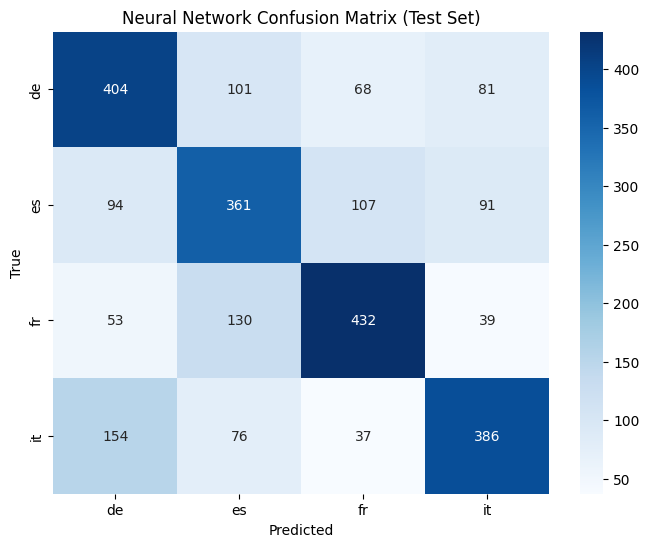

In [176]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp


# Train-test split (stratify ensures class balance in both sets)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features (fit on train only)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)


# Ensure X is dense float64
def to_dense_float(a):
    if sp.issparse(a):
        a = a.toarray()
    return np.asarray(a, dtype=np.float64)

X_train_s = to_dense_float(X_train_s)
X_test_s  = to_dense_float(X_test_s)

# Ensure y is a plain 1D array (not sparse, not weird dtype)
y_train = np.asarray(y_train)
y_test  = np.asarray(y_test)

# Neural network
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    early_stopping=False, validation_fraction=0.1,
    activation='relu',
    solver='adam',
    max_iter=200,  # can increase for convergence
    random_state=42
)
mlp.fit(X_train_s, y_train)

# Predict on test set
y_pred = mlp.predict(X_test_s)

# Evaluation
acc = np.mean(y_pred == y_test)
print("\nNeural Network Test Accuracy:", acc)
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))

# Confusion matrix
labels_order = np.unique(y_test)
conf_mat = confusion_matrix(y_test, y_pred, labels=labels_order)

plt.figure(figsize=(8,6))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_order, yticklabels=labels_order)
plt.title("Neural Network Confusion Matrix (Test Set)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


#### NN - K=2

In [181]:
df_balanced

,dataset_name,sentlength,ppron,possdet,indef,cconj,whconj,relativ,pied,correl,...,aux,aux:pass,ccomp,nsubj:pass,parataxis,xcomp,L1,anomaly,cluster,L1_num
9804,1,22.928571,0.000000,0.003115,0.0,0.857143,0.000000,0.071429,0.000000,0.0,...,0.071429,0.184524,0.000000,0.220238,0.000000,0.000000,de,1,3,0
21491,1,22.230538,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,...,0.098514,0.129547,0.027490,0.117948,0.018531,0.057606,de,1,1,0
12265,1,36.692308,0.004193,0.014675,0.0,2.384615,0.000000,0.153846,0.000000,0.0,...,0.000000,0.133333,0.156410,0.117949,0.038462,0.115385,de,1,0,0
5976,1,20.500000,0.003484,0.000000,0.0,1.142857,0.000000,0.071429,0.000000,0.0,...,0.085884,0.274660,0.000000,0.282313,0.000000,0.095238,de,1,3,0
16264,1,10.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,de,1,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142326,1,26.142857,0.005464,0.000000,0.0,0.571429,0.142857,0.285714,0.000000,0.0,...,0.071429,0.142857,0.000000,0.107143,0.142857,0.178571,it,1,3,3
140746,1,34.785714,0.014374,0.004107,0.0,0.428571,0.000000,0.500000,0.142857,0.0,...,0.300000,0.050000,0.067857,0.050000,0.053571,0.085714,it,1,2,3
141084,1,10.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,it,1,1,3
2301,0,25.083333,0.043189,0.013289,0.0,1.333333,0.083333,0.666667,0.083333,0.0,...,0.319444,0.125000,0.020833,0.055556,0.041667,0.159722,it,-1,2,3


#balanced data NN2

In [190]:
import pandas as pd

df_L2 = df[df['dataset_name'] == 0]
df_other = df[df['dataset_name'] != 0]

df_other_downsampled = df_other.sample(n=len(df_L2), random_state=42)

df_balanced = pd.concat([df_L2, df_other_downsampled], ignore_index=True)

df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(df_balanced['dataset_name'].value_counts())

# define mapping
l1_map = {
    "de": 0,
    "es": 1,
    "fr": 2,
    "it": 3
}

# apply mapping
df_balanced["L1_num"] = df_balanced["L1"].map(l1_map)



dataset_name
0    4400
1    4400
Name: count, dtype: int64


In [191]:
df_balanced

,dataset_name,sentlength,ppron,possdet,indef,cconj,whconj,relativ,pied,correl,...,acl,aux,aux:pass,ccomp,nsubj:pass,parataxis,xcomp,L1,anomaly,L1_num
0,0,23.615385,0.019544,0.009772,0.003257,0.615385,0.076923,0.307692,0.000000,0.0,...,0.217949,0.230769,0.076923,0.089744,0.051282,0.000000,0.179487,es,1,1
1,0,20.222222,0.065934,0.013736,0.000000,0.666667,0.000000,0.277778,0.000000,0.0,...,0.013889,0.370370,0.009259,0.120370,0.009259,0.055556,0.254630,it,1,3
2,1,22.142857,0.032258,0.012903,0.000000,0.285714,0.142857,0.000000,0.000000,0.0,...,0.285714,0.047619,0.047619,0.000000,0.047619,0.238095,0.047619,fr,1,2
3,1,9.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,de,1,0
4,0,16.727273,0.059783,0.013587,0.005435,0.454545,0.136364,0.272727,0.000000,0.0,...,0.136364,0.413636,0.000000,0.054545,0.000000,0.037879,0.266667,fr,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8795,1,30.500000,0.016393,0.010929,0.000000,1.500000,0.000000,0.000000,0.000000,0.0,...,0.000000,0.055556,0.277778,0.166667,0.277778,0.000000,0.055556,es,1,1
8796,1,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,de,1,0
8797,1,28.700000,0.020906,0.006969,0.000000,0.400000,0.000000,0.000000,0.000000,0.0,...,0.316667,0.115000,0.075000,0.100000,0.058333,0.025000,0.110000,fr,1,2
8798,0,17.900000,0.030726,0.005587,0.002793,0.450000,0.000000,0.200000,0.000000,0.0,...,0.145833,0.261667,0.065833,0.041667,0.055833,0.008333,0.220833,es,1,1



Neural Network Test Accuracy: 0.9903409090909091

Classification Report:
               precision    recall  f1-score   support

           0     0.9898    0.9909    0.9903       880
           1     0.9909    0.9898    0.9903       880

    accuracy                         0.9903      1760
   macro avg     0.9903    0.9903    0.9903      1760
weighted avg     0.9903    0.9903    0.9903      1760



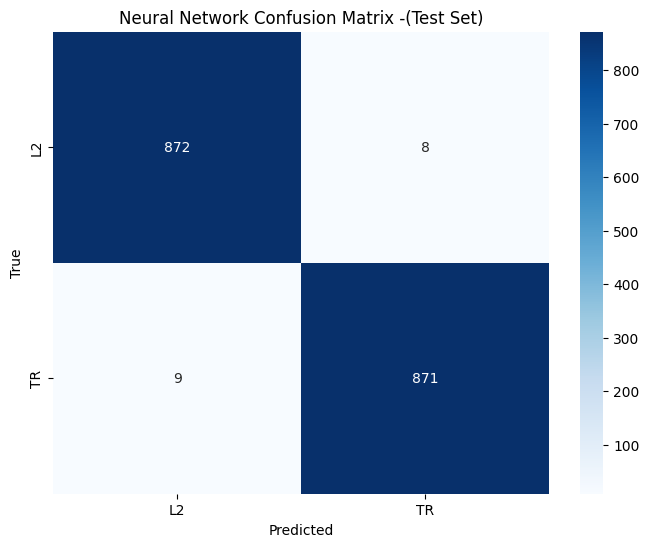

In [192]:
# Features and target
to_drop = [c for c in ['dataset_name','cluster','kmeans_labels','L1'] if c in df.columns]
feature_cols = [c for c in df.columns if c not in to_drop]

# Features and target
X = df_balanced[feature_cols]
y = df_balanced['dataset_name']

# Train-test split (stratified to keep balance)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

# Train-test split (stratify ensures class balance in both sets)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features (fit on train only)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Neural network
mlp = MLPClassifier(
    hidden_layer_sizes=(16, 8),
    early_stopping=True, validation_fraction=0.1,
    activation='relu',
    solver='adam',
    max_iter=200,  # can increase for convergence
    random_state=42
)
mlp.fit(X_train_s, y_train)

# Predict on test set
y_pred = mlp.predict(X_test_s)

# Evaluation
acc = np.mean(y_pred == y_test)
print("\nNeural Network Test Accuracy:", acc)
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))

# Confusion matrix
labels_order = np.unique(y_test)
conf_mat = confusion_matrix(y_test, y_pred, labels=labels_order)

plt.figure(figsize=(8,6))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=["L2", "TR"],
            yticklabels=["L2", "TR"])
plt.title("Neural Network Confusion Matrix -(Test Set)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
